# Heart Disease Risk Screening

## Objective

This study develops an **interpretable risk screening model** for heart disease.
The goal is to support general practitioners with a simple, score-based tool that
flags patients for referral to a cardiologist. The model does not replace clinical
judgement — it provides a first-pass indicator based on readily available clinical
variables.

## Approach

- **Logistic regression** as the primary model (interpretable, coefficient-based)
- **Gradient boosting** as a benchmark (non-linear, SHAP-based interpretation)
- Focus on **interpretability with solid performance** — not maximum accuracy

## Hypothesis

> *Can a classification model based on 5 variables reach a sensitivity (recall)
> of at least 99% (false-negative rate < 1%) with simultaneous precision of
> over 80%?*

## Data

The UCI Heart Disease dataset combines patient records from four hospitals:
Cleveland (n=303), Hungarian (n=294), Long Beach VA (n=200), and Switzerland
(n=123) — 920 patients total with 14 clinical variables.

## Note on Geographic Source (`source_code`)

We initially assumed that geographic location (`source_code`) might serve as a meaningful predictor — for example, reflecting regional differences in diet or lifestyle. However, when included in the models, `source_code` ranked among the top 2 most important features for both logistic regression and gradient boosting. This turned out to reflect **selection bias in data collection**, not clinical signal:

- **Switzerland** (93.5% disease prevalence): a specialty cardiology cohort where nearly every patient was already suspected of having heart disease.
- **Long Beach VA** (74.5%): veterans with known cardiovascular risk factors.
- **Cleveland** (45.9%): mixed referral population.
- **Hungarian** (36.1%): closest to a general screening population.

The model was effectively learning "Swiss patients almost always have disease" — a property of how the data was collected, not of geography. A new patient in a real-world screening setting has no meaningful `source_code`. Including it would inflate performance artificially and make the model non-transferable. It was therefore **excluded from all models**.

Investigating whether geographic location genuinely influences heart disease rates would require representative population samples and information about ethnicity, diet, and lifestyle — none of which are available in this dataset.

## Report Structure

1. **Exploratory Data Analysis** — variable distributions, missing data, correlations
2. **Preprocessing** — encoding, imputation, target binarization
3. **Logistic Regression** — L1-regularized model, threshold optimisation, top 5 variables
4. **Gradient Boosting** — benchmark model, SHAP analysis, top 5 variables
5. **Model Comparison & Hypothesis Test** — side-by-side evaluation, 5-variable reduced model,
   hypothesis evaluation, limitations, and conclusion

# 1 — Exploratory Data Analysis

This chapter explores the UCI Heart Disease dataset, which combines patient records from four hospitals: Cleveland, Hungarian, Long Beach VA, and Switzerland (920 patients total, 14 clinical variables).

The analysis examines variable distributions, missing data patterns, and correlations to inform the modelling strategy in subsequent chapters.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import numpy as np
import sys, os
import pandas as pd
import seaborn as sns
from dython.nominal import associations

# ── Presentation-matched style ──────────────────────────────────────
CLR_BLUE  = "#5A6E97"   # slate blue
CLR_RED   = "#CA6B6E"   # muted rose
CLR_BEIGE = "#E6D5C3"   # warm beige
CLR_GRAY  = "#EBEDEF"   # light gray

SOURCES = ["cleveland", "hungarian", "long_beach_va", "switzerland"]
SOURCE_COLORS = {
    "cleveland":     "#5A6E97",
    "hungarian":     "#CA6B6E",
    "long_beach_va": "#E6D5C3",
    "switzerland":   "#9B8EA7",
}

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": CLR_GRAY,
    "axes.edgecolor": CLR_BLUE,
    "axes.labelcolor": CLR_BLUE,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.color": "white",
    "grid.linewidth": 0.8,
    "text.color": CLR_BLUE,
    "xtick.color": CLR_BLUE,
    "ytick.color": CLR_BLUE,
    "legend.framealpha": 0.9,
    "legend.edgecolor": CLR_BEIGE,
    "font.family": "sans-serif",
    "font.sans-serif": ["Calibri", "Arial", "DejaVu Sans"],
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

In [2]:

sys.path.append(os.path.abspath("."))

from src.data_loader import load_heart_disease

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

df = load_heart_disease()

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nRows per source:")
print(df["source"].value_counts().to_string())

Shape: 920 rows × 15 columns

Rows per source:
source
cleveland        303
hungarian        294
long_beach_va    200
switzerland      123


In [3]:
# Encode source as ordered categorical (1=cleveland, 2=hungarian, 3=long_beach_va, 4=switzerland)
source_order = ["cleveland", "hungarian", "long_beach_va", "switzerland"]
df["source"] = pd.Categorical(df["source"], categories=source_order, ordered=False)
df["source_code"] = df["source"].cat.codes + 1  # codes are 0-based, shift to 1-based

print(df[["source", "source_code"]].drop_duplicates().sort_values("source_code").to_string(index=False))

       source  source_code
    cleveland            1
    hungarian            2
long_beach_va            3
  switzerland            4


## Variable Descriptions

The dataset contains the 14 standard UCI Heart Disease features plus a `source` column indicating the originating cohort. Categorical variables are already numerically encoded.

| Variable      | Description                                              | Type                               | Units / Value Meaning                                                             |
| ------------- | -------------------------------------------------------- | ---------------------------------- | --------------------------------------------------------------------------------- |
| `age`         | Age of patient                                           | Numeric – Continuous               | Years                                                                             |
| `trestbps`    | Resting blood pressure (on admission)                    | Numeric – Continuous               | mm Hg                                                                             |
| `chol`        | Serum cholesterol                                        | Numeric – Continuous               | mg/dl                                                                             |
| `thalach`     | Maximum heart rate achieved during stress test           | Numeric – Continuous               | Beats per minute (bpm)                                                            |
| `oldpeak`     | ST depression induced by exercise relative to rest       | Numeric – Continuous               | mm                                                                                |
| `ca`          | Number of major vessels colored by fluoroscopy           | Numeric – Discrete                 | Count: 0–3 vessels                                                               |
| `sex`         | Biological sex                                           | Categorical – Binary (Nominal)     | 1 = male; 0 = female                                                             |
| `fbs`         | Fasting blood sugar > 120 mg/dl                          | Categorical – Binary (Nominal)     | 1 = true; 0 = false                                                              |
| `exang`       | Exercise-induced angina                                  | Categorical – Binary (Nominal)     | 1 = yes; 0 = no                                                                  |
| `cp`          | Chest pain type                                          | Categorical – Multiclass (Nominal) | 1 = typical angina; 2 = atypical angina; 3 = non-anginal pain; 4 = asymptomatic  |
| `restecg`     | Resting ECG results                                      | Categorical – Multiclass (Nominal) | 0 = normal; 1 = ST-T wave abnormality; 2 = left ventricular hypertrophy          |
| `thal`        | Thalassemia test result                                  | Categorical – Multiclass (Nominal) | 3 = normal; 6 = fixed defect; 7 = reversible defect                              |
| `slope`       | Slope of peak exercise ST segment                        | Categorical – Ordinal              | 1 = upsloping; 2 = flat; 3 = downsloping                                         |
| `num`         | Diagnosis — heart disease severity **(target)**          | Numeric – Ordinal                  | 0 = no disease; 1–4 = increasing severity (often binarised: 0 vs. 1–4)           |
| `source`      | Originating cohort (string label)                        | Categorical (Nominal)              | cleveland, hungarian, long\_beach\_va, switzerland                                |
| `source_code` | Originating cohort (numeric code)                        | Categorical (Nominal)              | 1 = cleveland; 2 = hungarian; 3 = long\_beach\_va; 4 = switzerland               |

In [4]:
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,source,source_code
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland,1
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,cleveland,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland,1
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland,1
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0,cleveland,1
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3,cleveland,1
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0,cleveland,1
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2,cleveland,1
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1,cleveland,1


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,source_code
count,920.000000,920.000000,920.000000,861.000000,890.000000,830.000000,918.000000,865.000000,865.000000,858.000000,611.000000,309.000000,434.000000,920.000000,920.000000
mean,53.510870,0.789130,3.250000,132.132404,199.130337,0.166265,0.604575,137.545665,0.389595,0.878788,1.770867,0.676375,5.087558,0.995652,2.155435
std,9.424685,0.408148,0.930969,19.066070,110.780810,0.372543,0.805827,25.926276,0.487941,1.091226,0.619256,0.935653,1.919075,1.142693,1.028840
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,1.000000,0.000000,3.000000,0.000000,1.000000
25%,47.000000,1.000000,3.000000,120.000000,175.000000,0.000000,0.000000,120.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,1.000000
50%,54.000000,1.000000,4.000000,130.000000,223.000000,0.000000,0.000000,140.000000,0.000000,0.500000,2.000000,0.000000,6.000000,1.000000,2.000000
75%,60.000000,1.000000,4.000000,140.000000,268.000000,0.000000,1.000000,157.000000,1.000000,1.500000,2.000000,1.000000,7.000000,2.000000,3.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000,4.000000


## Disease Prevalence by Source

The four hospital datasets differ substantially in disease prevalence, sex ratio, and age distribution. These differences reflect selection bias (referral vs. screening populations) rather than genuine geographical variation in heart disease risk.

DISEASE PREVALENCE BY SOURCE

Cleveland (n=303):
  No Disease: 164 (54.1%)
  Disease:    139 (45.9%)
  Male:       206 (68.0%)
  Female:     97 (32.0%)
  Mean age:   54.4 years

Hungarian (n=294):
  No Disease: 188 (63.9%)
  Disease:    106 (36.1%)
  Male:       213 (72.4%)
  Female:     81 (27.6%)
  Mean age:   47.8 years

Long Beach VA (n=200):
  No Disease: 51 (25.5%)
  Disease:    149 (74.5%)
  Male:       194 (97.0%)
  Female:     6 (3.0%)
  Mean age:   59.4 years

Switzerland (n=123):
  No Disease: 8 (6.5%)
  Disease:    115 (93.5%)
  Male:       113 (91.9%)
  Female:     10 (8.1%)
  Mean age:   55.3 years


C:\Users\joshu\AppData\Local\Temp\ipykernel_16188\652889150.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2].boxplot(data_age, labels=[source_map[s] for s in SOURCES],


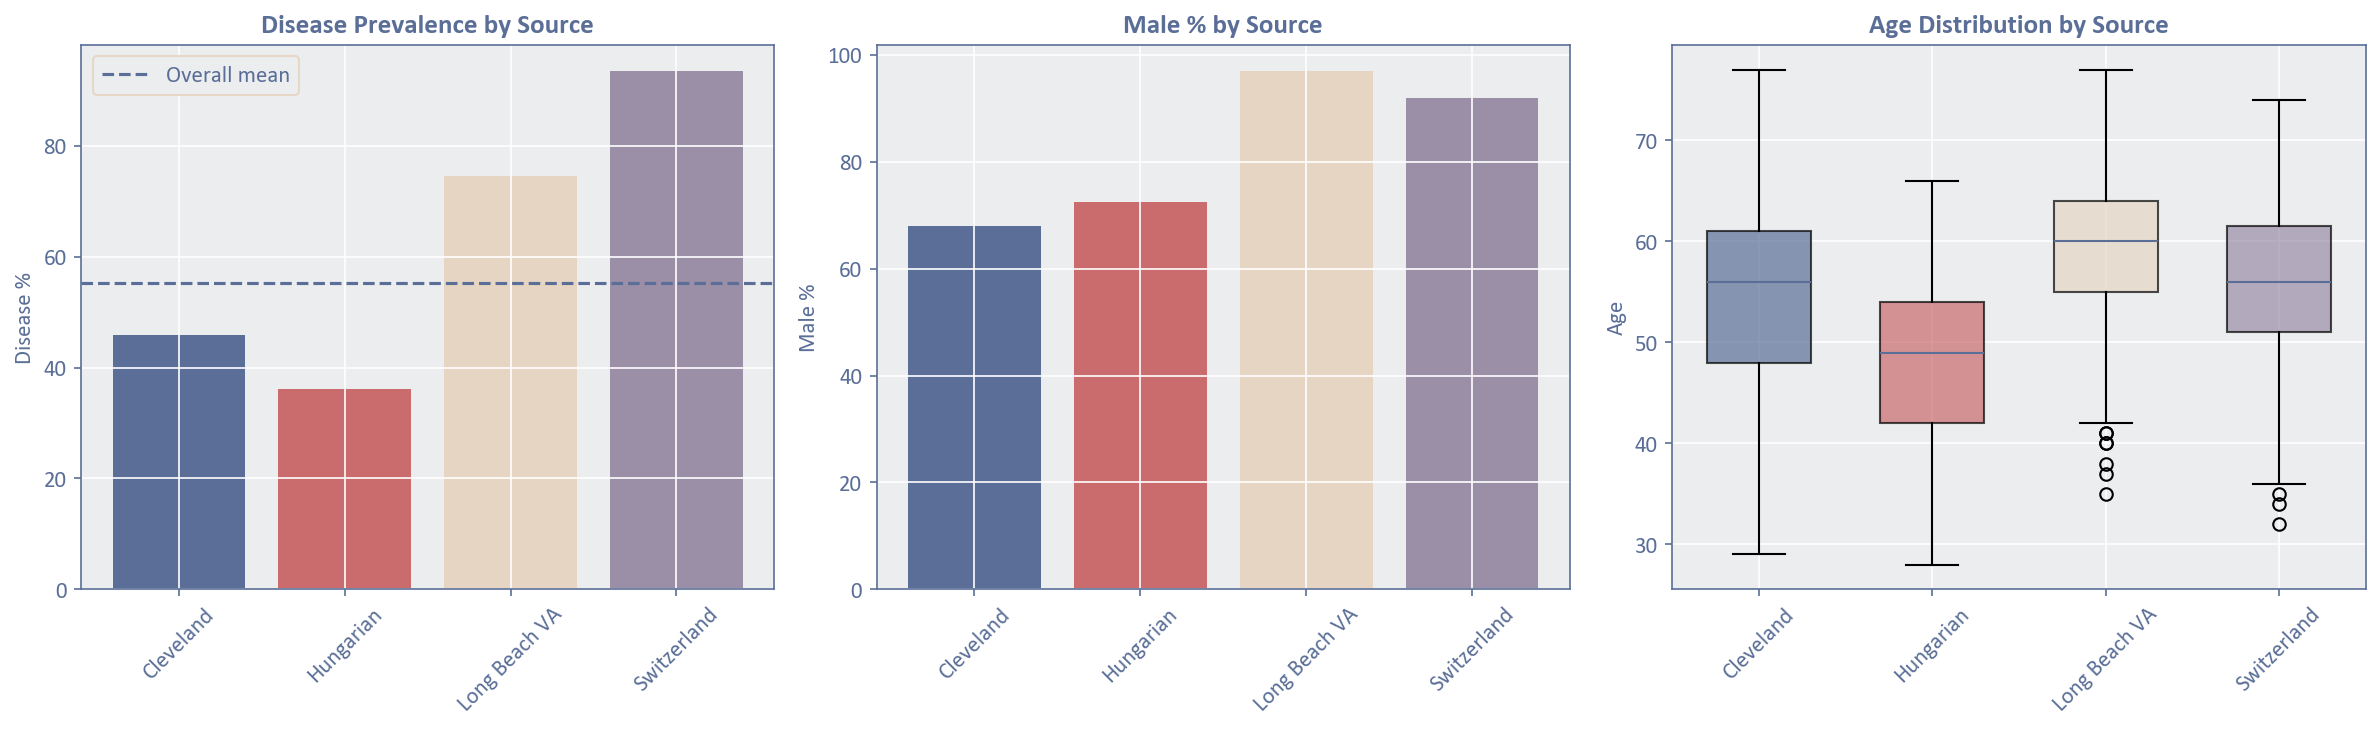


Note: Switzerland shows 93.5% disease prevalence, suggesting a specialty cardiology cohort.
These differences are driven by selection bias, not geography (see Chapter 5).


In [6]:
# Disease prevalence, sex distribution, and age by source
source_map = {"cleveland": "Cleveland", "hungarian": "Hungarian",
              "long_beach_va": "Long Beach VA", "switzerland": "Switzerland"}

print("=" * 70)
print("DISEASE PREVALENCE BY SOURCE")
print("=" * 70)
for s in SOURCES:
    subset = df[df["source"] == s]
    n = len(subset)
    n_disease = (subset["num"] > 0).sum()
    n_healthy = n - n_disease
    n_male = (subset["sex"] == 1).sum()
    n_female = (subset["sex"] == 0).sum()
    print(f"\n{source_map[s]} (n={n}):")
    print(f"  No Disease: {n_healthy} ({n_healthy/n*100:.1f}%)")
    print(f"  Disease:    {n_disease} ({n_disease/n*100:.1f}%)")
    print(f"  Male:       {n_male} ({n_male/n*100:.1f}%)")
    print(f"  Female:     {n_female} ({n_female/n*100:.1f}%)")
    print(f"  Mean age:   {subset['age'].mean():.1f} years")

# Summary visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Disease prevalence by source
for i, s in enumerate(SOURCES):
    subset = df[df["source"] == s]
    prev = (subset["num"] > 0).mean() * 100
    axes[0].bar(source_map[s], prev, color=SOURCE_COLORS[s])
axes[0].axhline(y=(df["num"] > 0).mean() * 100, color=CLR_BLUE, linestyle="--", label="Overall mean")
axes[0].set_title("Disease Prevalence by Source")
axes[0].set_ylabel("Disease %")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

# Sex distribution by source
for i, s in enumerate(SOURCES):
    subset = df[df["source"] == s]
    male_pct = (subset["sex"] == 1).mean() * 100
    axes[1].bar(source_map[s], male_pct, color=SOURCE_COLORS[s])
axes[1].set_title("Male % by Source")
axes[1].set_ylabel("Male %")
axes[1].tick_params(axis="x", rotation=45)

# Age distribution by source
data_age = [df.loc[df["source"] == s, "age"].dropna().values for s in SOURCES]
bp = axes[2].boxplot(data_age, labels=[source_map[s] for s in SOURCES],
                     patch_artist=True, widths=0.6)
for patch, s in zip(bp["boxes"], SOURCES):
    patch.set_facecolor(SOURCE_COLORS[s])
    patch.set_alpha(0.7)
for median in bp["medians"]:
    median.set_color(CLR_BLUE)
axes[2].set_title("Age Distribution by Source")
axes[2].set_ylabel("Age")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("results/figures/eda_disease_prevalence_by_source.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nNote: Switzerland shows 93.5% disease prevalence, suggesting a specialty cardiology cohort.")
print("These differences are driven by selection bias, not geography (see Chapter 5).")

## 1.1 — Missing Values Matrix

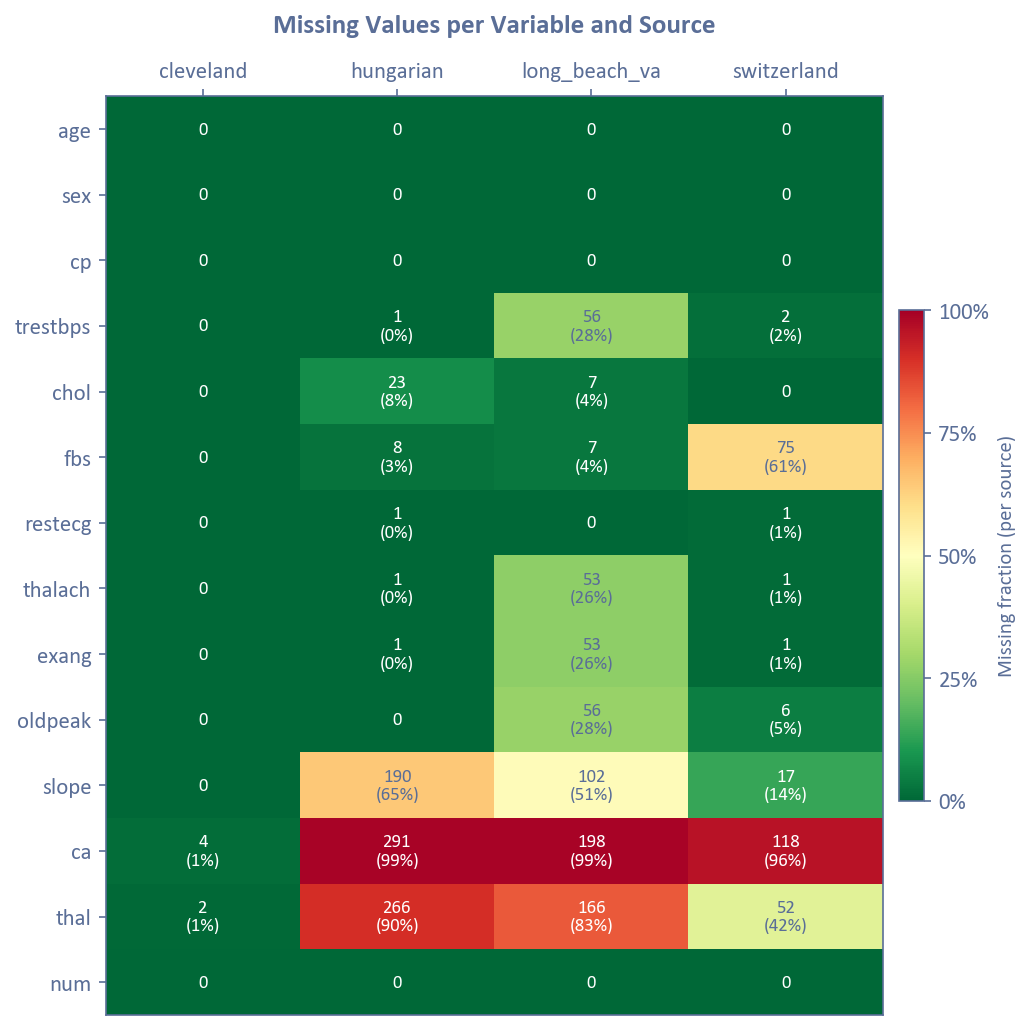

In [7]:

FEATURE_COLS = ["age", "sex", "cp", "trestbps", "chol", "fbs",
                "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"]
SOURCE_TOTALS = {"cleveland": 303, "hungarian": 294, "long_beach_va": 200, "switzerland": 123}

# Build missing-count matrix (rows=variables, cols=sources)
missing_counts = pd.DataFrame(
    {s: [df.loc[df["source"] == s, col].isna().sum() for col in FEATURE_COLS]
     for s in SOURCES},
    index=FEATURE_COLS,
)

# Build missing-fraction matrix for coloring
missing_pct = missing_counts.copy().astype(float)
for s in SOURCES:
    missing_pct[s] = missing_counts[s] / SOURCE_TOTALS[s]

fig, ax = plt.subplots(figsize=(7, 7))

# Green (0%) → Red (100%) colormap
cmap = plt.cm.RdYlGn_r

im = ax.imshow(missing_pct.values, cmap=cmap, vmin=0, vmax=1, aspect="auto")

# Axes labels
ax.set_xticks(range(len(SOURCES)))
ax.set_xticklabels(SOURCES, fontsize=11)
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_yticklabels(FEATURE_COLS, fontsize=11)
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

# Annotate each cell with count and percentage
for row_i, col in enumerate(FEATURE_COLS):
    for col_j, s in enumerate(SOURCES):
        count = missing_counts.loc[col, s]
        pct   = missing_pct.loc[col, s]
        label = f"{count}\n({pct:.0%})" if count > 0 else "0"
        text_color = CLR_BLUE if 0.25 <= pct <= 0.80 else "white"
        ax.text(col_j, row_i, label,
                ha="center", va="center", fontsize=9, color=text_color)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Missing fraction (per source)", fontsize=10)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(["0%", "25%", "50%", "75%", "100%"])

ax.set_title("Missing Values per Variable and Source", fontsize=13, pad=14)
ax.grid(False)
plt.tight_layout()
plt.savefig("results/figures/eda_missing_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 1.2 — Continuous Numeric Variables

- age
- trestbps
- chol
- thalach
- oldpeak

In [8]:

os.makedirs("../results", exist_ok=True)

def plot_missing_per_source(ax, col):
    """Bar chart of missing value counts per source for a given column."""
    missing = [df.loc[df["source"] == s, col].isna().sum() for s in SOURCES]
    bars = ax.bar(SOURCES, missing, color=[SOURCE_COLORS[s] for s in SOURCES])
    ax.set_title(f"{col} — Missing Values per Source")
    ax.set_xlabel("Source")
    ax.set_ylabel("Missing Count")
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    for bar, val in zip(bars, missing):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.05,
                str(val), ha="center", va="bottom", fontsize=9)
    ax.tick_params(axis="x", rotation=15)

C:\Users\joshu\AppData\Local\Temp\ipykernel_16188\2828833136.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_by_source, labels=all_sources, patch_artist=True, notch=False)


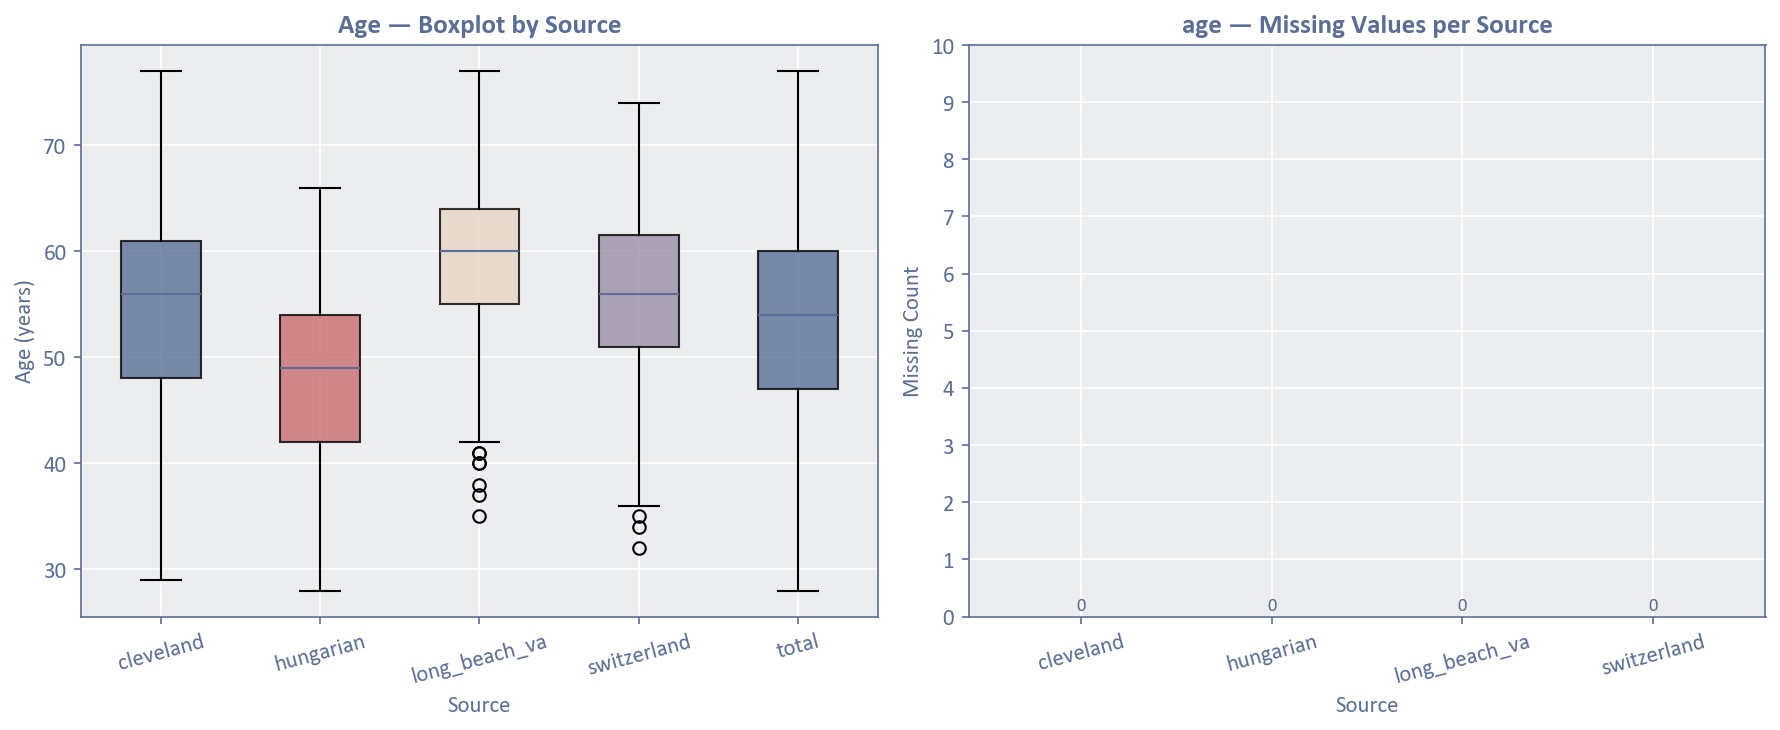

In [9]:
# --- age: boxplot per source + total ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

all_sources = SOURCES + ["total"]
data_by_source = [df.loc[df["source"] == s, "age"].dropna().values for s in SOURCES]
data_by_source.append(df["age"].dropna().values)

bp = axes[0].boxplot(data_by_source, labels=all_sources, patch_artist=True, notch=False)
colors = [SOURCE_COLORS[s] for s in SOURCES] + [CLR_BLUE]
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.8)
for median in bp["medians"]:
    median.set_color(CLR_BLUE)
axes[0].set_title("Age — Boxplot by Source")
axes[0].set_xlabel("Source")
axes[0].set_ylabel("Age (years)")
axes[0].tick_params(axis="x", rotation=15)

plot_missing_per_source(axes[1], "age")
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.savefig("results/figures/eda_numeric_boxplot_age.png", dpi=150, bbox_inches="tight")
plt.show()

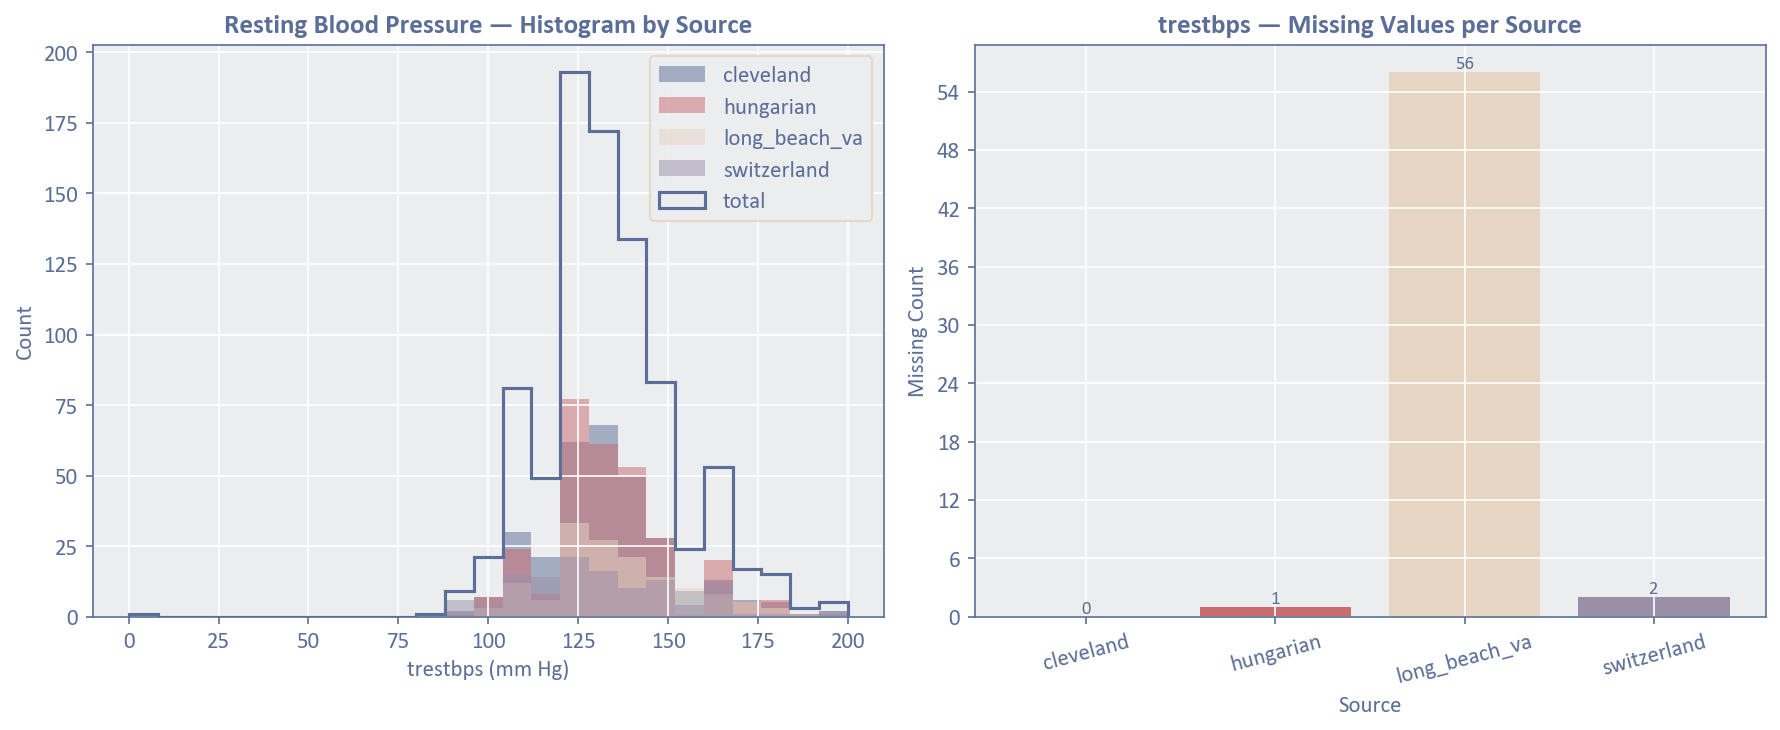

In [10]:
# --- trestbps: histogram per source + total line ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bins = np.linspace(df["trestbps"].dropna().min(), df["trestbps"].dropna().max(), 26)
for s in SOURCES:
    vals = df.loc[df["source"] == s, "trestbps"].dropna()
    axes[0].hist(vals, bins=bins, alpha=0.5, label=s, color=SOURCE_COLORS[s])
axes[0].hist(df["trestbps"].dropna(), bins=bins, histtype="step",
             color=CLR_BLUE, linewidth=1.5, label="total")
axes[0].set_title("Resting Blood Pressure — Histogram by Source")
axes[0].set_xlabel("trestbps (mm Hg)")
axes[0].set_ylabel("Count")
axes[0].legend()

plot_missing_per_source(axes[1], "trestbps")

plt.tight_layout()
plt.savefig("results/figures/eda_numeric_histogram_trestbps.png", dpi=150, bbox_inches="tight")
plt.show()

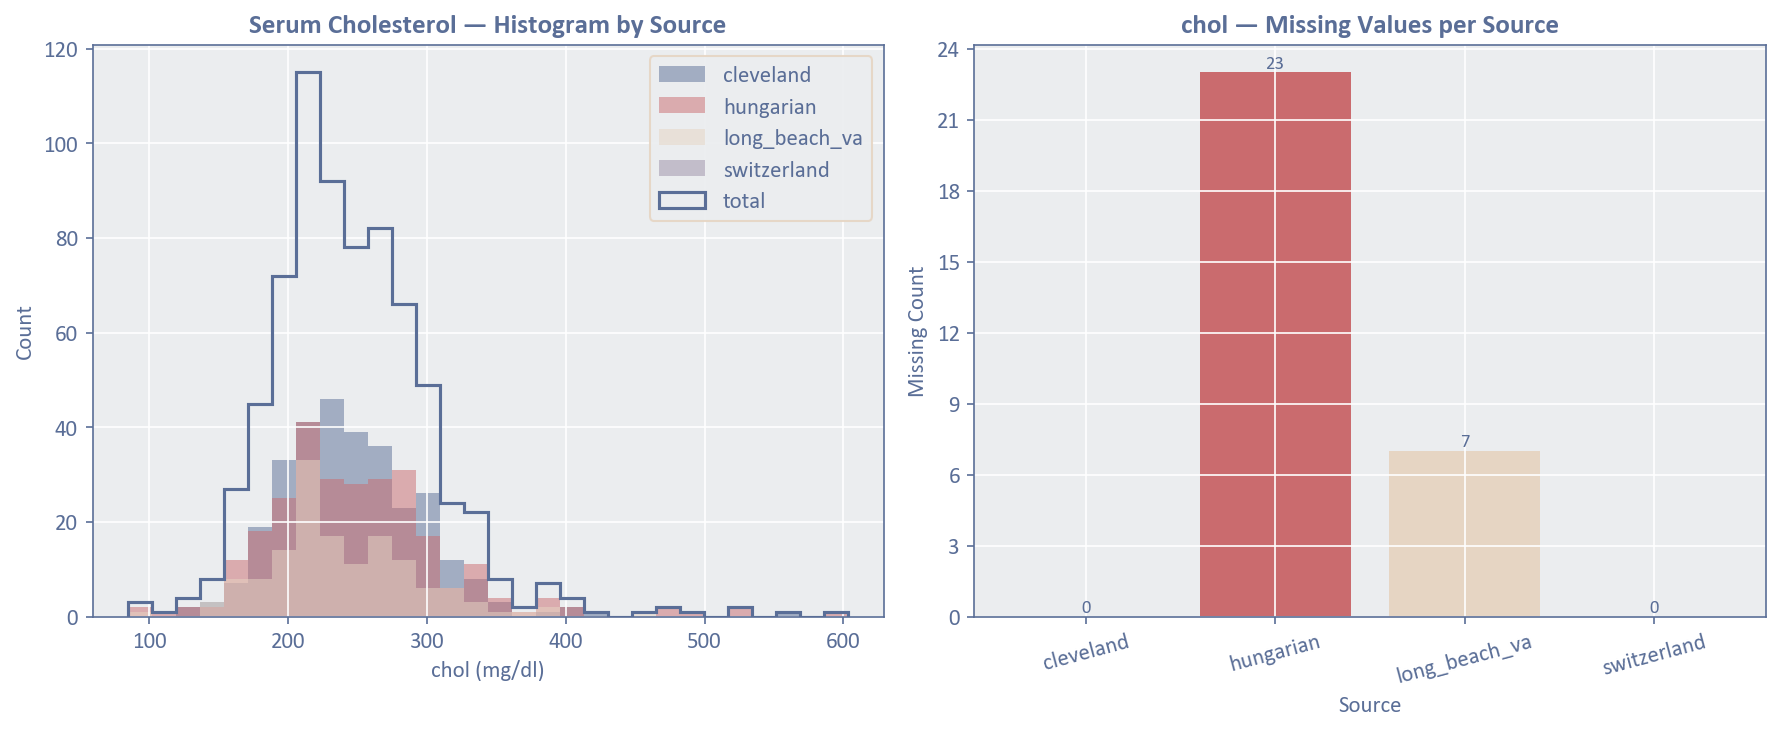

In [11]:
# --- chol: histogram per source + total line ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

chol_valid = df.loc[df["chol"] > 0, "chol"].dropna()
bins = np.linspace(chol_valid.min(), chol_valid.max(), 31)
for s in SOURCES:
    vals = df.loc[(df["source"] == s) & (df["chol"] > 0), "chol"].dropna()
    axes[0].hist(vals, bins=bins, alpha=0.5, label=s, color=SOURCE_COLORS[s])
axes[0].hist(chol_valid, bins=bins, histtype="step",
             color=CLR_BLUE, linewidth=1.5, label="total")
axes[0].set_title("Serum Cholesterol — Histogram by Source")
axes[0].set_xlabel("chol (mg/dl)")
axes[0].set_ylabel("Count")
axes[0].legend()

plot_missing_per_source(axes[1], "chol")

plt.tight_layout()
plt.savefig("results/figures/eda_numeric_histogram_chol.png", dpi=150, bbox_inches="tight")
plt.show()

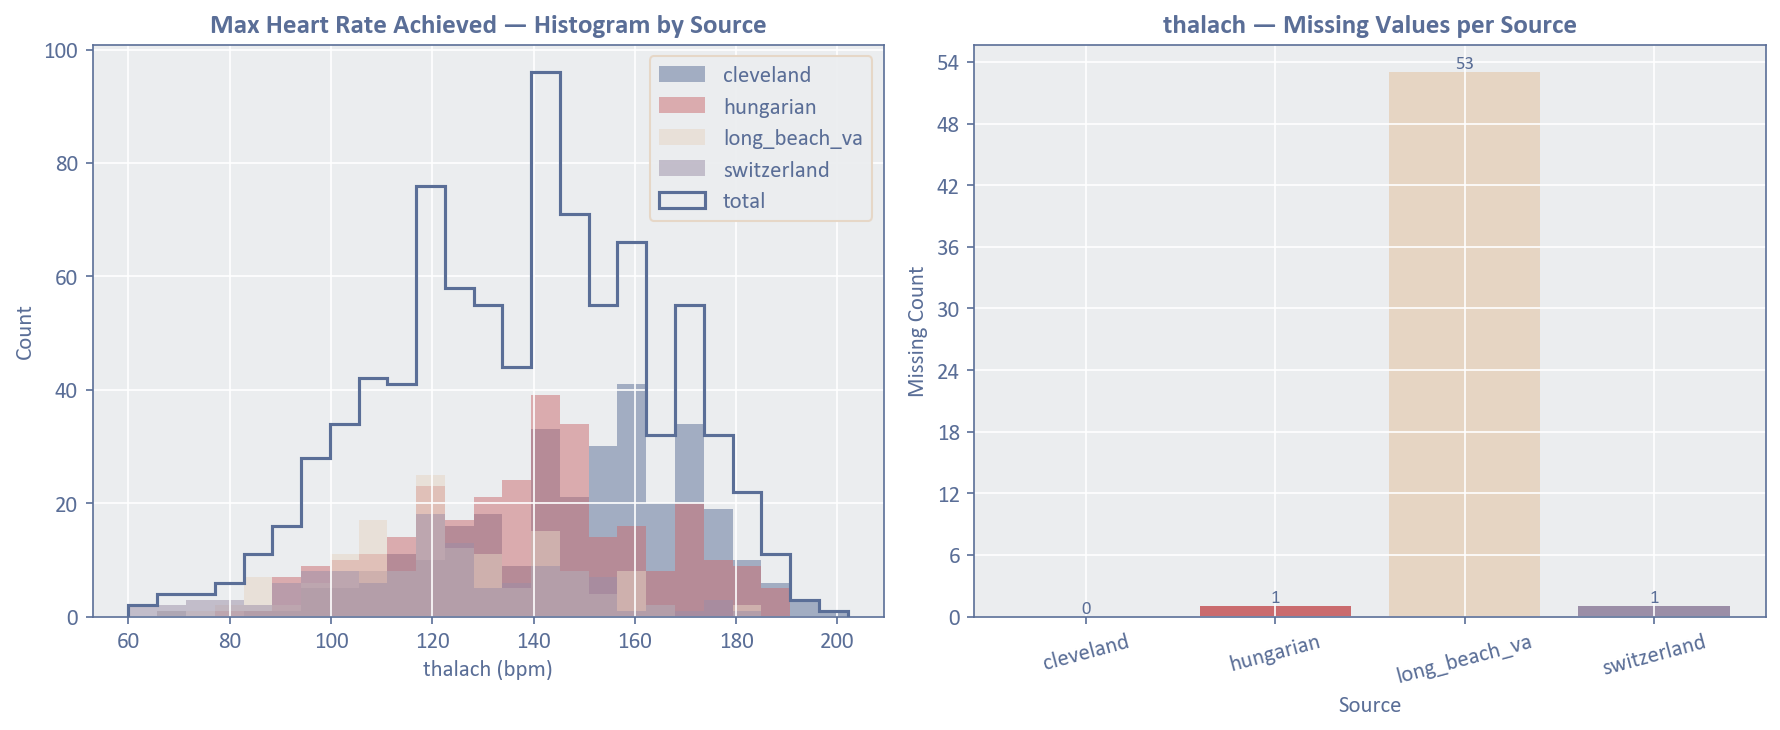

In [12]:
# --- thalach: histogram per source + total line ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bins = np.linspace(df["thalach"].dropna().min(), df["thalach"].dropna().max(), 26)
for s in SOURCES:
    vals = df.loc[df["source"] == s, "thalach"].dropna()
    axes[0].hist(vals, bins=bins, alpha=0.5, label=s, color=SOURCE_COLORS[s])
axes[0].hist(df["thalach"].dropna(), bins=bins, histtype="step",
             color=CLR_BLUE, linewidth=1.5, label="total")
axes[0].set_title("Max Heart Rate Achieved — Histogram by Source")
axes[0].set_xlabel("thalach (bpm)")
axes[0].set_ylabel("Count")
axes[0].legend()

plot_missing_per_source(axes[1], "thalach")

plt.tight_layout()
plt.savefig("results/figures/eda_numeric_histogram_thalach.png", dpi=150, bbox_inches="tight")
plt.show()

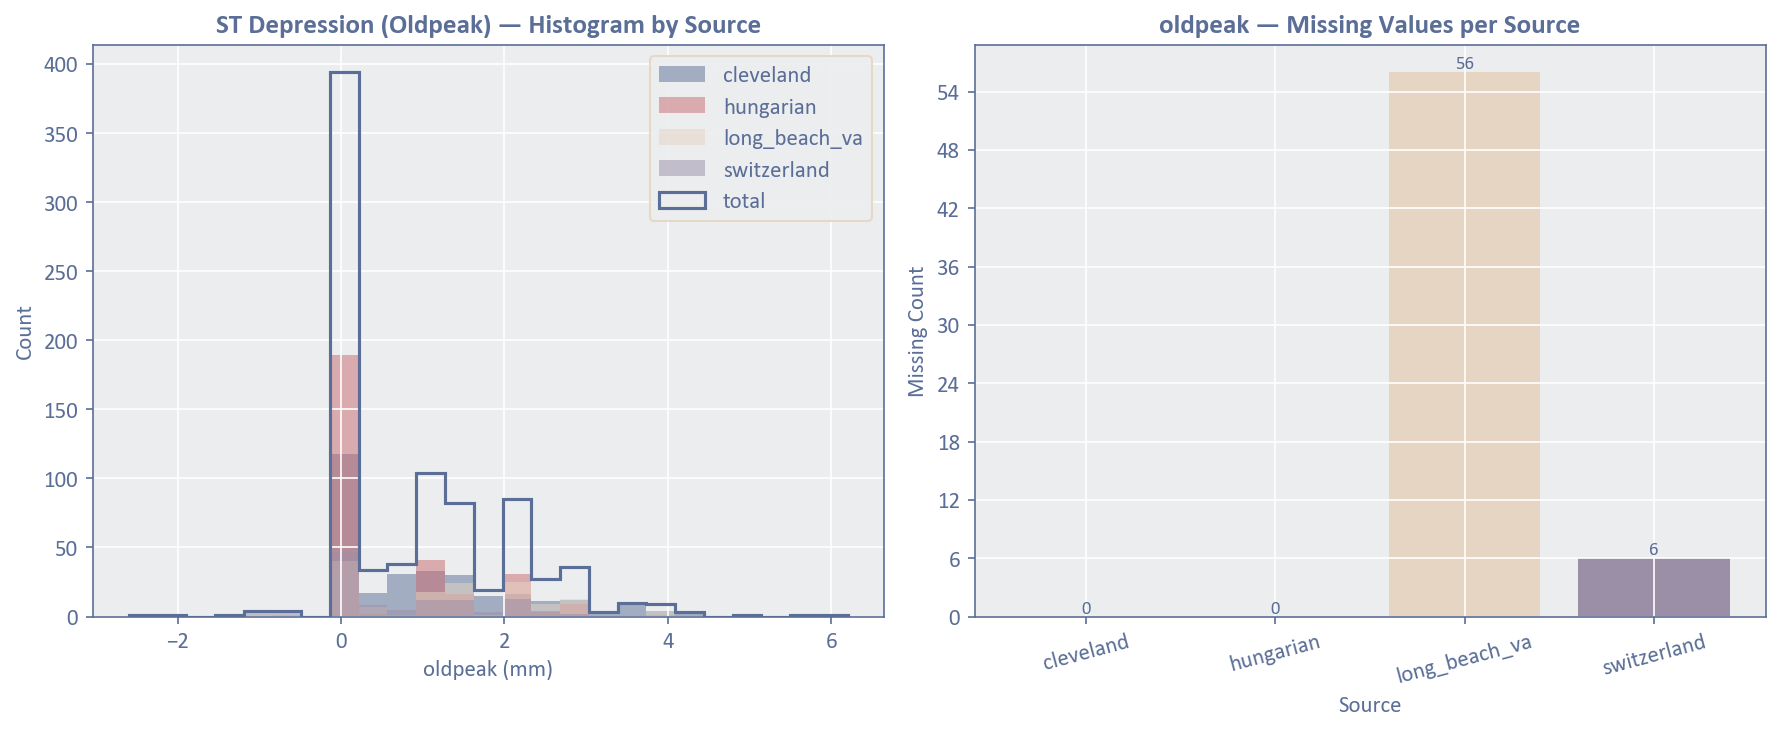

In [13]:
# --- oldpeak: histogram per source + total line ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bins = np.linspace(df["oldpeak"].dropna().min(), df["oldpeak"].dropna().max(), 26)
for s in SOURCES:
    vals = df.loc[df["source"] == s, "oldpeak"].dropna()
    axes[0].hist(vals, bins=bins, alpha=0.5, label=s, color=SOURCE_COLORS[s])
axes[0].hist(df["oldpeak"].dropna(), bins=bins, histtype="step",
             color=CLR_BLUE, linewidth=1.5, label="total")
axes[0].set_title("ST Depression (Oldpeak) — Histogram by Source")
axes[0].set_xlabel("oldpeak (mm)")
axes[0].set_ylabel("Count")
axes[0].legend()

plot_missing_per_source(axes[1], "oldpeak")

plt.tight_layout()
plt.savefig("results/figures/eda_numeric_histogram_oldpeak.png", dpi=150, bbox_inches="tight")
plt.show()

### Scatter Plots — Continuous Variable Pairs

The following scatter plots examine pairwise relationships between key continuous variables, coloured by source hospital.

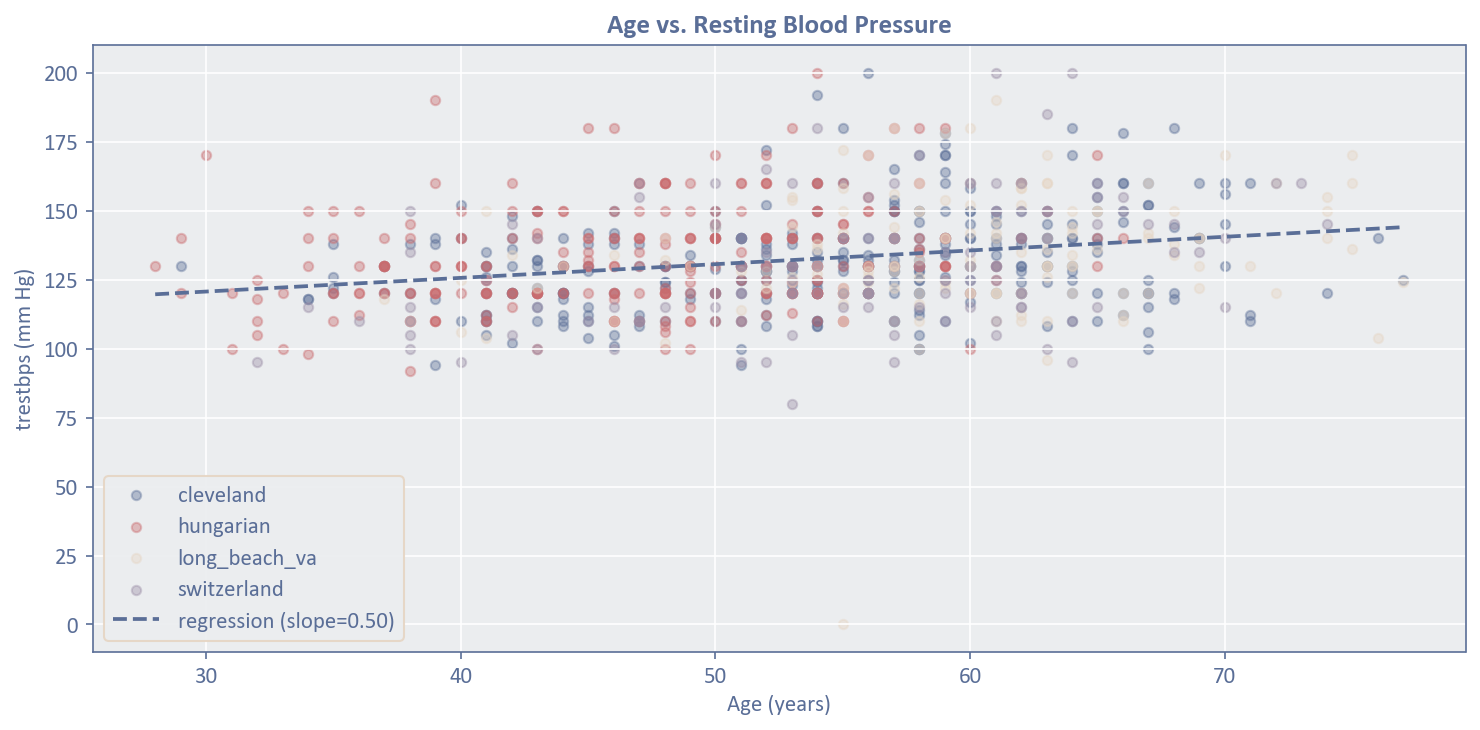

In [14]:
# --- Scatter: age vs. trestbps ---
fig, ax = plt.subplots(figsize=(10, 5))

for s in SOURCES:
    sub = df.loc[df["source"] == s, ["age", "trestbps"]].dropna()
    ax.scatter(sub["age"], sub["trestbps"], alpha=0.4, s=20,
               label=s, color=SOURCE_COLORS[s])

xy = df[["age", "trestbps"]].dropna()
m, b = np.polyfit(xy["age"], xy["trestbps"], 1)
x_line = np.array([xy["age"].min(), xy["age"].max()])
ax.plot(x_line, m * x_line + b, color=CLR_BLUE, linewidth=1.8,
        linestyle="--", label=f"regression (slope={m:.2f})")

ax.set_title("Age vs. Resting Blood Pressure")
ax.set_xlabel("Age (years)")
ax.set_ylabel("trestbps (mm Hg)")
ax.legend()

plt.tight_layout()
plt.savefig("results/figures/eda_numeric_scatter_age_trestbps.png", dpi=150, bbox_inches="tight")
plt.show()

Resting blood pressure shows a weak positive trend with age, consistent with the well-known age-related increase in arterial stiffness.

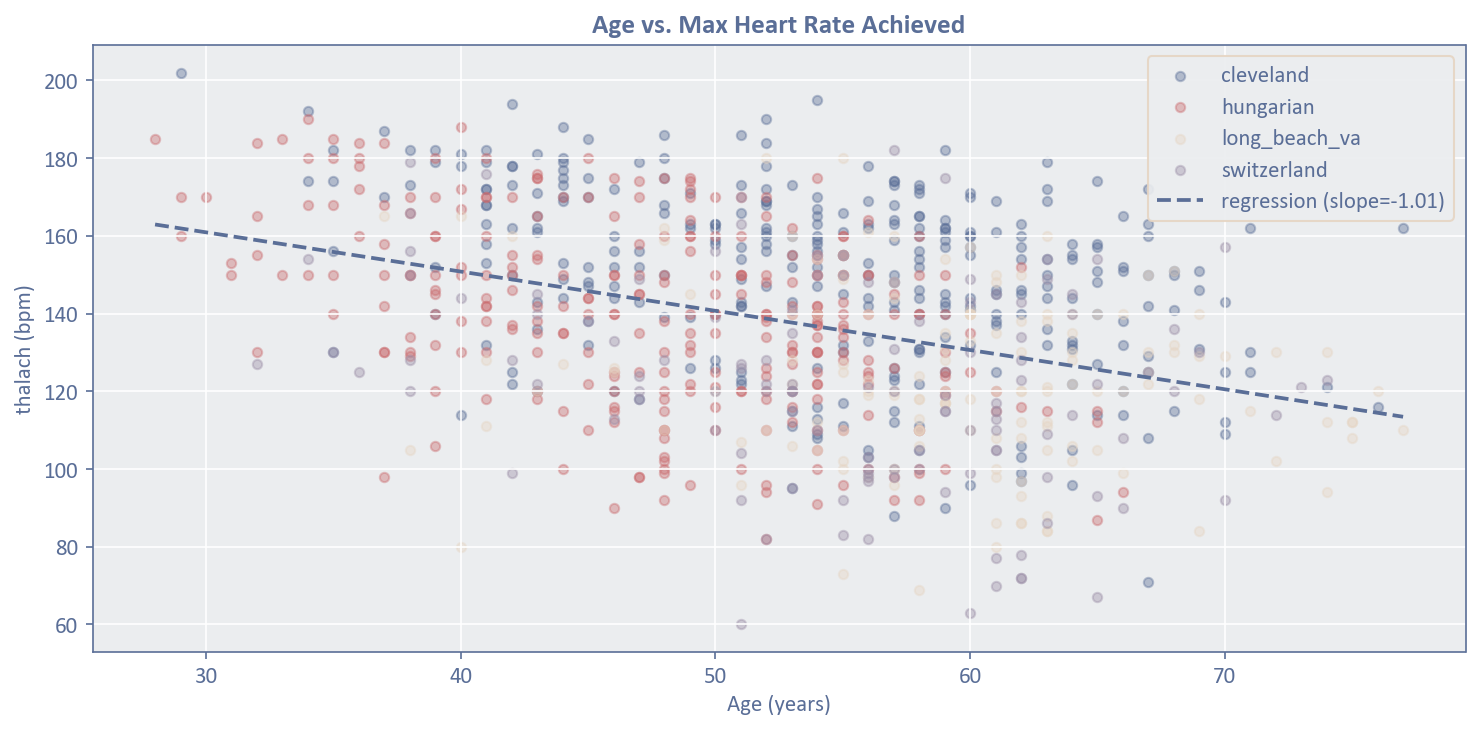

In [15]:
# --- Scatter: age vs. thalach ---
fig, ax = plt.subplots(figsize=(10, 5))

for s in SOURCES:
    sub = df.loc[df["source"] == s, ["age", "thalach"]].dropna()
    ax.scatter(sub["age"], sub["thalach"], alpha=0.4, s=20,
               label=s, color=SOURCE_COLORS[s])

xy = df[["age", "thalach"]].dropna()
m, b = np.polyfit(xy["age"], xy["thalach"], 1)
x_line = np.array([xy["age"].min(), xy["age"].max()])
ax.plot(x_line, m * x_line + b, color=CLR_BLUE, linewidth=1.8,
        linestyle="--", label=f"regression (slope={m:.2f})")

ax.set_title("Age vs. Max Heart Rate Achieved")
ax.set_xlabel("Age (years)")
ax.set_ylabel("thalach (bpm)")
ax.legend()

plt.tight_layout()
plt.savefig("results/figures/eda_numeric_scatter_age_thalach.png", dpi=150, bbox_inches="tight")
plt.show()

Maximum heart rate decreases clearly with age — a physiologically expected pattern that makes `thalach` a potentially strong predictor when combined with age.

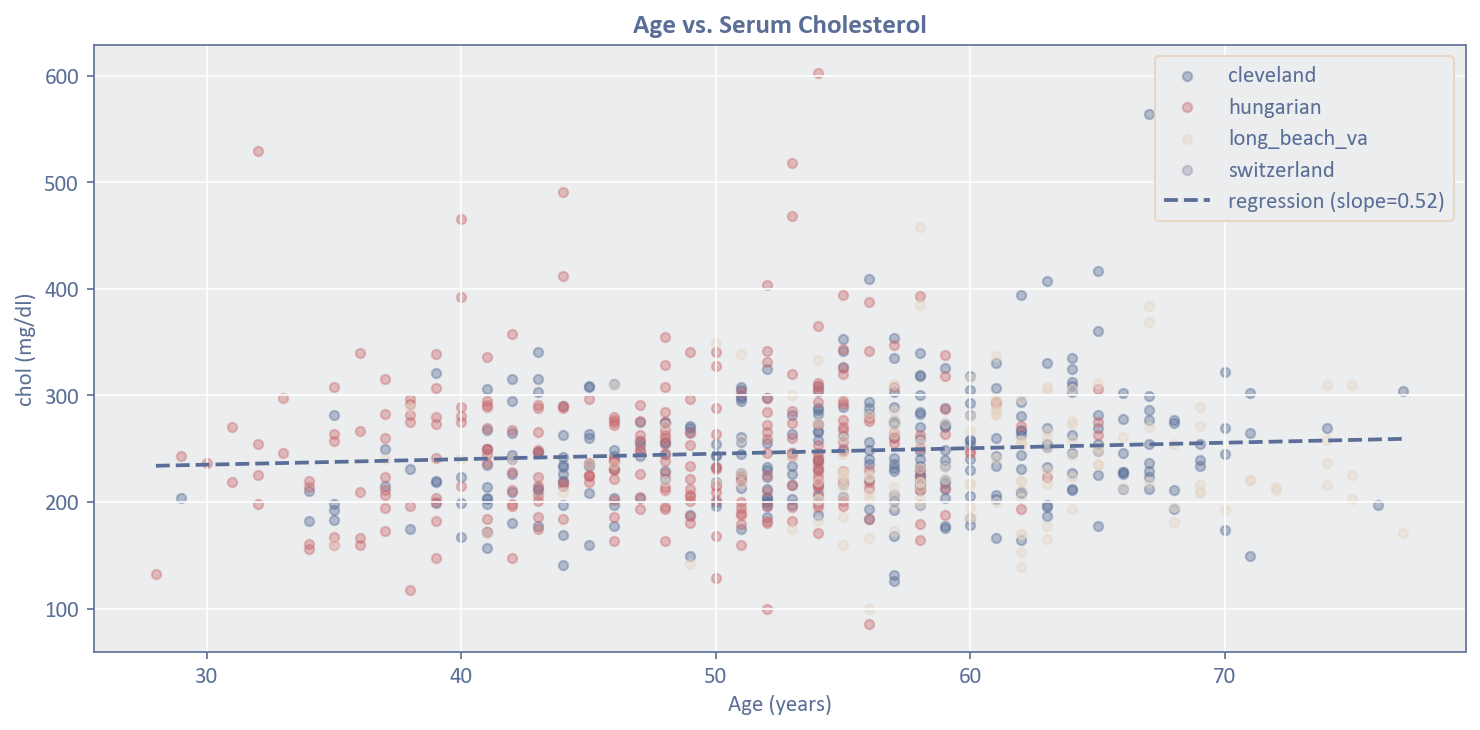

In [16]:
# --- Scatter: age vs. chol ---
fig, ax = plt.subplots(figsize=(10, 5))

for s in SOURCES:
    sub = df.loc[(df["source"] == s) & (df["chol"] > 0), ["age", "chol"]].dropna()
    ax.scatter(sub["age"], sub["chol"], alpha=0.4, s=20,
               label=s, color=SOURCE_COLORS[s])

xy = df.loc[df["chol"] > 0, ["age", "chol"]].dropna()
m, b = np.polyfit(xy["age"], xy["chol"], 1)
x_line = np.array([xy["age"].min(), xy["age"].max()])
ax.plot(x_line, m * x_line + b, color=CLR_BLUE, linewidth=1.8,
        linestyle="--", label=f"regression (slope={m:.2f})")

ax.set_title("Age vs. Serum Cholesterol")
ax.set_xlabel("Age (years)")
ax.set_ylabel("chol (mg/dl)")
ax.legend()

plt.tight_layout()
plt.savefig("results/figures/eda_numeric_scatter_age_chol.png", dpi=150, bbox_inches="tight")
plt.show()

Cholesterol shows a mild positive association with age, though the scatter is wide, indicating that age alone is a poor predictor of cholesterol levels.

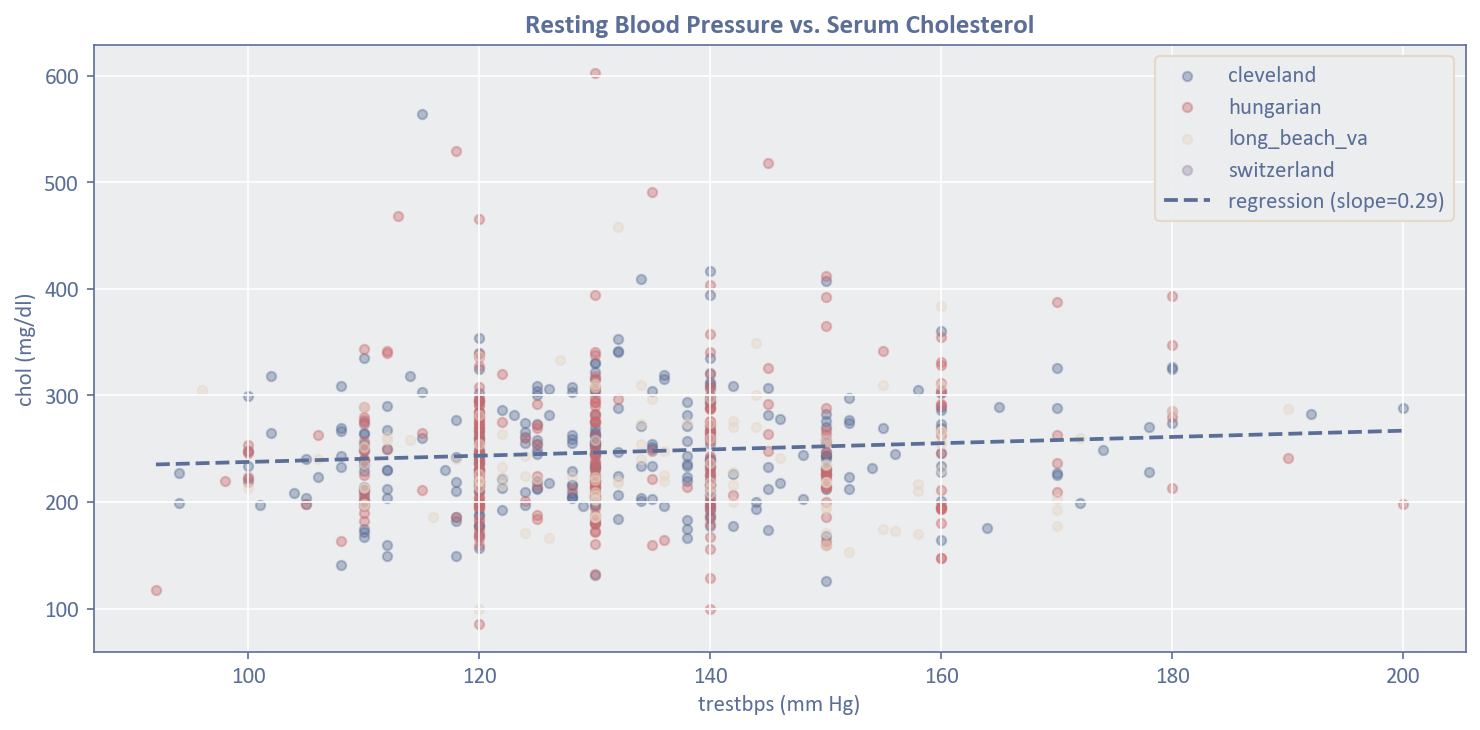

In [17]:
# --- Scatter: trestbps vs. chol ---
fig, ax = plt.subplots(figsize=(10, 5))

for s in SOURCES:
    sub = df.loc[(df["source"] == s) & (df["chol"] > 0), ["trestbps", "chol"]].dropna()
    ax.scatter(sub["trestbps"], sub["chol"], alpha=0.4, s=20,
               label=s, color=SOURCE_COLORS[s])

xy = df.loc[df["chol"] > 0, ["trestbps", "chol"]].dropna()
m, b = np.polyfit(xy["trestbps"], xy["chol"], 1)
x_line = np.array([xy["trestbps"].min(), xy["trestbps"].max()])
ax.plot(x_line, m * x_line + b, color=CLR_BLUE, linewidth=1.8,
        linestyle="--", label=f"regression (slope={m:.2f})")

ax.set_title("Resting Blood Pressure vs. Serum Cholesterol")
ax.set_xlabel("trestbps (mm Hg)")
ax.set_ylabel("chol (mg/dl)")
ax.legend()

plt.tight_layout()
plt.savefig("results/figures/eda_numeric_scatter_trestbps_chol.png", dpi=150, bbox_inches="tight")
plt.show()

Resting blood pressure and cholesterol show virtually no linear relationship, suggesting they capture independent aspects of cardiovascular risk.

## 1.3 — Categorical Variables

### Binary
- sex
- fbs
- exang

### Multiclass
- cp
- restecg
- thal
- slope

In [18]:
# --- Categorical EDA: shared helpers and color constants ---

NUM_LEVELS  = [0, 1, 2, 3, 4]
BINARY_COLORS = [CLR_BLUE, CLR_RED]   # blue = 0, rose = 1
MULTI_COLORS  = ["#5A6E97", "#CA6B6E", "#E6D5C3", "#9B8EA7", "#7A8FB5", "#D4918F"]


def plot_cat_by_group(ax, df, col, groupby, group_order, cat_labels, cat_colors, title, xlabel):
    """Grouped bar chart: groups on x-axis, one bar per category value of col."""
    sub = df[[groupby, col]].dropna()
    cat_vals = sorted(sub[col].unique())
    n_cats = len(cat_vals)
    width = 0.7 / n_cats
    x = np.arange(len(group_order))

    for i, val in enumerate(cat_vals):
        counts = [sub.loc[sub[groupby] == g, col].eq(val).sum() for g in group_order]
        offset = (i - (n_cats - 1) / 2) * width
        label = cat_labels.get(int(val), str(int(val)))
        ax.bar(x + offset, counts, width=width, label=label,
               color=cat_colors[i % len(cat_colors)], alpha=0.85,
               edgecolor="white", linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels([str(g) for g in group_order], rotation=15, ha="right")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.legend(fontsize=8)

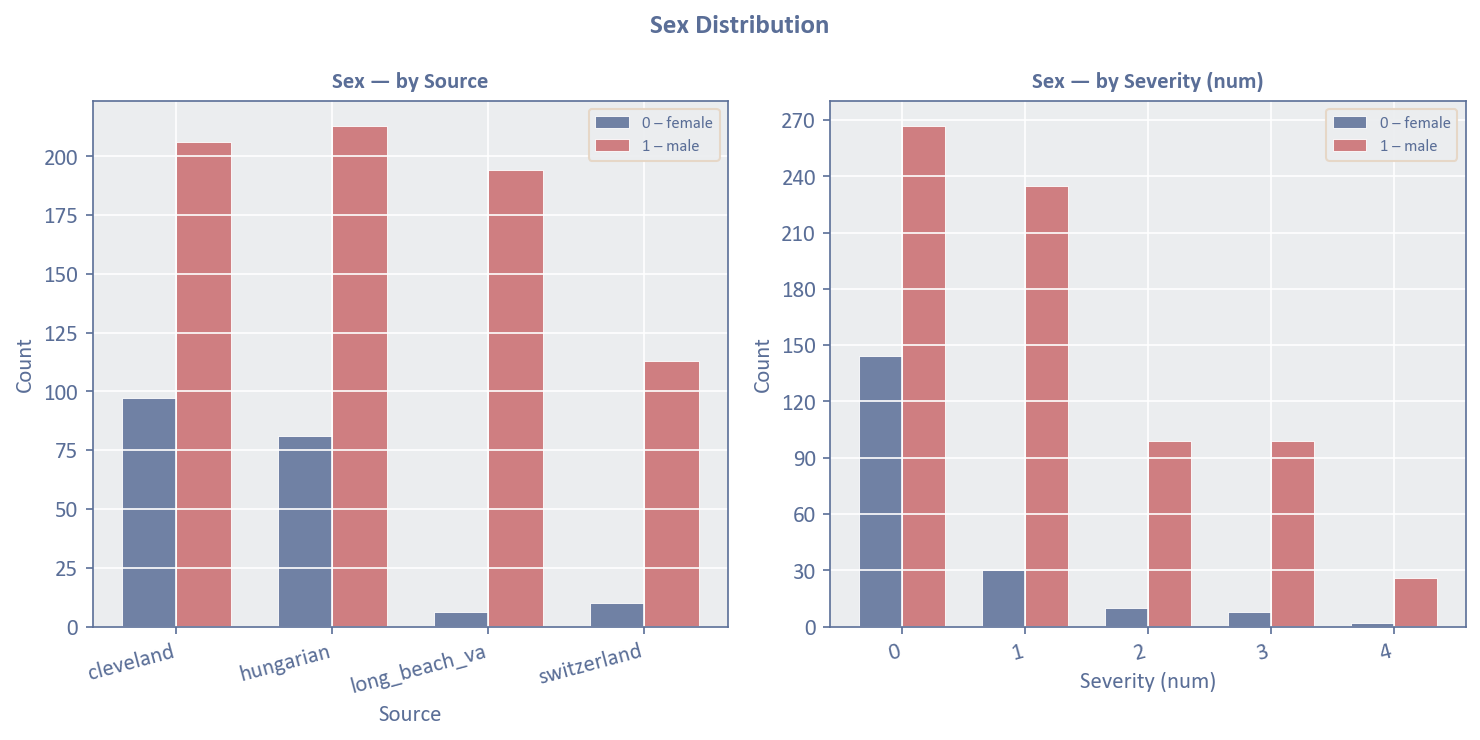

In [19]:
# --- sex: distribution by source (left) and by severity (right) ---
cat_labels = {0: "0 – female", 1: "1 – male"}

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_cat_by_group(axes[0], df, "sex", "source", SOURCES, cat_labels, BINARY_COLORS,
                  "Sex — by Source", "Source")
plot_cat_by_group(axes[1], df, "sex", "num", NUM_LEVELS, cat_labels, BINARY_COLORS,
                  "Sex — by Severity (num)", "Severity (num)")
fig.suptitle("Sex Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/eda_categorical_bar_sex.png", dpi=150, bbox_inches="tight")
plt.show()


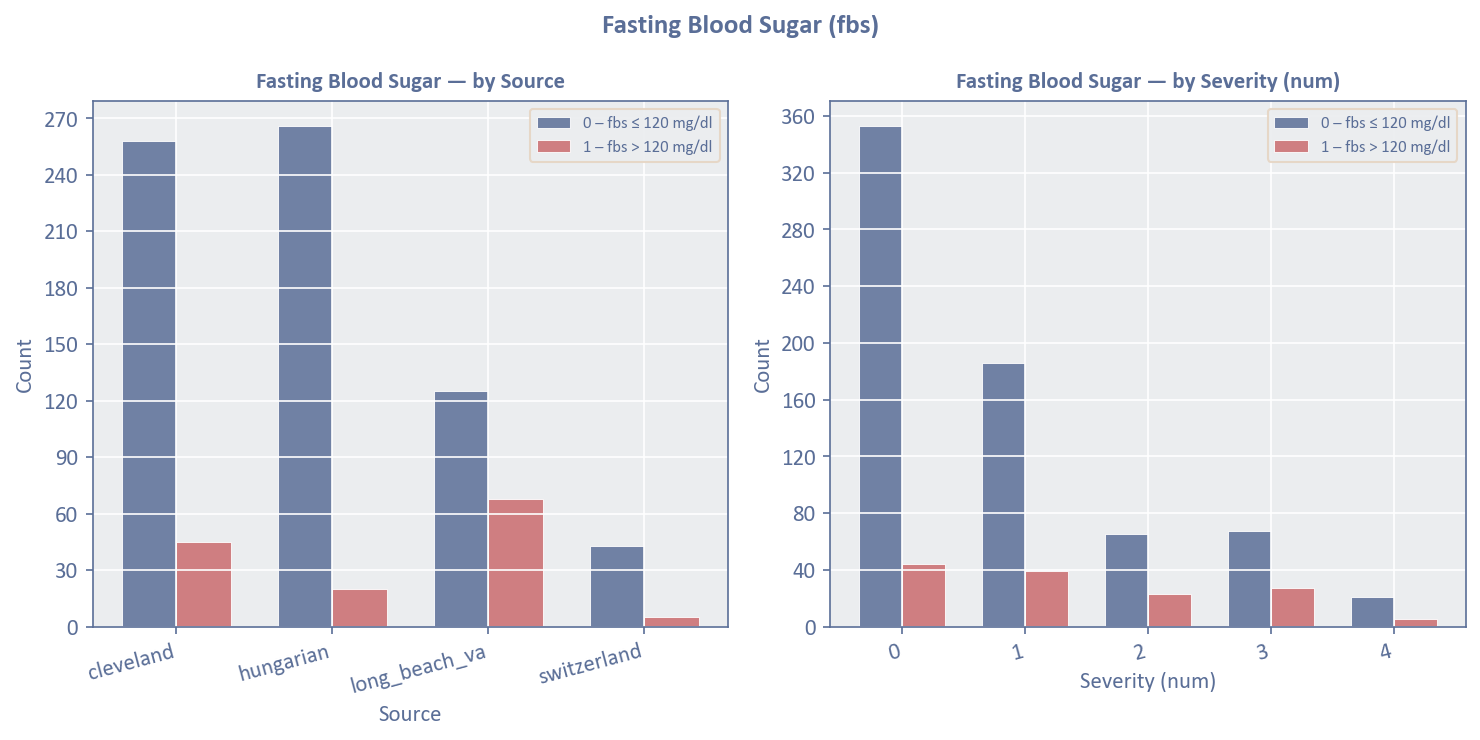

In [20]:
# --- fbs: distribution by source (left) and by severity (right) ---
cat_labels = {0: "0 – fbs ≤ 120 mg/dl", 1: "1 – fbs > 120 mg/dl"}

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_cat_by_group(axes[0], df, "fbs", "source", SOURCES, cat_labels, BINARY_COLORS,
                  "Fasting Blood Sugar — by Source", "Source")
plot_cat_by_group(axes[1], df, "fbs", "num", NUM_LEVELS, cat_labels, BINARY_COLORS,
                  "Fasting Blood Sugar — by Severity (num)", "Severity (num)")
fig.suptitle("Fasting Blood Sugar (fbs)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/eda_categorical_bar_fbs.png", dpi=150, bbox_inches="tight")
plt.show()


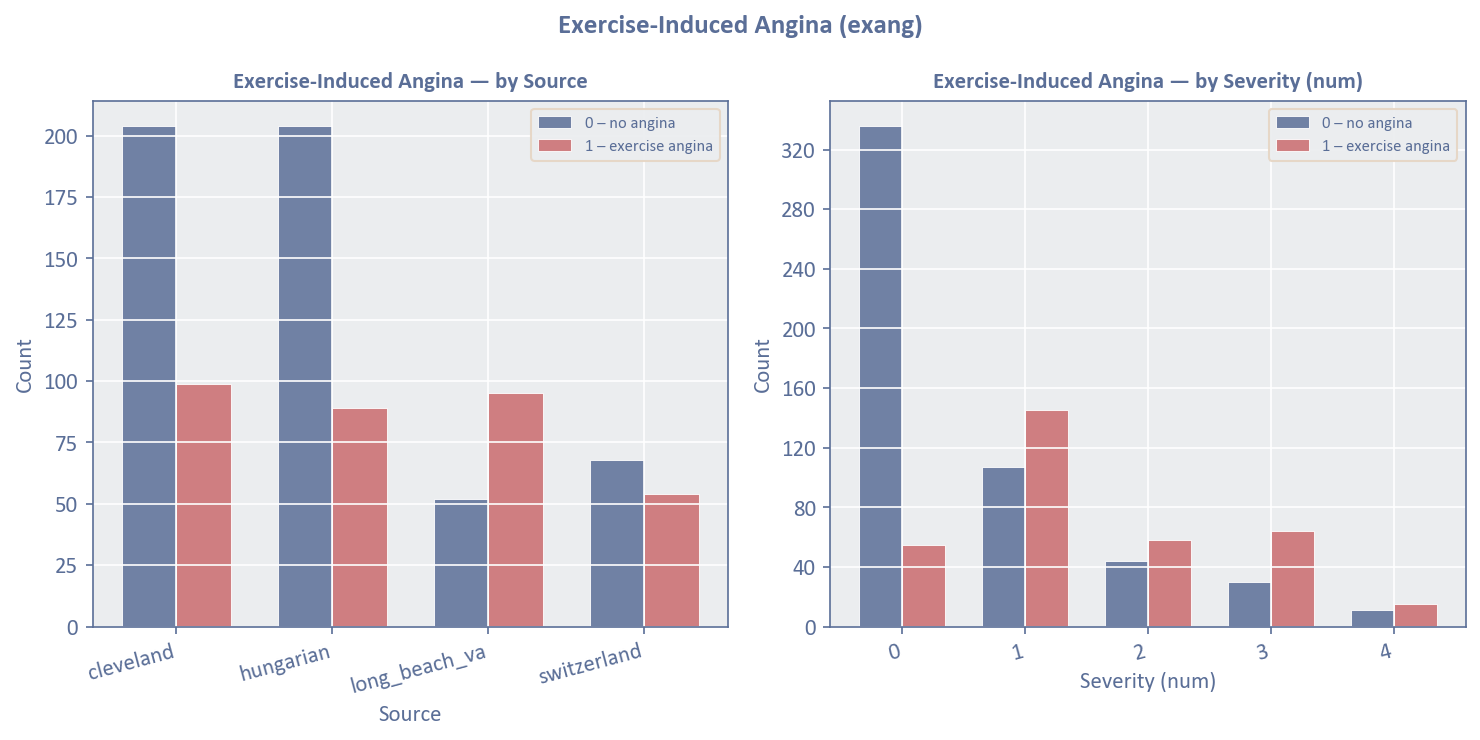

In [21]:
# --- exang: distribution by source (left) and by severity (right) ---
cat_labels = {0: "0 – no angina", 1: "1 – exercise angina"}

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_cat_by_group(axes[0], df, "exang", "source", SOURCES, cat_labels, BINARY_COLORS,
                  "Exercise-Induced Angina — by Source", "Source")
plot_cat_by_group(axes[1], df, "exang", "num", NUM_LEVELS, cat_labels, BINARY_COLORS,
                  "Exercise-Induced Angina — by Severity (num)", "Severity (num)")
fig.suptitle("Exercise-Induced Angina (exang)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/eda_categorical_bar_exang.png", dpi=150, bbox_inches="tight")
plt.show()


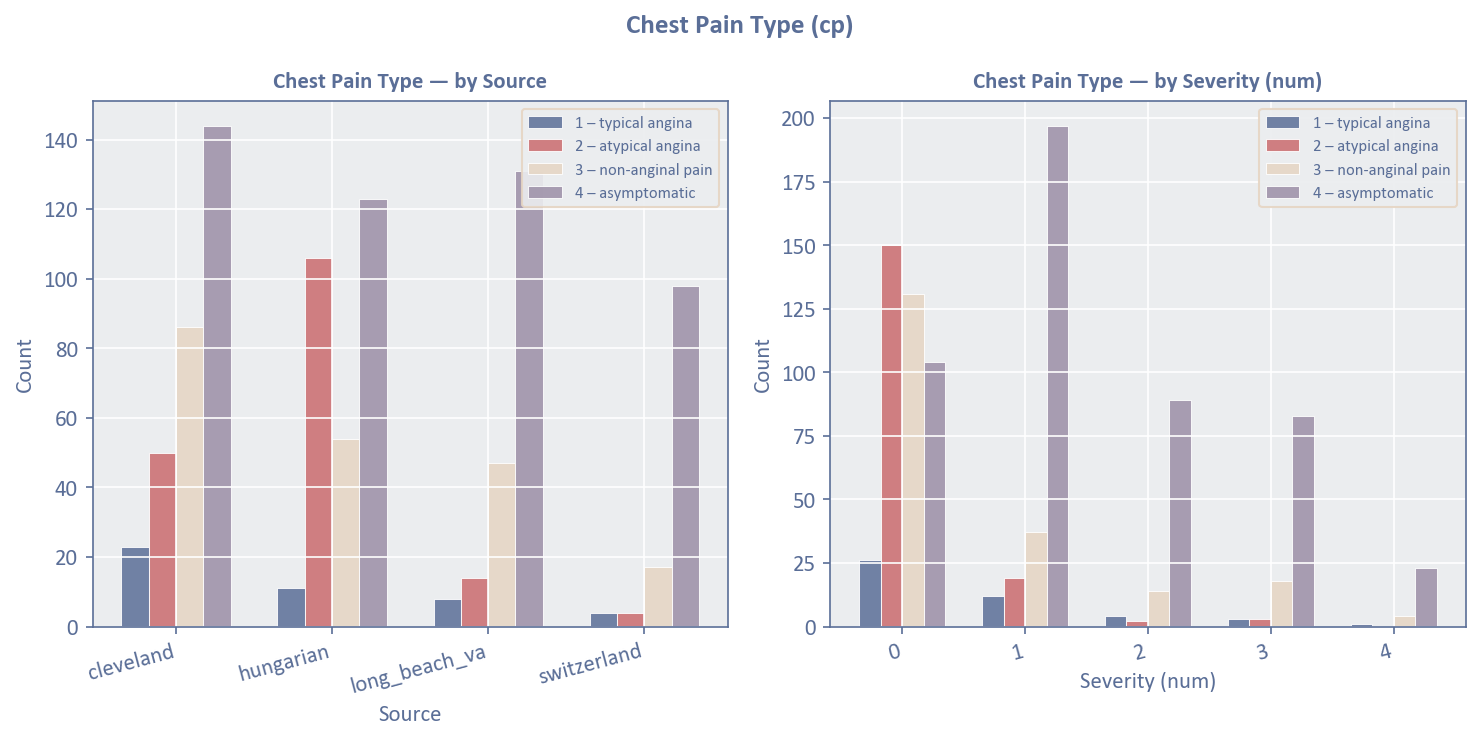

In [22]:
# --- cp: distribution by source (left) and by severity (right) ---
cat_labels = {1: "1 – typical angina", 2: "2 – atypical angina",
              3: "3 – non-anginal pain", 4: "4 – asymptomatic"}

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_cat_by_group(axes[0], df, "cp", "source", SOURCES, cat_labels, MULTI_COLORS,
                  "Chest Pain Type — by Source", "Source")
plot_cat_by_group(axes[1], df, "cp", "num", NUM_LEVELS, cat_labels, MULTI_COLORS,
                  "Chest Pain Type — by Severity (num)", "Severity (num)")
fig.suptitle("Chest Pain Type (cp)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/eda_categorical_bar_cp.png", dpi=150, bbox_inches="tight")
plt.show()


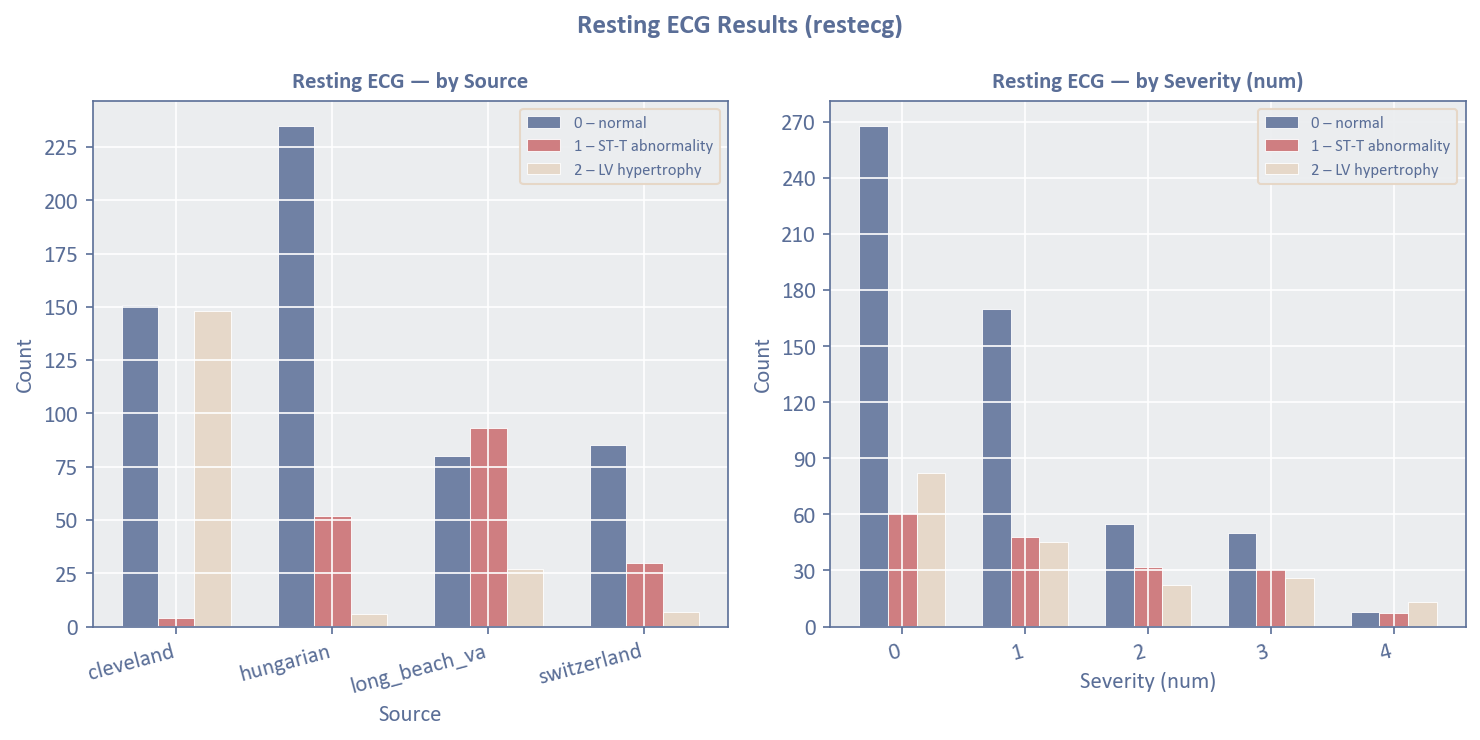

In [23]:
# --- restecg: distribution by source (left) and by severity (right) ---
cat_labels = {0: "0 – normal", 1: "1 – ST-T abnormality", 2: "2 – LV hypertrophy"}

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_cat_by_group(axes[0], df, "restecg", "source", SOURCES, cat_labels, MULTI_COLORS,
                  "Resting ECG — by Source", "Source")
plot_cat_by_group(axes[1], df, "restecg", "num", NUM_LEVELS, cat_labels, MULTI_COLORS,
                  "Resting ECG — by Severity (num)", "Severity (num)")
fig.suptitle("Resting ECG Results (restecg)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/eda_categorical_bar_restecg.png", dpi=150, bbox_inches="tight")
plt.show()


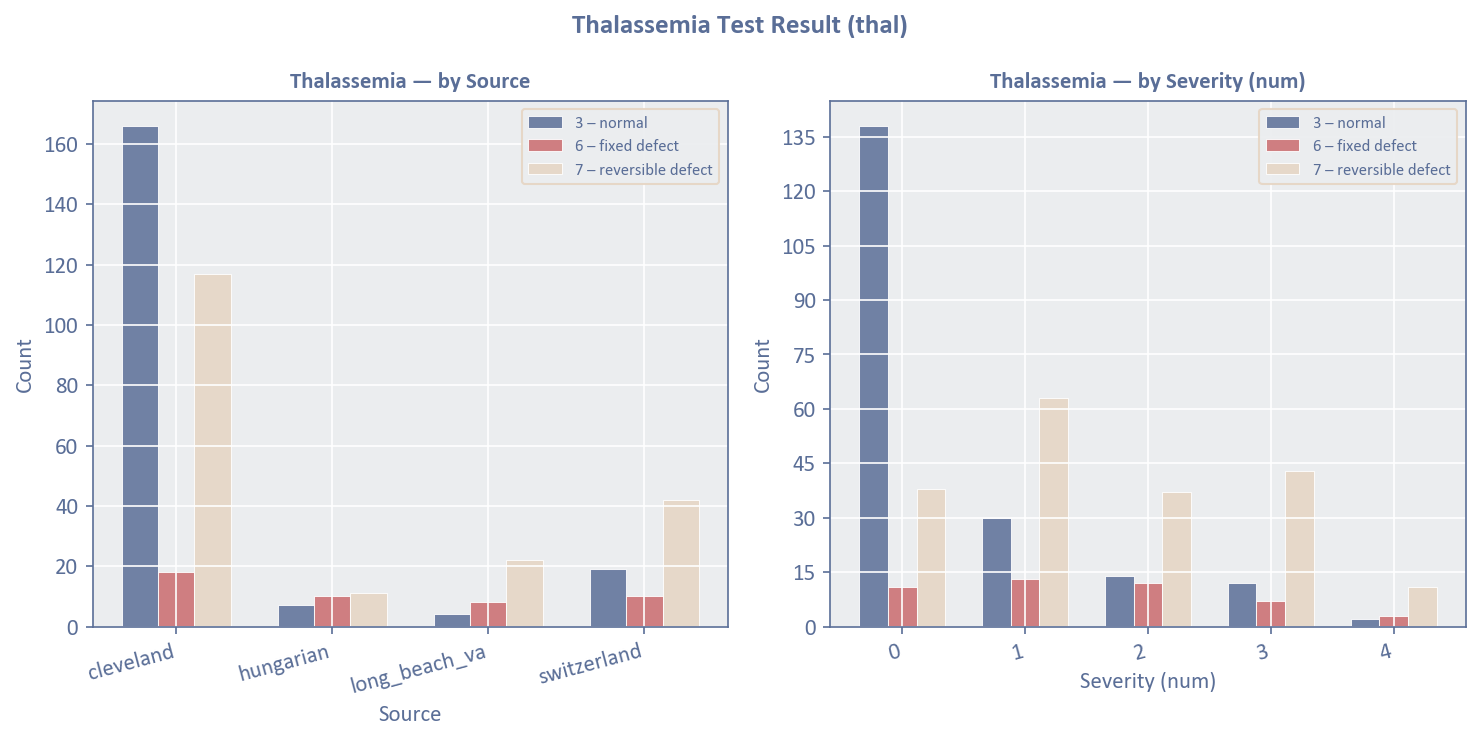

In [24]:
# --- thal: distribution by source (left) and by severity (right) ---
cat_labels = {3: "3 – normal", 6: "6 – fixed defect", 7: "7 – reversible defect"}

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_cat_by_group(axes[0], df, "thal", "source", SOURCES, cat_labels, MULTI_COLORS,
                  "Thalassemia — by Source", "Source")
plot_cat_by_group(axes[1], df, "thal", "num", NUM_LEVELS, cat_labels, MULTI_COLORS,
                  "Thalassemia — by Severity (num)", "Severity (num)")
fig.suptitle("Thalassemia Test Result (thal)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/eda_categorical_bar_thal.png", dpi=150, bbox_inches="tight")
plt.show()


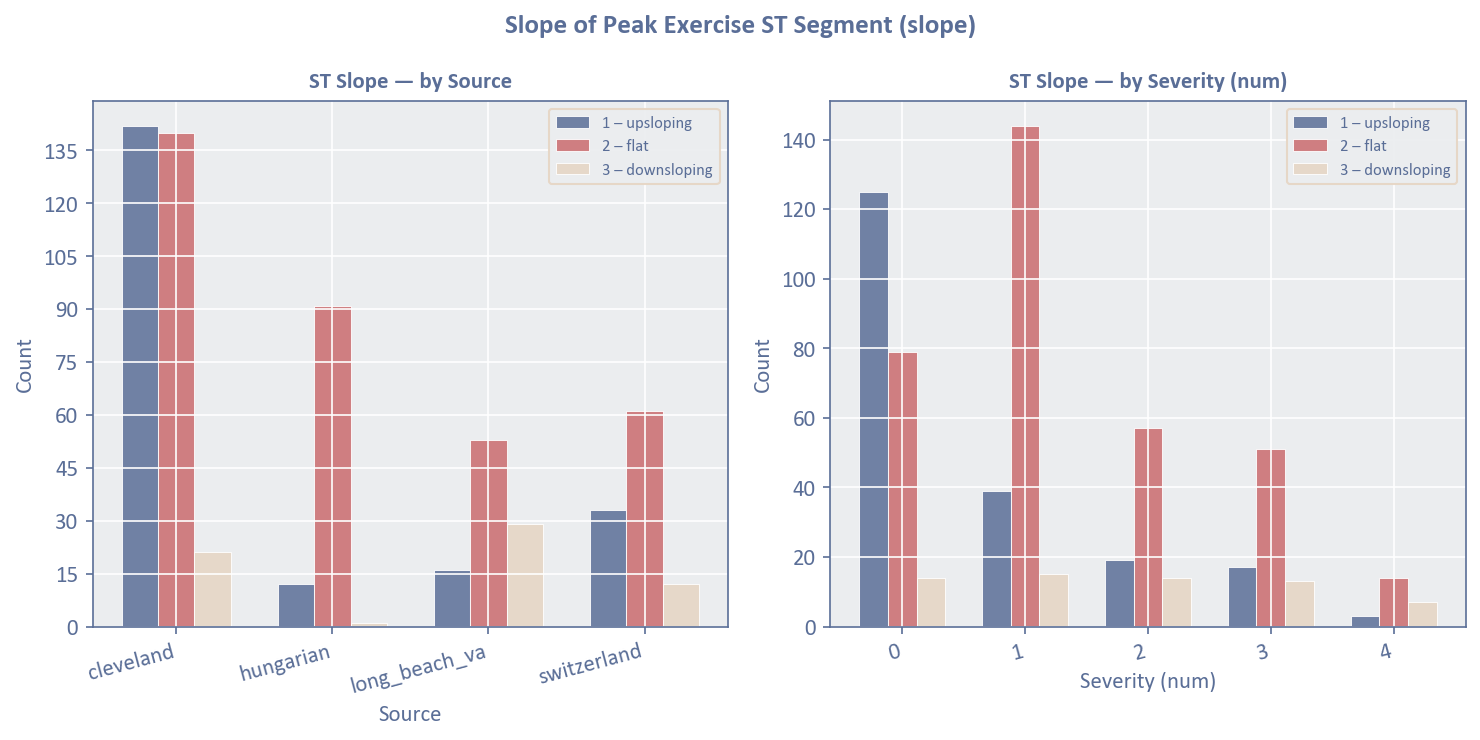

In [25]:
# --- slope: distribution by source (left) and by severity (right) ---
cat_labels = {1: "1 – upsloping", 2: "2 – flat", 3: "3 – downsloping"}

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_cat_by_group(axes[0], df, "slope", "source", SOURCES, cat_labels, MULTI_COLORS,
                  "ST Slope — by Source", "Source")
plot_cat_by_group(axes[1], df, "slope", "num", NUM_LEVELS, cat_labels, MULTI_COLORS,
                  "ST Slope — by Severity (num)", "Severity (num)")
fig.suptitle("Slope of Peak Exercise ST Segment (slope)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/eda_categorical_bar_slope.png", dpi=150, bbox_inches="tight")
plt.show()


## 1.4 — Correlation Analysis

## Correlation Strategy

Not all variables can be compared with the same measure. The appropriate statistic depends on the **measurement level** of the variables involved.

| Method | When to use | Assumption | Range |
|---|---|---|---|
| **Pearson r** | Two continuous variables | Linear relationship, (approx.) normal distribution | −1 to +1 |
| **Spearman ρ** | Continuous *or* ordinal variables | Monotonic relationship; no normality required | −1 to +1 |
| **Cramér's V** | Two nominal (categorical) variables | None — based on χ² test of independence | 0 to +1 |

### Why not Pearson / Spearman for nominal variables?

Nominal variables have **no meaningful numeric order**. For example, chest pain type `cp` is coded 1–4:

- 1 = typical angina, 2 = atypical angina, 3 = non-anginal pain, 4 = asymptomatic

Using Pearson or Spearman would imply that *asymptomatic (4) is four times more severe than typical angina (1)*, which is meaningless — the codes are just labels. Cramér's V instead tests whether the **distribution of categories differs** between groups, without assuming any ordering.

---

## Matrix A — Continuous & Ordinal Variables (Spearman ρ)

Variables: `age`, `trestbps`, `chol`, `thalach`, `oldpeak`, `ca`, `slope`, `num`

Spearman is chosen because `ca` (count, 0–3), `slope` (ordinal), and `num` (ordinal target) are not purely continuous, and the continuous variables are not guaranteed to be normally distributed.


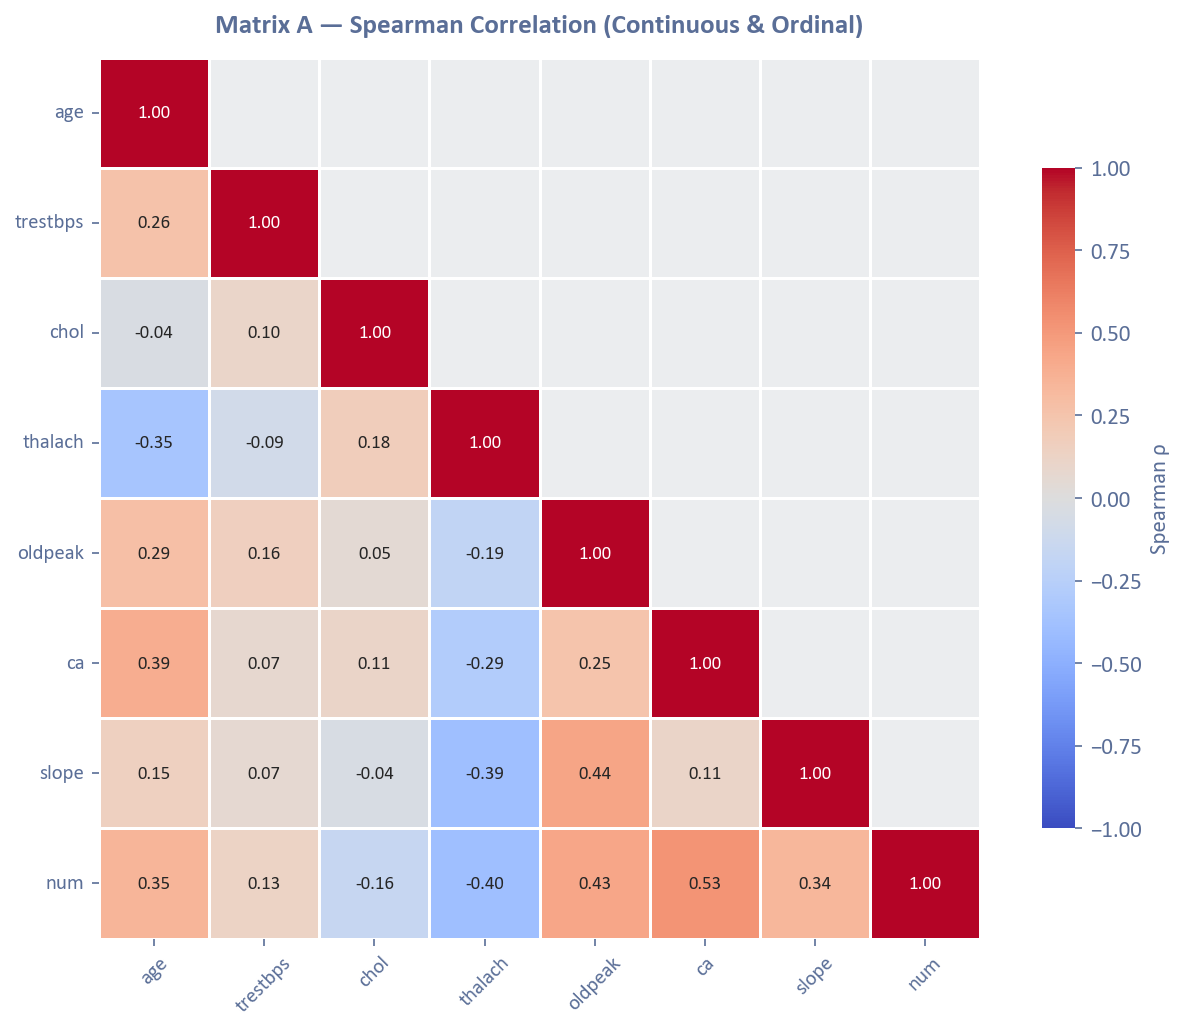

In [26]:
ORDINAL_COLS = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca", "slope", "num"]

corr_a = df[ORDINAL_COLS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))

mask = np.zeros_like(corr_a, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True  # upper triangle (keep lower + diagonal)

sns.heatmap(
    corr_a,
    ax=ax,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={"size": 9},
    square=True,
    cbar_kws={"shrink": 0.75, "label": "Spearman \u03c1"},
)

ax.set_title("Matrix A \u2014 Spearman Correlation (Continuous & Ordinal)", fontsize=13, pad=12)
ax.tick_params(axis="x", rotation=45, labelsize=10)
ax.tick_params(axis="y", rotation=0, labelsize=10)
ax.grid(False)

plt.tight_layout()
plt.savefig("results/figures/eda_correlation_matrix_a_spearman.png", dpi=150, bbox_inches="tight")
plt.show()

## Matrix B — Categorical Association Matrix (Cramér's V)

Variables: `sex`, `fbs`, `exang`, `cp`, `restecg`, `thal`, `source_code`, `target` (num binarized: 0 = no disease, 1 = disease)

All variables here are **nominal categorical** — none have a meaningful numeric order. Cramér's V is derived from the χ² statistic and measures the strength of association between two categorical variables. Unlike Pearson/Spearman, it is always **0–1** (no direction), where 0 = no association and 1 = perfect association.

[dython](http://shakedzy.xyz/dython/) `associations()` automatically applies Cramér's V for all nominal-nominal pairs.


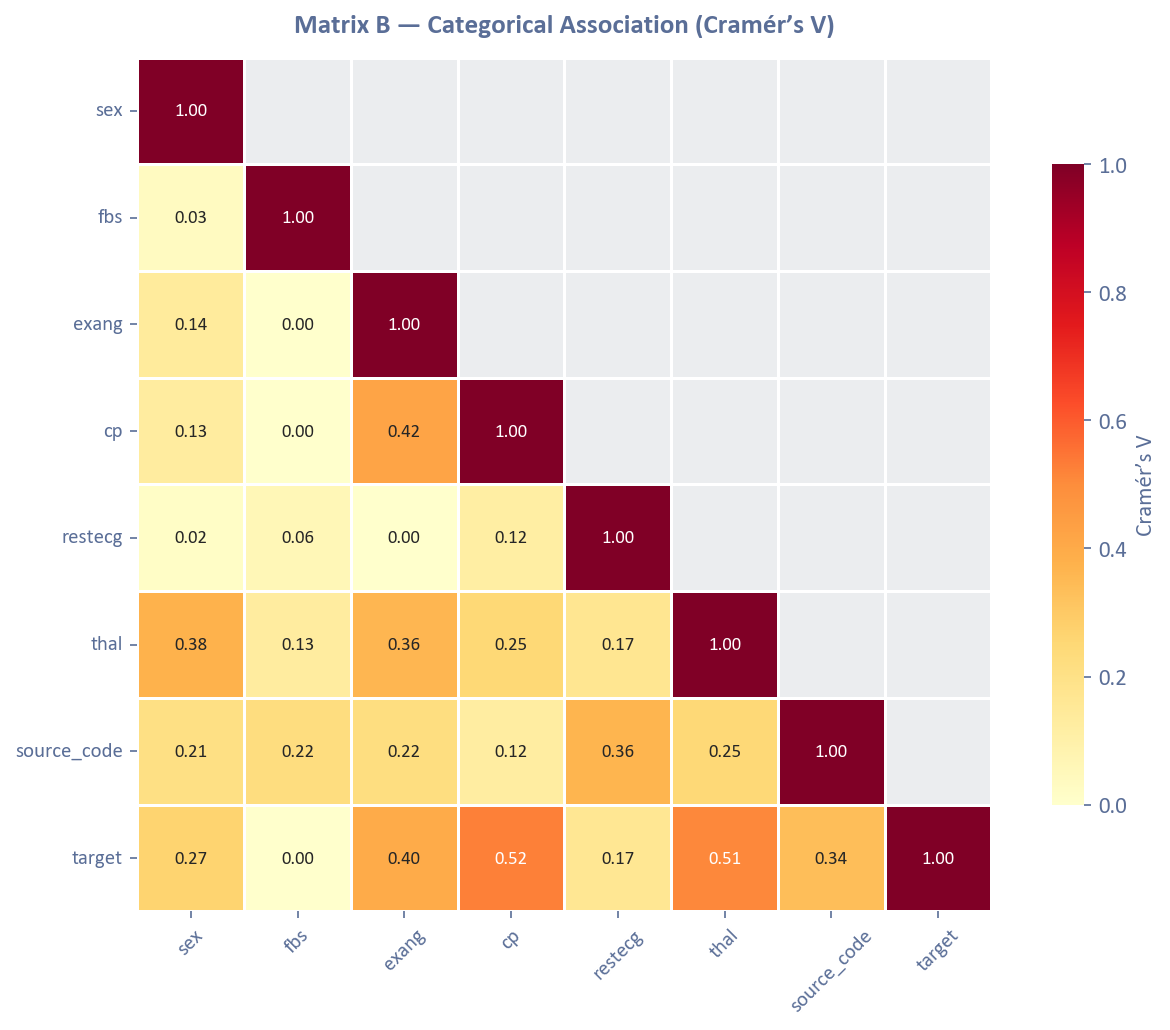

In [27]:
CAT_COLS = ["sex", "fbs", "exang", "cp", "restecg", "thal", "source_code"]

df_cat = df[CAT_COLS].copy()
df_cat["target"] = (df["num"] > 0).astype(int)  # binarize: 0 = no disease, 1 = disease

# Cast all to string-category so dython treats them as nominal
for col in df_cat.columns:
    df_cat[col] = df_cat[col].astype("category")

result = associations(
    df_cat,
    nominal_columns="all",
    plot=False,
    nan_strategy="drop_samples",
)
corr_b = result["corr"]

fig, ax = plt.subplots(figsize=(9, 7))

mask_b = np.zeros_like(corr_b, dtype=bool)
mask_b[np.triu_indices_from(mask_b, k=1)] = True

sns.heatmap(
    corr_b,
    ax=ax,
    mask=mask_b,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    annot_kws={"size": 9},
    square=True,
    cbar_kws={"shrink": 0.75, "label": "Cram\u00e9r\u2019s V"},
)

ax.set_title("Matrix B \u2014 Categorical Association (Cram\u00e9r\u2019s V)", fontsize=13, pad=12)
ax.tick_params(axis="x", rotation=45, labelsize=10)
ax.tick_params(axis="y", rotation=0, labelsize=10)
ax.grid(False)

plt.tight_layout()
plt.savefig("results/figures/eda_correlation_matrix_b_cramers_v.png", dpi=150, bbox_inches="tight")
plt.show()

## Matrix C — Full Association Matrix (all variables)

Matrix A and B only capture within-type associations. The question *"Does chest pain type (cp) influence maximum heart rate (thalach)?"* — one nominal, one numeric — falls into neither.

dython's `associations()` fills this gap by applying the right measure for each pair automatically:

| Pair type | Measure applied |
|---|---|
| Numeric × Numeric | Pearson r |
| Categorical × Categorical | Cramér's V |
| Numeric × Categorical | Correlation Ratio η (how much of the numeric variable's variance is explained by the categorical grouping) |

The resulting matrix is **symmetric** and covers all cross-type relationships in one view. Nominal columns are declared explicitly so dython does not mis-treat coded integers (e.g. `cp = 3`) as continuous.


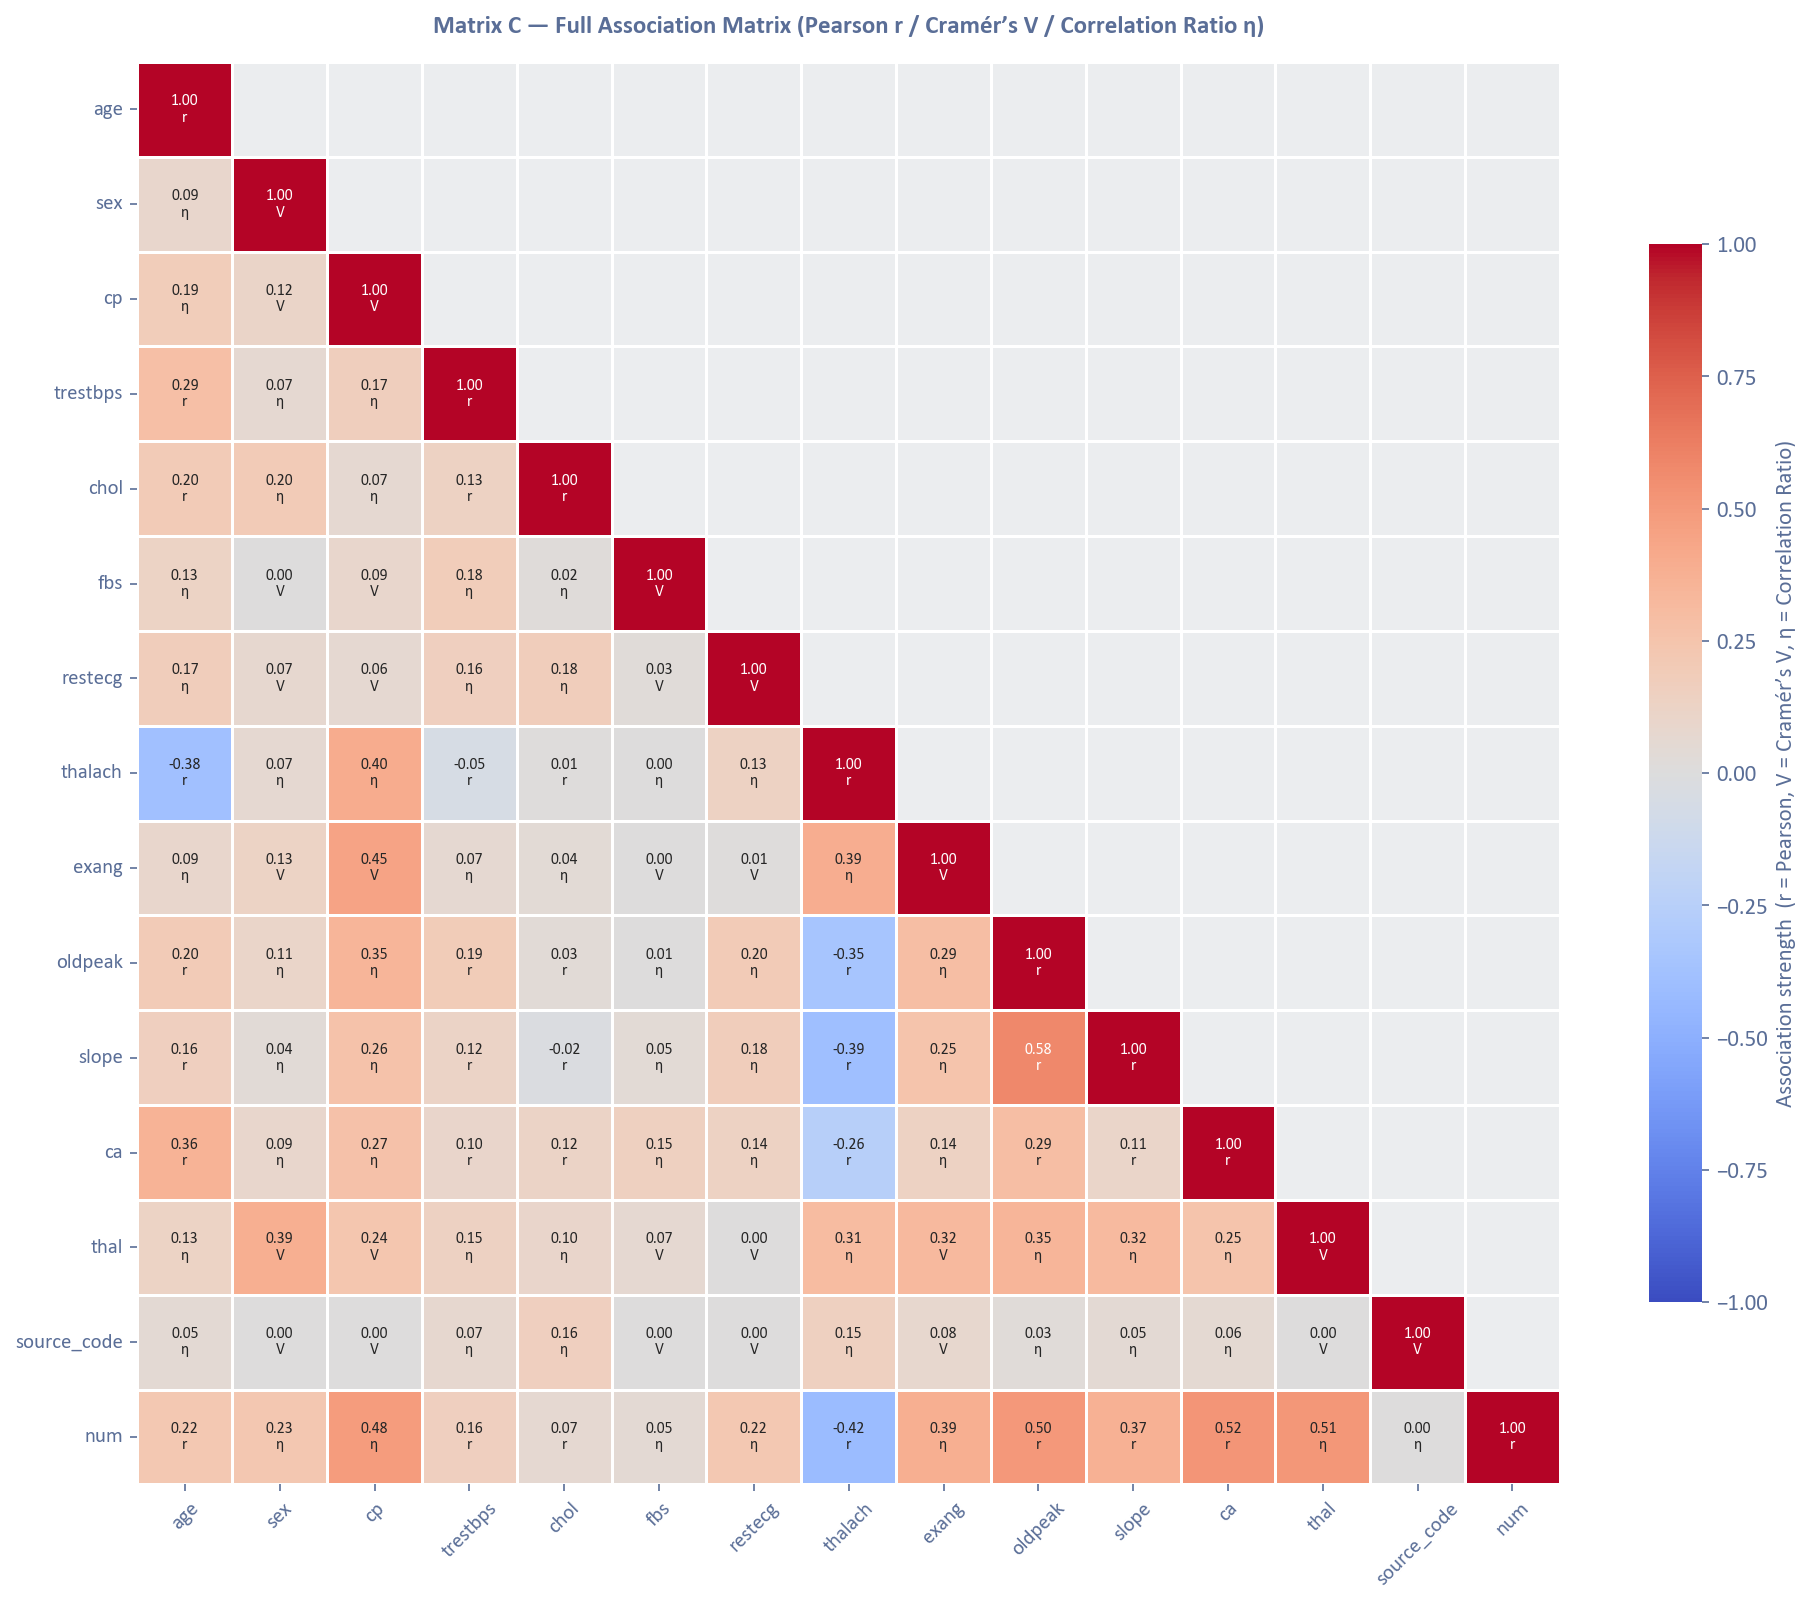

In [28]:
ALL_COLS = ["age", "sex", "cp", "trestbps", "chol", "fbs",
            "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal",
            "source_code", "num"]

# Declare which columns are nominal so dython doesn't treat their codes as numeric
NOMINAL_COLS = ["sex", "cp", "fbs", "restecg", "exang", "thal", "source_code"]

df_all = df[ALL_COLS].copy()

result_c = associations(
    df_all,
    nominal_columns=NOMINAL_COLS,
    plot=False,
    nan_strategy="drop_samples",
)
corr_c = result_c["corr"]

# Build annotation matrix that shows the measure type per cell
NUMERIC_COLS = [c for c in ALL_COLS if c not in NOMINAL_COLS]

def cell_label(r, c):
    """Return formatted value + measure symbol for each cell."""
    v = corr_c.loc[r, c]
    r_num = r in NUMERIC_COLS
    c_num = c in NUMERIC_COLS
    if r_num and c_num:
        sym = "r"
    elif not r_num and not c_num:
        sym = "V"
    else:
        sym = "\u03b7"
    return f"{v:.2f}\n{sym}"

annot = pd.DataFrame(
    [[cell_label(r, c) for c in corr_c.columns] for r in corr_c.index],
    index=corr_c.index,
    columns=corr_c.columns,
)

fig, ax = plt.subplots(figsize=(13, 11))

mask_c = np.zeros_like(corr_c, dtype=bool)
mask_c[np.triu_indices_from(mask_c, k=1)] = True

sns.heatmap(
    corr_c,
    ax=ax,
    mask=mask_c,
    annot=annot,
    fmt="",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={"size": 7.5},
    square=True,
    cbar_kws={"shrink": 0.7, "label": "Association strength  (r = Pearson, V = Cram\u00e9r\u2019s V, \u03b7 = Correlation Ratio)"},
)

ax.set_title("Matrix C \u2014 Full Association Matrix (Pearson r / Cram\u00e9r\u2019s V / Correlation Ratio \u03b7)",
             fontsize=12, pad=14)
ax.tick_params(axis="x", rotation=45, labelsize=10)
ax.tick_params(axis="y", rotation=0, labelsize=10)
ax.grid(False)

plt.tight_layout()
plt.savefig("results/figures/eda_correlation_matrix_c_full.png", dpi=150, bbox_inches="tight")
plt.show()

# 2 — Data Preprocessing

This chapter documents the preprocessing pipeline applied to the raw UCI Heart Disease dataset before modelling. Each step is implemented as a reusable function in `src/preprocessing.py`.

In [29]:
import sys, os
sys.path.append(os.path.abspath("."))

import pandas as pd
from src.data_loader import load_heart_disease
from src.preprocessing import (
    encode_source, drop_ca, binarize_num,
    fix_zero_missing, impute_missing, preprocess,
)

df_raw = load_heart_disease()
print(f"Raw shape: {df_raw.shape}")
print(df_raw.dtypes)

Raw shape: (920, 15)
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
num           int64
source          str
dtype: object


## 2.1 — Encode Source

Replace the `source` string column with a numeric `source_code` (1 = cleveland, 2 = hungarian, 3 = long_beach_va, 4 = switzerland).

In [30]:
df = encode_source(df_raw)
print(df[["source_code"]].value_counts().sort_index())
df.head(5)

source_code
1              303
2              294
3              200
4              123
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,source_code
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,1
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,1
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,1


## 2.2 — Drop `ca`

`ca` has too many missing values across sources and is excluded from the processed dataset.

In [31]:
df = drop_ca(df)
print(f"Columns after dropping ca: {list(df.columns)}")

Columns after dropping ca: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'thal', 'num', 'source_code']


## 2.3 — Binarize Target (`num`)

Convert `num` (0–4 severity) to binary: 0 = no disease, 1 = disease present. `num` is moved to the last column.

In [32]:
df = binarize_num(df)
print(df["num"].value_counts().sort_index())
print(f"Column order: {list(df.columns)}")
df.head(5)

num
0    411
1    509
Name: count, dtype: int64
Column order: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'thal', 'source_code', 'num']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,thal,source_code,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,6.0,1,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,1,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,3.0,1,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,3.0,1,0


## 2.4 — Fix Zero-as-Missing Values

`chol` contains 172 zero values which are physiologically impossible (serum cholesterol cannot be 0 mg/dl). Similarly, `trestbps` contains 1 zero value (resting blood pressure cannot be 0 mm Hg). These are treated as missing and replaced with NaN before imputation.

In [33]:
print(f"Zero values in chol:     {(df['chol'] == 0).sum()}")
print(f"Zero values in trestbps: {(df['trestbps'] == 0).sum()}")

df = fix_zero_missing(df)

print(f"\nAfter correction — NaN in chol:     {df['chol'].isna().sum()}")
print(f"After correction — NaN in trestbps: {df['trestbps'].isna().sum()}")

Zero values in chol:     172
Zero values in trestbps: 1

After correction — NaN in chol:     202
After correction — NaN in trestbps: 60


## 2.5 — Impute Missing Values

Missing values are imputed as follows:
- **Continuous** variables (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`): imputed with the **median**
- **Categorical** variables (`sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `thal`): imputed with the **mode** (most frequent value)

Note: Imputation is applied to the full dataset before the train/test split. This introduces minor data leakage, which is acceptable given the moderate sample size (n = 920).

In [34]:
print("Missing values BEFORE imputation:")
print(df.isna().sum())
print(f"\nTotal NaN: {df.isna().sum().sum()}")

df = impute_missing(df)

print("\n--- After imputation ---")
print(f"Total NaN: {df.isna().sum().sum()}")
assert df.isna().sum().sum() == 0, "Imputation incomplete — NaN values remain!"
print("All missing values successfully imputed.")

Missing values BEFORE imputation:
age              0
sex              0
cp               0
trestbps        60
chol           202
fbs             90
restecg          2
thalach         55
exang           55
oldpeak         62
slope          309
thal           486
source_code      0
num              0
dtype: int64

Total NaN: 1321

--- After imputation ---
Total NaN: 0
All missing values successfully imputed.


## 2.6 — Save Processed Dataset

In [35]:
out_path = "data/processed/heart_disease_processed.csv"
df.to_csv(out_path, index=False)
print(f"Saved to {out_path}")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.describe()

Saved to data/processed/heart_disease_processed.csv
Shape: 920 rows x 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,thal,source_code,num
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,53.510870,0.789130,3.250000,132.136957,245.222826,0.150000,0.603261,137.692391,0.366304,0.853261,1.847826,3.984783,2.155435,0.553261
std,9.424685,0.408148,0.930969,17.929761,51.785328,0.357266,0.805443,25.145235,0.482056,1.058049,0.516007,1.680000,1.028840,0.497426
min,28.000000,0.000000,1.000000,80.000000,85.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,1.000000,3.000000,1.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,217.750000,0.000000,0.000000,120.000000,0.000000,0.000000,2.000000,3.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,239.500000,0.000000,0.000000,140.000000,0.000000,0.500000,2.000000,3.000000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,267.000000,0.000000,1.000000,156.000000,1.000000,1.500000,2.000000,6.000000,3.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,7.000000,4.000000,1.000000


# 3 — Logistic Regression

This chapter implements an **interpretable logistic regression model** for heart disease prediction. Logistic regression serves as the primary modelling approach because it is well suited for binary outcomes and allows direct interpretation through model coefficients.

The model uses all 12 clinical features (without `source_code`, see Chapter 5 for rationale). To reduce overfitting, **L1 regularization (LASSO)** is applied, which shrinks less informative coefficients towards zero.

## Focus: Minimising False Negatives

Since the model is intended as a **medical screening tool**, the most critical error is a **false negative** — predicting "no disease" when a patient actually has heart disease. We therefore analyse multiple classification thresholds to reduce false negatives while maintaining acceptable precision.

## Model Configuration

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| penalty | L1 | Feature selection via LASSO |
| solver | liblinear | Supports L1 regularization |
| max_iter | 1000 | Ensures convergence |

In [36]:
import sys, os, warnings
sys.path.append(os.path.abspath("."))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_score, recall_score, f1_score, accuracy_score,
    roc_auc_score,
)

from src.utils import (
    RANDOM_STATE, load_processed_data, get_feature_target_split,
    get_column_groups, build_preprocessor,
    plot_roc_curve, classification_report_df,
)

FIGURES = "results/figures"
TABLES  = "results/tables"
MODELS  = "results/models"

# ── Presentation-matched style ──────────────────────────────────────
CLR_BLUE  = "#5A6E97"   # slate blue  (LogReg primary)
CLR_RED   = "#CA6B6E"   # muted rose
CLR_BEIGE = "#E6D5C3"   # warm beige
CLR_GRAY  = "#EBEDEF"   # light gray

CMAP_BLUE = mcolors.LinearSegmentedColormap.from_list(
    "pres_blue", [CLR_GRAY, CLR_BLUE], N=256)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": CLR_GRAY,
    "axes.edgecolor": CLR_BLUE,
    "axes.labelcolor": CLR_BLUE,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.color": "white",
    "grid.linewidth": 0.8,
    "text.color": CLR_BLUE,
    "xtick.color": CLR_BLUE,
    "ytick.color": CLR_BLUE,
    "legend.framealpha": 0.9,
    "legend.edgecolor": CLR_BEIGE,
    "font.family": "sans-serif",
    "font.sans-serif": ["Calibri", "Arial", "DejaVu Sans"],
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
pd.set_option("display.max_columns", 20)
print("Setup complete.")

Setup complete.


## 3.1 — Data Loading & Preparation

In [37]:
df = load_processed_data()

print(f"Shape: {df.shape}")
print(f"NaN values: {df.isna().sum().sum()}")

print("\nTarget distribution:")
print(df["num"].value_counts().sort_index())


Shape: (920, 14)
NaN values: 0

Target distribution:
num
0    411
1    509
Name: count, dtype: int64


In [38]:
# All clinical features, without source_code
X, y = get_feature_target_split(df, drop_source=True, drop_high_missing=False)
groups = get_column_groups(X)
print(f"Features: {X.shape[1]}  "
      f"(cont={len(groups['continuous'])}, bin={len(groups['binary'])}, multi={len(groups['multiclass'])})")
print(f"Columns: {list(X.columns)}")

Features: 12  (cont=5, bin=3, multi=4)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'thal']


In [39]:
# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {len(X_train)} samples  (pos={y_train.sum()}, neg={len(y_train)-y_train.sum()})")
print(f"Test:  {len(X_test)} samples  (pos={y_test.sum()}, neg={len(y_test)-y_test.sum()})")


Train: 736 samples  (pos=407, neg=329)
Test:  184 samples  (pos=102, neg=82)


## 3.2 — Model Training & Cross-Validation

We build a pipeline (**ColumnTransformer → LogisticRegression**) with L1 regularization and evaluate it using **5-fold stratified cross-validation** on the training set.

- `penalty="l1"` works *inside* the model: it shrinks weak predictors towards zero.
- Cross-validation works *outside* the model: it estimates generalisation performance across data splits.

In [40]:
# Logistic regression model
LOGREG_PARAMS = dict(
    penalty="l1",
    solver="liblinear",
    max_iter=1000,
    random_state=RANDOM_STATE,
)

# Build pipeline
preprocessor = build_preprocessor(groups)
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(**LOGREG_PARAMS)),
])

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per fold:   {np.round(cv_scores, 4)}")

# Fit on full training set
pipe.fit(X_train, y_train)

# Predict probabilities on test set
y_prob = pipe.predict_proba(X_test)[:, 1]
y_pred_default = (y_prob >= 0.5).astype(int)

test_auc = roc_auc_score(y_test, y_prob)
print(f"\nTest ROC-AUC:  {test_auc:.4f}")
print(f"\nClassification report (default threshold = 0.5):")
print(classification_report(y_test, y_pred_default, target_names=["No Disease", "Disease"]))


CV ROC-AUC: 0.8757 ± 0.0248
Per fold:   [0.859  0.8402 0.9078 0.8736 0.8982]

Test ROC-AUC:  0.8895

Classification report (default threshold = 0.5):
              precision    recall  f1-score   support

  No Disease       0.80      0.74      0.77        82
     Disease       0.81      0.85      0.83       102

    accuracy                           0.80       184
   macro avg       0.80      0.80      0.80       184
weighted avg       0.80      0.80      0.80       184



## 3.3 — Threshold Optimisation

The default threshold of 0.5 is not optimal for medical screening. The cost of errors is asymmetric:

- **False positives** are acceptable: they lead to an additional examination.
- **False negatives** are critical: a patient with heart disease remains undiagnosed.

We analyse classification thresholds from 0.5 down to 0.2 to identify a threshold that minimises false negatives while maintaining reasonable precision.

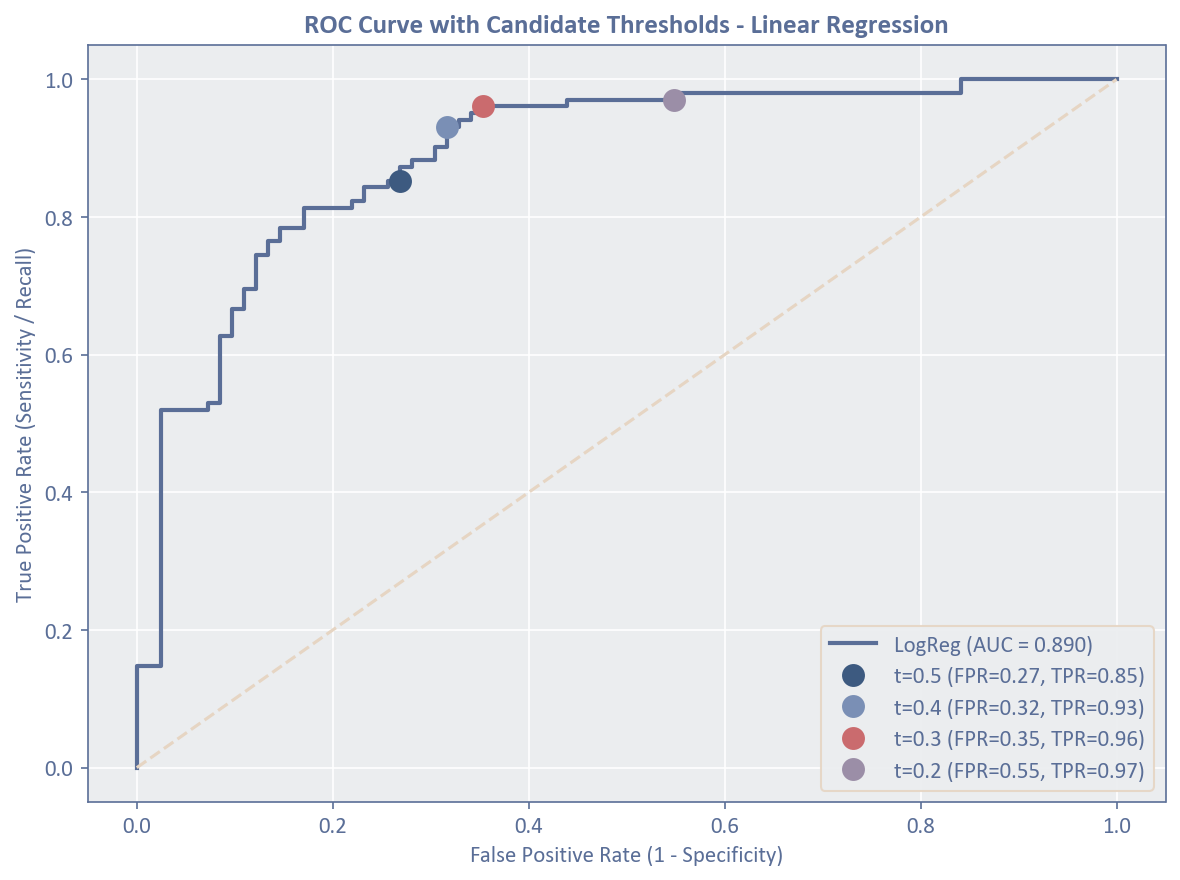

,threshold,precision,recall,f1,accuracy,specificity
0,0.5,0.805556,0.852941,0.828571,0.804348,0.743902
1,0.4,0.785124,0.931373,0.852018,0.820652,0.682927
2,0.3,0.759690,0.960784,0.848485,0.809783,0.621951
3,0.2,0.717391,0.970588,0.825000,0.771739,0.524390


In [41]:
# ROC curve with candidate thresholds marked
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr, tpr)

# Candidate thresholds to compare
candidate_thresholds = [0.5, 0.4, 0.3, 0.2]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color=CLR_BLUE, lw=2, label=f"LogReg (AUC = {roc_auc_val:.3f})")
ax.plot([0, 1], [0, 1], color=CLR_BEIGE, ls="--", lw=1.5)

# Mark candidate thresholds on the ROC curve
marker_colors = ["#3D5A80", "#7A8FB5", "#CA6B6E", "#9B8EA7"]
for thresh, color in zip(candidate_thresholds, marker_colors):
    idx = np.argmin(np.abs(thresholds - thresh))
    ax.plot(
        fpr[idx], tpr[idx], "o",
        color=color, markersize=10,
        label=f"t={thresh:.1f} (FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f})"
    )

ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity / Recall)")
ax.set_title("ROC Curve with Candidate Thresholds - Linear Regression")
ax.legend(loc="lower right")

fig.savefig(f"{FIGURES}/logreg_roc_curve.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

threshold_results = []

for thresh in candidate_thresholds:
    y_pred_thresh = (y_prob >= thresh).astype(int)

    threshold_results.append({
        "threshold": thresh,
        "precision": precision_score(y_test, y_pred_thresh),
        "recall": recall_score(y_test, y_pred_thresh),
        "f1": f1_score(y_test, y_pred_thresh),
        "accuracy": accuracy_score(y_test, y_pred_thresh),
        "specificity": confusion_matrix(y_test, y_pred_thresh)[0, 0] /
                       confusion_matrix(y_test, y_pred_thresh)[0].sum()
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

## 3.4 — Confusion Matrices at Different Thresholds

For each threshold, we visualise the confusion matrix. The critical cell is the **false negative (FN)** — a patient with disease predicted as "No Disease".

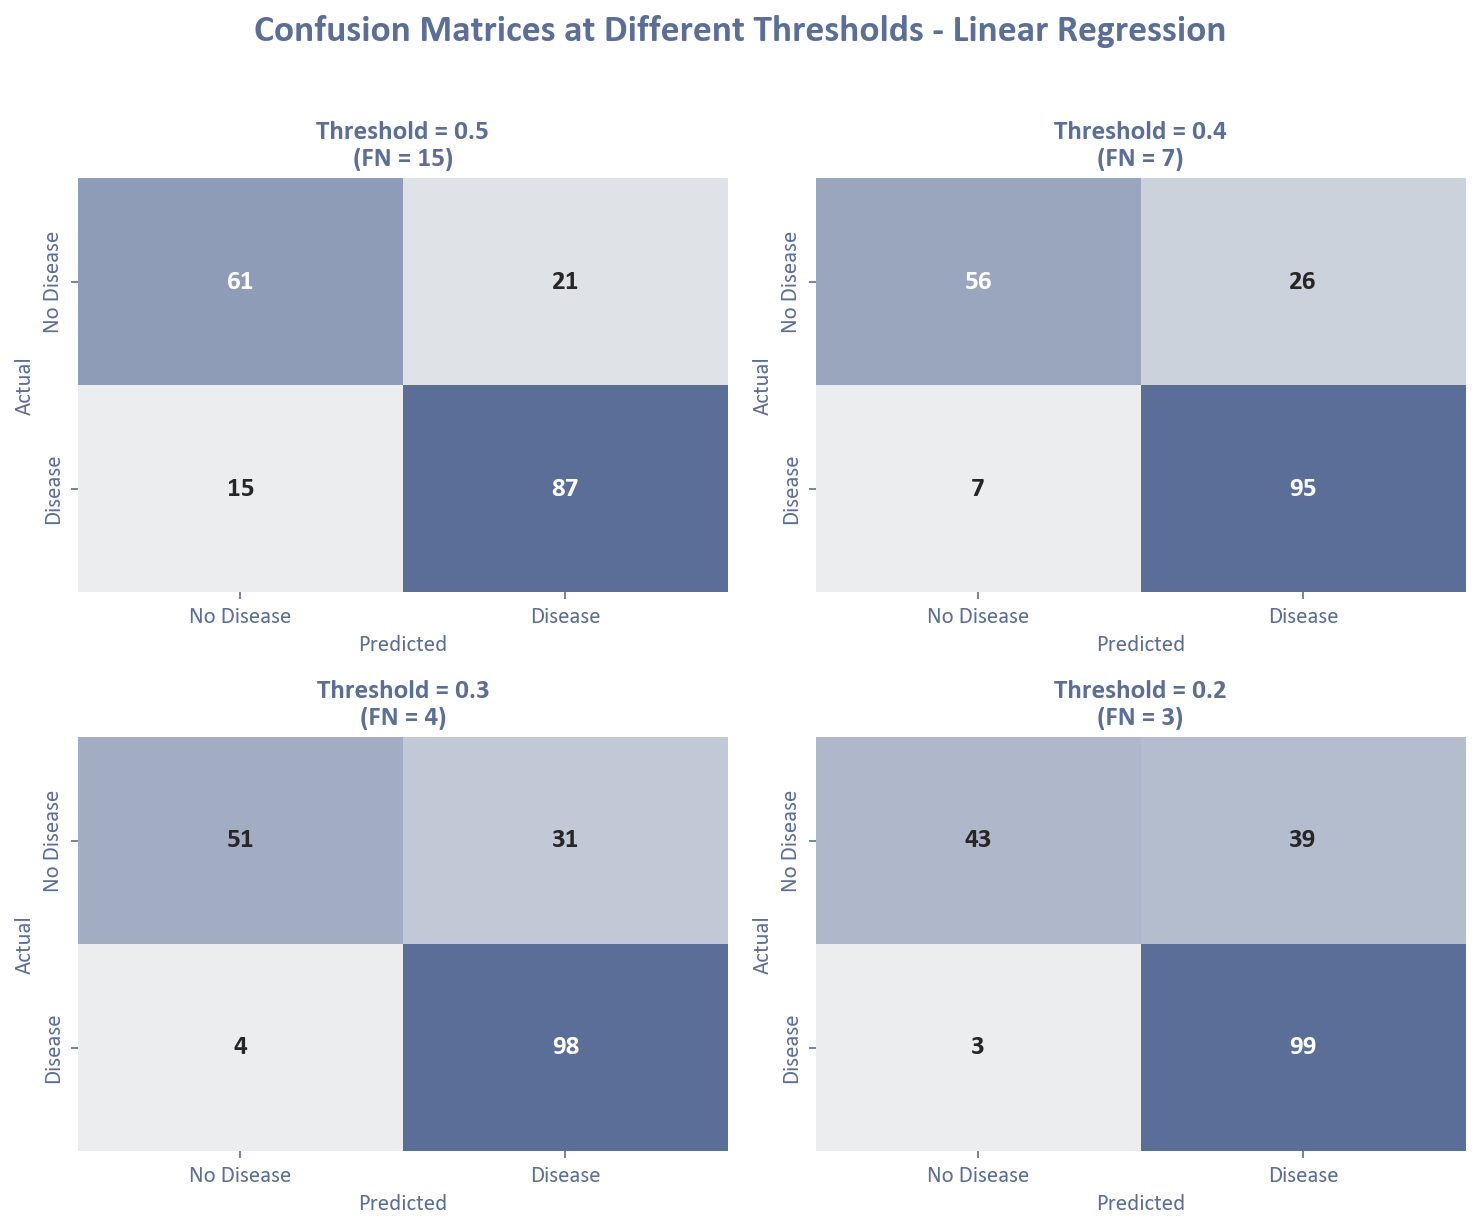

In [42]:
# Confusion matrices in 2x2 grid for all candidate thresholds
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, thresh in enumerate(candidate_thresholds):
    y_pred_t = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=CMAP_BLUE,
        xticklabels=["No Disease", "Disease"],
        yticklabels=["No Disease", "Disease"],
        ax=axes[i],
        cbar=False,
        annot_kws={"fontsize": 13, "fontweight": "bold"},
    )

    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
    axes[i].grid(False)

    fn = cm[1, 0]  # actual=Disease, predicted=No Disease
    axes[i].set_title(f"Threshold = {thresh}\n(FN = {fn})")

fig.suptitle("Confusion Matrices at Different Thresholds - Linear Regression", fontsize=18, y=1.02, fontweight="bold")
fig.savefig(f"{FIGURES}/logreg_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [43]:
# Detailed metrics comparison across thresholds
rows = []

for thresh in candidate_thresholds:
    y_pred_t = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()

    rows.append({
        "Threshold": thresh,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Accuracy": accuracy_score(y_test, y_pred_t),
        "Precision": precision_score(y_test, y_pred_t, zero_division=0),
        "Recall (Sensitivity)": recall_score(y_test, y_pred_t),
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "F1": f1_score(y_test, y_pred_t),
        "FN Rate": fn / (fn + tp) if (fn + tp) > 0 else 0,
    })

threshold_df = pd.DataFrame(rows)
threshold_df.to_csv(f"{TABLES}/logreg_threshold_comparison.csv", index=False)

print("Threshold comparison (FN = missed disease cases):\n")
threshold_df.round(4)


Threshold comparison (FN = missed disease cases):



,Threshold,TP,FP,FN,TN,Accuracy,Precision,Recall (Sensitivity),Specificity,F1,FN Rate
0,0.5,87,21,15,61,0.8043,0.8056,0.8529,0.7439,0.8286,0.1471
1,0.4,95,26,7,56,0.8207,0.7851,0.9314,0.6829,0.8520,0.0686
2,0.3,98,31,4,51,0.8098,0.7597,0.9608,0.6220,0.8485,0.0392
3,0.2,99,39,3,43,0.7717,0.7174,0.9706,0.5244,0.8250,0.0294


### Threshold Selection Rationale

The metrics illustrate the trade-off between false negatives and false positives:

- At **t = 0.5**: balanced performance (accuracy ~0.80, recall ~0.85), but **15 missed disease cases**.
- At **t = 0.4**: recall increases to ~0.93, reducing missed cases to 7.
- At **t = 0.3**: recall reaches ~0.96, with only **4 missed disease cases**. Specificity remains at ~0.62.
- At **t = 0.2**: marginal recall improvement (FN = 3), but specificity drops substantially.

**Selected threshold: 0.3** — it achieves high recall while maintaining acceptable specificity. For a screening tool, missing a disease case is far more critical than an unnecessary referral.

## 3.5 — Coefficient Interpretation & Top 5 Variables

Each logistic regression coefficient indicates how a predictor influences the log-odds of the outcome. An odds ratio > 1 increases disease probability; < 1 is protective. Coefficients correspond to standardised continuous variables and one-hot encoded categoricals.

In [44]:
# Extract trained components from pipeline
preprocessor_fitted = pipe.named_steps["preprocessor"]
classifier = pipe.named_steps["classifier"]

# Get transformed feature names
feature_names = preprocessor_fitted.get_feature_names_out()
feature_names = [f.split("__")[-1] for f in feature_names]

# Extract coefficients
coefficients = classifier.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df.head()


,feature,coefficient
0,age,0.292989
1,trestbps,-0.012430
2,chol,0.214378
3,thalach,-0.395584
4,oldpeak,0.476962


In [45]:
# Convert logistic regression coefficients to odds ratios and sort features by effect size
coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])

coef_df = coef_df.sort_values("odds_ratio", ascending=False).reset_index(drop=True)

print("Top predictors increasing disease risk:\n")
coef_df.head(10)


Top predictors increasing disease risk:



,feature,coefficient,odds_ratio
0,sex,1.303963,3.683866
1,thal_7.0,0.994730,2.703994
2,cp_4.0,0.890453,2.436233
3,exang,0.770049,2.159872
4,thal_6.0,0.487239,1.627816
5,oldpeak,0.476962,1.611172
6,restecg_1.0,0.328607,1.389032
7,age,0.292989,1.340429
8,slope_2.0,0.239118,1.270129
9,chol,0.214378,1.239091


In [46]:
# Show features with the lowest odds ratios (strongest protective effects)
print("Top predictors decreasing disease risk:\n")
coef_df.sort_values("odds_ratio").head(10)


Top predictors decreasing disease risk:



,feature,coefficient,odds_ratio
16,cp_2.0,-1.247090,0.287340
15,thalach,-0.395584,0.673287
14,cp_3.0,-0.309274,0.733979
13,restecg_2.0,-0.196312,0.821756
12,trestbps,-0.012430,0.987647
11,slope_3.0,0.000000,1.000000
10,fbs,0.201404,1.223119
9,chol,0.214378,1.239091
8,slope_2.0,0.239118,1.270129
7,age,0.292989,1.340429


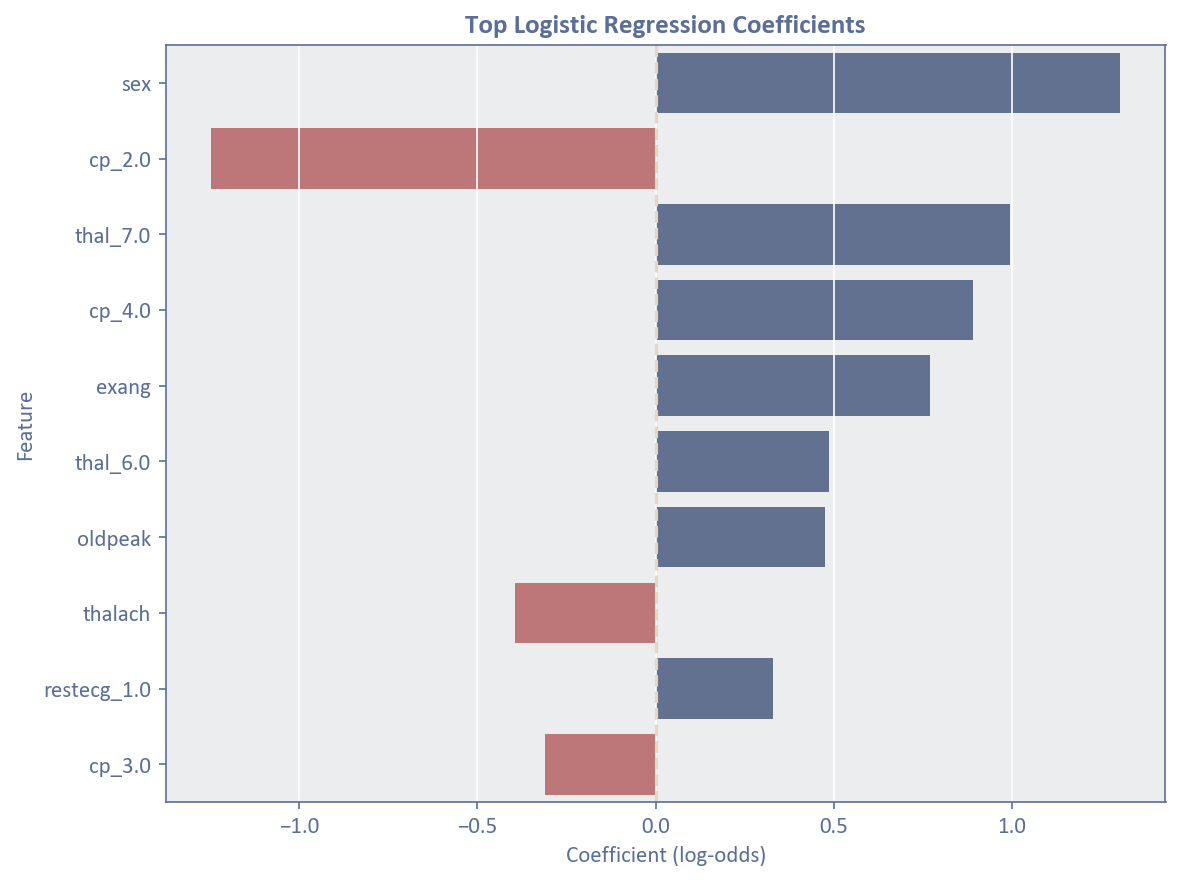

In [47]:
# Plot top coefficients
top = coef_df.reindex(coef_df.coefficient.abs().sort_values(ascending=False).index).head(10)

fig, ax = plt.subplots(figsize=(8, 6))
colors = [CLR_RED if v < 0 else CLR_BLUE for v in top["coefficient"]]
sns.barplot(
    data=top,
    y="feature",
    x="coefficient",
    palette=colors,
    ax=ax,
)

ax.axvline(0, color=CLR_BEIGE, linestyle="--", lw=1.5)
ax.set_title("Top Logistic Regression Coefficients")
ax.set_xlabel("Coefficient (log-odds)")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig(f"{FIGURES}/logreg_coefficients.png", dpi=150)
plt.show()

In [48]:
# Aggregate coefficients from one-hot encoded features back to their original variables
_MULTICLASS_ORIGINALS = ["cp", "restecg", "thal", "slope"]

original_importance = {}

for row in coef_df.itertuples():
    col = row.feature
    coef = abs(row.coefficient)

    original = col

    if col.startswith("source_"):
        original = "source_code"
    else:
        for name in _MULTICLASS_ORIGINALS:
            if col.startswith(name + "_"):
                original = name
                break

    if original not in original_importance:
        original_importance[original] = 0

    original_importance[original] += coef


importance_df = (
    pd.DataFrame(list(original_importance.items()), columns=["feature", "importance"])
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

importance_df["rank"] = range(1, len(importance_df)+1)

print("Feature ranking (aggregated |coefficients|):\n")
print(importance_df.to_string(index=False))

print("\n" + "=" * 50)
print("TOP 5 MOST INFLUENTIAL VARIABLES (Logistic Regression)")
print("=" * 50)
for _, row in importance_df.head(5).iterrows():
    print(f"  {int(row['rank'])}. {row['feature']:15s}  (importance = {row['importance']:.4f})")


Feature ranking (aggregated |coefficients|):

 feature  importance  rank
      cp    2.446818     1
    thal    1.481969     2
     sex    1.303963     3
   exang    0.770049     4
 restecg    0.524919     5
 oldpeak    0.476962     6
 thalach    0.395584     7
     age    0.292989     8
   slope    0.239118     9
    chol    0.214378    10
     fbs    0.201404    11
trestbps    0.012430    12

TOP 5 MOST INFLUENTIAL VARIABLES (Logistic Regression)
  1. cp               (importance = 2.4468)
  2. thal             (importance = 1.4820)
  3. sex              (importance = 1.3040)
  4. exang            (importance = 0.7700)
  5. restecg          (importance = 0.5249)


## 3.6 — Model Persistence & Summary

In [49]:
# Save model for reuse in Chapter 5
model_path = f"{MODELS}/logreg_model.joblib"
joblib.dump(pipe, model_path)

# Summary at selected threshold (t=0.3)
t = 0.3
y_pred_t = (y_prob >= t).astype(int)
cm = confusion_matrix(y_test, y_pred_t)
tn, fp, fn, tp = cm.ravel()

print("=" * 60)
print("LOGISTIC REGRESSION — FINAL RESULTS (all clinical features)")
print("=" * 60)
print(f"\nFeatures:         {X.shape[1]} (without source_code)")
print(f"CV ROC-AUC:       {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(f"Test ROC-AUC:     {test_auc:.4f}")
print(f"\nAt threshold t = {t}:")
print(f"  Sensitivity:    {recall_score(y_test, y_pred_t):.4f}")
print(f"  Precision:      {precision_score(y_test, y_pred_t):.4f}")
print(f"  Accuracy:       {accuracy_score(y_test, y_pred_t):.4f}")
print(f"  Specificity:    {tn / (tn + fp):.4f}")
print(f"  FN:             {fn}")
print(f"  FP:             {fp}")
print(f"\nTop 5 variables:")
for _, row in importance_df.head(5).iterrows():
    print(f"  {int(row['rank'])}. {row['feature']}")
print(f"\nModel saved to: {model_path}")

LOGISTIC REGRESSION — FINAL RESULTS (all clinical features)

Features:         12 (without source_code)
CV ROC-AUC:       0.8757 +/- 0.0248
Test ROC-AUC:     0.8895

At threshold t = 0.3:
  Sensitivity:    0.9608
  Precision:      0.7597
  Accuracy:       0.8098
  Specificity:    0.6220
  FN:             4
  FP:             31

Top 5 variables:
  1. cp
  2. thal
  3. sex
  4. exang
  5. restecg

Model saved to: results/models/logreg_model.joblib


# 4 — Gradient Boosting

This chapter implements a **gradient boosting classifier** as a benchmark model for heart disease prediction. It complements the logistic regression (Chapter 3) by testing whether a more flexible, non-linear model achieves meaningfully better performance.

The model uses all 12 clinical features (without `source_code`). Hyperparameters are fixed — the dataset is too small (920 rows) for extensive tuning.

## Focus: Minimising False Negatives

As with logistic regression, the worst outcome is a **false negative**. We analyse multiple thresholds to minimise missed disease cases.

## Hyperparameters (fixed)

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `n_estimators` | 100 | Sufficient for a small dataset |
| `learning_rate` | 0.05 | Conservative, reduces overfitting |
| `max_depth` | 2 | Shallow trees prevent overfitting |
| `min_samples_leaf` | 5 | Prevents overly specific leaf nodes |
| `subsample` | 0.8 | Stochastic gradient boosting, adds regularisation |

In [50]:
import sys, os, warnings
sys.path.append(os.path.abspath("."))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_score, recall_score, f1_score, accuracy_score,
    roc_auc_score,
)

from src.utils import (
    RANDOM_STATE, load_processed_data, get_feature_target_split,
    get_column_groups, build_preprocessor,
    plot_roc_curve, classification_report_df,
)

FIGURES = "results/figures"
TABLES  = "results/tables"
MODELS  = "results/models"

# ── Presentation-matched style ──────────────────────────────────────
CLR_BLUE  = "#5A6E97"   # slate blue
CLR_RED   = "#CA6B6E"   # muted rose  (GBM primary)
CLR_BEIGE = "#E6D5C3"   # warm beige
CLR_GRAY  = "#EBEDEF"   # light gray

CMAP_RED = mcolors.LinearSegmentedColormap.from_list(
    "pres_red", [CLR_GRAY, CLR_RED], N=256)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": CLR_GRAY,
    "axes.edgecolor": CLR_RED,
    "axes.labelcolor": CLR_RED,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.color": "white",
    "grid.linewidth": 0.8,
    "text.color": CLR_RED,
    "xtick.color": CLR_RED,
    "ytick.color": CLR_RED,
    "legend.framealpha": 0.9,
    "legend.edgecolor": CLR_BEIGE,
    "font.family": "sans-serif",
    "font.sans-serif": ["Calibri", "Arial", "DejaVu Sans"],
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
pd.set_option("display.max_columns", 20)
print("Setup complete.")

Setup complete.


## 4.1 — Data Loading & Preparation

In [51]:
df = load_processed_data()
print(f"Shape: {df.shape}")
print(f"NaN values: {df.isna().sum().sum()}")

print(f"\nTarget distribution:")
print(df["num"].value_counts().sort_index())

Shape: (920, 14)
NaN values: 0

Target distribution:
num
0    411
1    509
Name: count, dtype: int64


In [52]:
# All clinical features, without source_code
X, y = get_feature_target_split(df, drop_source=True, drop_high_missing=False)
groups = get_column_groups(X)
print(f"Features: {X.shape[1]}  "
      f"(cont={len(groups['continuous'])}, bin={len(groups['binary'])}, multi={len(groups['multiclass'])})")
print(f"Columns: {list(X.columns)}")

Features: 12  (cont=5, bin=3, multi=4)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'thal']


In [53]:
# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)} samples  (pos={y_train.sum()}, neg={len(y_train)-y_train.sum()})")
print(f"Test:  {len(X_test)} samples  (pos={y_test.sum()}, neg={len(y_test)-y_test.sum()})")


Train: 736 samples  (pos=407, neg=329)
Test:  184 samples  (pos=102, neg=82)


## 4.2 — Model Training & Cross-Validation

We build a pipeline (ColumnTransformer → GradientBoostingClassifier) with fixed hyperparameters.

- `subsample = 0.8` works *inside* training: each boosting round uses a random 80% of training rows (stochastic gradient boosting, reduces overfitting).
- Cross-validation works *outside* the model: it estimates generalisation performance across 5 stratified folds.

In [54]:
# Fixed hyperparameters
GBC_PARAMS = dict(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=RANDOM_STATE,
)

# Build pipeline
preprocessor = build_preprocessor(groups)
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(**GBC_PARAMS)),
])

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per fold:   {np.round(cv_scores, 4)}")

# Fit on full training set
pipe.fit(X_train, y_train)

# Predict probabilities on test set
y_prob = pipe.predict_proba(X_test)[:, 1]
y_pred_default = (y_prob >= 0.5).astype(int)

test_auc = roc_auc_score(y_test, y_prob)
print(f"\nTest ROC-AUC:  {test_auc:.4f}")
print(f"\nClassification report (default threshold = 0.5):")
print(classification_report(y_test, y_pred_default, target_names=["No Disease", "Disease"]))


CV ROC-AUC: 0.8742 ± 0.0253
Per fold:   [0.8519 0.8454 0.9042 0.8651 0.9042]

Test ROC-AUC:  0.9093

Classification report (default threshold = 0.5):
              precision    recall  f1-score   support

  No Disease       0.83      0.76      0.79        82
     Disease       0.82      0.87      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.81      0.82       184
weighted avg       0.82      0.82      0.82       184



## 4.3 — Threshold Optimisation

The default threshold of 0.5 is not optimal for a medical screening tool. We examine the ROC curve to identify thresholds that maximise recall while keeping specificity reasonable.

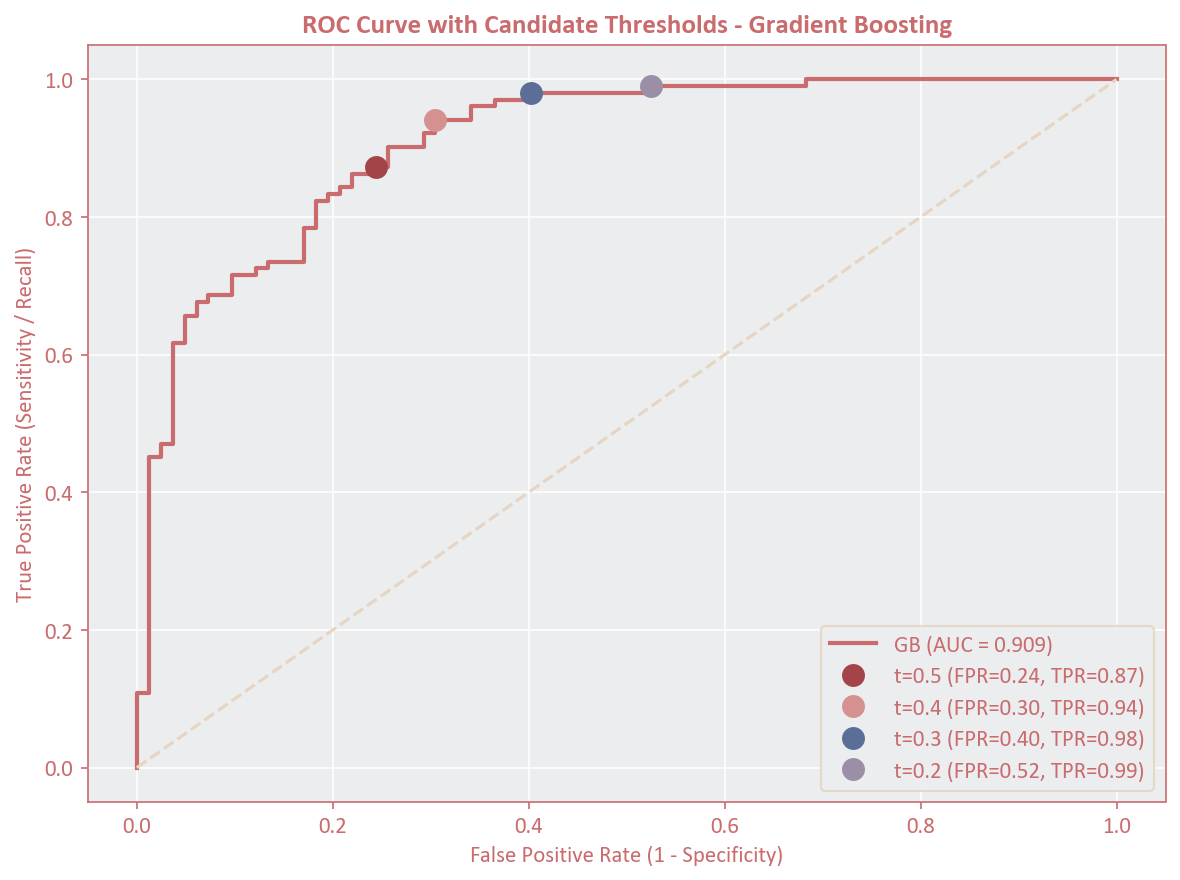

In [55]:
# ROC Curve with candidate thresholds marked
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr, tpr)

# Candidate thresholds to compare
candidate_thresholds = [0.5, 0.4, 0.3, 0.2]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color=CLR_RED, lw=2, label=f"GB (AUC = {roc_auc_val:.3f})")
ax.plot([0, 1], [0, 1], color=CLR_BEIGE, ls="--", lw=1.5)

# Mark candidate thresholds on the ROC curve
marker_colors = ["#A34548", "#D4918F", "#5A6E97", "#9B8EA7"]
for thresh, color in zip(candidate_thresholds, marker_colors):
    # Find the closest threshold in the ROC curve
    idx = np.argmin(np.abs(thresholds - thresh))
    ax.plot(fpr[idx], tpr[idx], "o", color=color, markersize=10,
            label=f"t={thresh:.1f} (FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f})")

ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity / Recall)")
ax.set_title("ROC Curve with Candidate Thresholds - Gradient Boosting")
ax.legend(loc="lower right")
fig.savefig(f"{FIGURES}/gb_roc_curve.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

## 4.4 — Confusion Matrices at Different Thresholds

For each threshold, we show the confusion matrix. The critical cell is the **false negative (FN)** — actual disease predicted as no disease.

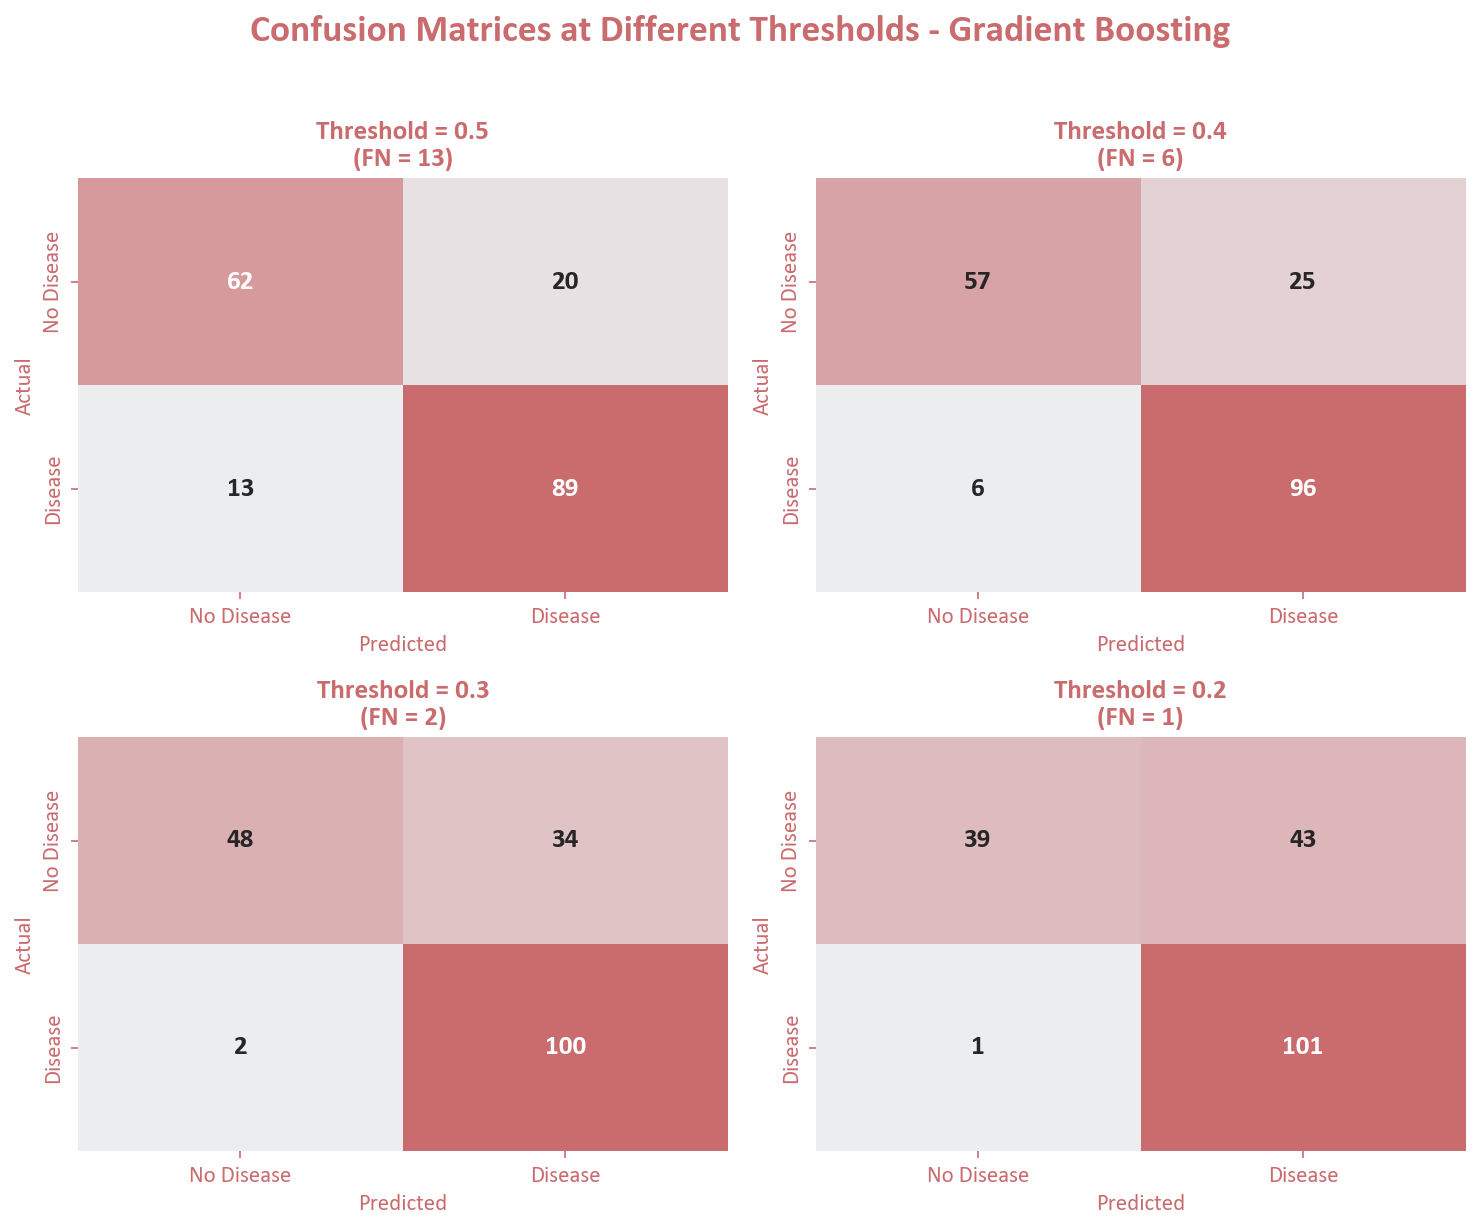

In [56]:
# Confusion matrices in 2x2 grid for all candidate thresholds
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, thresh in enumerate(candidate_thresholds):
    y_pred_t = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    
    sns.heatmap(cm, annot=True, fmt="d", cmap=CMAP_RED,
                xticklabels=["No Disease", "Disease"],
                yticklabels=["No Disease", "Disease"],
                ax=axes[i], cbar=False,
                annot_kws={"fontsize": 13, "fontweight": "bold"})
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
    axes[i].grid(False)
    
    fn = cm[1, 0]  # actual=Disease, predicted=No Disease
    axes[i].set_title(f"Threshold = {thresh}\n(FN = {fn})")

fig.suptitle("Confusion Matrices at Different Thresholds - Gradient Boosting", fontsize=18, y=1.02, fontweight="bold")
fig.savefig(f"{FIGURES}/gb_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [57]:
# Detailed metrics comparison across thresholds
rows = []
for thresh in candidate_thresholds:
    y_pred_t = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    
    rows.append({
        "Threshold": thresh,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "Accuracy": accuracy_score(y_test, y_pred_t),
        "Precision": precision_score(y_test, y_pred_t, zero_division=0),
        "Recall (Sensitivity)": recall_score(y_test, y_pred_t),
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "F1": f1_score(y_test, y_pred_t),
        "FN Rate": fn / (fn + tp) if (fn + tp) > 0 else 0,
    })

threshold_df = pd.DataFrame(rows)
threshold_df.to_csv(f"{TABLES}/gb_threshold_comparison.csv", index=False)

print("Threshold comparison (FN = missed disease cases):\n")
threshold_df.round(4)


Threshold comparison (FN = missed disease cases):



,Threshold,TP,FP,FN,TN,Accuracy,Precision,Recall (Sensitivity),Specificity,F1,FN Rate
0,0.5,89,20,13,62,0.8207,0.8165,0.8725,0.7561,0.8436,0.1275
1,0.4,96,25,6,57,0.8315,0.7934,0.9412,0.6951,0.8610,0.0588
2,0.3,100,34,2,48,0.8043,0.7463,0.9804,0.5854,0.8475,0.0196
3,0.2,101,43,1,39,0.7609,0.7014,0.9902,0.4756,0.8211,0.0098


### Threshold Selection Rationale

As with logistic regression, we select **t = 0.3** — it achieves high recall while keeping specificity above ~59%. The trade-off is clear: the cost of a missed disease (FN) far exceeds the cost of an unnecessary referral (FP).

## 4.5 — SHAP Analysis (Top 5 Variables)

SHAP (SHapley Additive exPlanations) computes exact feature contributions for tree-based models. We use SHAP to determine the **5 most influential variables** for the gradient boosting model. One-hot encoded features are aggregated back to their original variable names.

In [58]:
# Extract preprocessor and classifier from pipeline
preprocessor_fitted = pipe.named_steps["preprocessor"]
classifier = pipe.named_steps["classifier"]

# Transform data through preprocessor only
X_train_transformed = preprocessor_fitted.transform(X_train)
X_test_transformed = preprocessor_fitted.transform(X_test)

# Get clean feature names
feature_names = preprocessor_fitted.get_feature_names_out()
feature_names = [f.split("__")[-1] for f in feature_names]

print(f"Transformed features ({len(feature_names)}):")
print(feature_names)

# Compute SHAP values
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_test_transformed)
shap_df = pd.DataFrame(shap_values, columns=feature_names)
print(f"\nSHAP values shape: {shap_df.shape}")

Transformed features (17):
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'fbs', 'exang', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_1.0', 'restecg_2.0', 'thal_6.0', 'thal_7.0', 'slope_2.0', 'slope_3.0']

SHAP values shape: (184, 17)


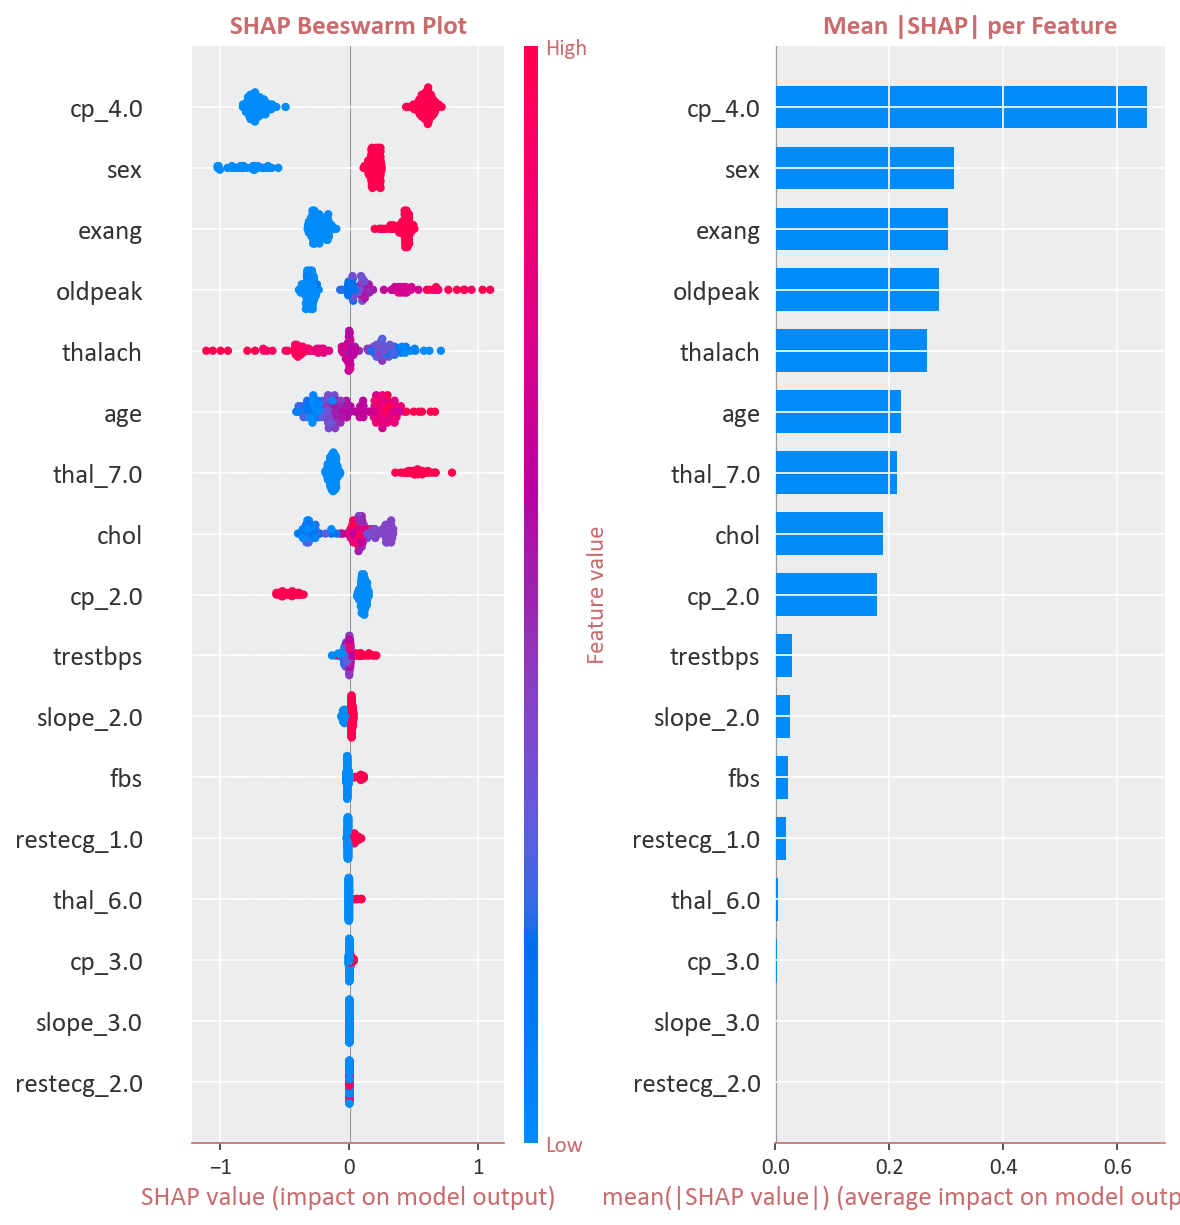

In [59]:
# SHAP Summary plot (beeswarm) and Bar plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
axes[0].set_title("SHAP Beeswarm Plot")

plt.sca(axes[1])
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names,
                  plot_type="bar", show=False)
axes[1].set_title("Mean |SHAP| per Feature")

plt.tight_layout()
fig.savefig(f"{FIGURES}/gb_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()


In [60]:
# Aggregate one-hot SHAP values back to original feature names
_MULTICLASS_ORIGINALS = ["cp", "restecg", "thal", "slope"]

original_importance = {}
for col in feature_names:
    original = col
    for name in _MULTICLASS_ORIGINALS:
        if col.startswith(name + "_"):
            original = name
            break
    if original not in original_importance:
        original_importance[original] = 0.0
    original_importance[original] += np.abs(shap_df[col]).mean()

importance_df = (
    pd.DataFrame(list(original_importance.items()), columns=["feature", "mean_abs_shap"])
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
importance_df["rank"] = range(1, len(importance_df) + 1)
importance_df.to_csv(f"{TABLES}/gb_shap_importance.csv", index=False)

print("Feature importance (aggregated to original variables):\n")
print(importance_df.to_string(index=False))

print("\n" + "=" * 50)
print("TOP 5 MOST INFLUENTIAL VARIABLES (Gradient Boosting / SHAP)")
print("=" * 50)
for _, row in importance_df.head(5).iterrows():
    print(f"  {int(row['rank'])}. {row['feature']:15s}  (mean |SHAP| = {row['mean_abs_shap']:.4f})")

Feature importance (aggregated to original variables):

 feature  mean_abs_shap  rank
      cp       0.833293     1
     sex       0.312978     2
   exang       0.303770     3
 oldpeak       0.287833     4
 thalach       0.266071     5
     age       0.220155     6
    thal       0.218889     7
    chol       0.188320     8
trestbps       0.028825     9
   slope       0.025624    10
     fbs       0.022317    11
 restecg       0.019763    12

TOP 5 MOST INFLUENTIAL VARIABLES (Gradient Boosting / SHAP)
  1. cp               (mean |SHAP| = 0.8333)
  2. sex              (mean |SHAP| = 0.3130)
  3. exang            (mean |SHAP| = 0.3038)
  4. oldpeak          (mean |SHAP| = 0.2878)
  5. thalach          (mean |SHAP| = 0.2661)


## 4.6 — Model Persistence & Summary

In [61]:
# Save model for reuse in Chapter 5
model_path = f"{MODELS}/gb_best_model.joblib"
joblib.dump(pipe, model_path)

# Summary at selected threshold (t=0.3)
t = 0.3
y_pred_t = (y_prob >= t).astype(int)
cm = confusion_matrix(y_test, y_pred_t)
tn, fp, fn, tp = cm.ravel()

print("=" * 60)
print("GRADIENT BOOSTING — FINAL RESULTS (all clinical features)")
print("=" * 60)
print(f"\nFeatures:         {X.shape[1]} (without source_code)")
print(f"CV ROC-AUC:       {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(f"Test ROC-AUC:     {test_auc:.4f}")
print(f"\nAt threshold t = {t}:")
print(f"  Sensitivity:    {recall_score(y_test, y_pred_t):.4f}")
print(f"  Precision:      {precision_score(y_test, y_pred_t):.4f}")
print(f"  Accuracy:       {accuracy_score(y_test, y_pred_t):.4f}")
print(f"  Specificity:    {tn / (tn + fp):.4f}")
print(f"  FN:             {fn}")
print(f"  FP:             {fp}")
print(f"\nTop 5 variables (SHAP):")
for _, row in importance_df.head(5).iterrows():
    print(f"  {int(row['rank'])}. {row['feature']}")
print(f"\nModel saved to: {model_path}")

GRADIENT BOOSTING — FINAL RESULTS (all clinical features)

Features:         12 (without source_code)
CV ROC-AUC:       0.8742 +/- 0.0253
Test ROC-AUC:     0.9093

At threshold t = 0.3:
  Sensitivity:    0.9804
  Precision:      0.7463
  Accuracy:       0.8043
  Specificity:    0.5854
  FN:             2
  FP:             34

Top 5 variables (SHAP):
  1. cp
  2. sex
  3. exang
  4. oldpeak
  5. thalach

Model saved to: results/models/gb_best_model.joblib


# 5 — Model Comparison & Hypothesis Testing

This chapter compares the two modelling approaches from Chapters 3 and 4:

- **Logistic Regression (L1-regularized / LASSO)**: interpretable, coefficient-based
- **Gradient Boosting**: flexible, non-linear, SHAP-based interpretation

Both models were trained on all 12 clinical features (without `source_code`) and are loaded from their saved state — no retraining is performed here.

## Hypothesis

> *Can a classification model based on 5 variables reach a sensitivity (recall) of at least 99% (false-negative rate < 1%) with simultaneous precision of over 80%?*

To test this, we first compare both full models, then train reduced 5-variable versions using only the most influential predictors identified in Chapters 3 and 4.

In [62]:
import sys, os, warnings
sys.path.append(os.path.abspath("."))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_score, recall_score, f1_score, accuracy_score,
    roc_auc_score,
)

from src.utils import (
    RANDOM_STATE, load_processed_data, get_feature_target_split,
    get_column_groups, build_preprocessor,
)

FIGURES = "results/figures"
TABLES  = "results/tables"
MODELS  = "results/models"

# ── Presentation-matched style ──────────────────────────────────────
CLR_BLUE  = "#5A6E97"   # slate blue  (LogReg)
CLR_RED   = "#CA6B6E"   # muted rose  (GBM)
CLR_BEIGE = "#E6D5C3"   # warm beige
CLR_GRAY  = "#EBEDEF"   # light gray

CMAP_BLUE = mcolors.LinearSegmentedColormap.from_list(
    "pres_blue", [CLR_GRAY, CLR_BLUE], N=256)
CMAP_RED = mcolors.LinearSegmentedColormap.from_list(
    "pres_red", [CLR_GRAY, CLR_RED], N=256)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": CLR_GRAY,
    "axes.edgecolor": CLR_BLUE,
    "axes.labelcolor": CLR_BLUE,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.color": "white",
    "grid.linewidth": 0.8,
    "text.color": CLR_BLUE,
    "xtick.color": CLR_BLUE,
    "ytick.color": CLR_BLUE,
    "legend.framealpha": 0.9,
    "legend.edgecolor": CLR_BEIGE,
    "font.family": "sans-serif",
    "font.sans-serif": ["Calibri", "Arial", "DejaVu Sans"],
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
pd.set_option("display.max_columns", 20)
print("Setup complete.")

Setup complete.


## 5.1 — Load Trained Models

Both models were trained on all 12 clinical features (without `source_code`) in Chapters 3 and 4. We load the saved pipelines and recreate the same train/test split to generate predictions.

In [63]:
# Load data and recreate the same split (same RANDOM_STATE ensures identical split)
df = load_processed_data()
X, y = get_feature_target_split(df, drop_source=True, drop_high_missing=False)
groups = get_column_groups(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Features: {X.shape[1]}  (no source_code)")
print(f"Columns: {list(X.columns)}")
print(f"\nTrain: {len(X_train)}  |  Test: {len(X_test)}")
print(f"Disease prevalence - Train: {y_train.mean():.1%}  |  Test: {y_test.mean():.1%}")

Features: 12  (no source_code)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'thal']

Train: 736  |  Test: 184
Disease prevalence - Train: 55.3%  |  Test: 55.4%


In [64]:
# Load saved models from Chapters 3 and 4
pipe_lr = joblib.load(f"{MODELS}/logreg_model.joblib")
pipe_gb = joblib.load(f"{MODELS}/gb_best_model.joblib")

# Predict probabilities on test set
y_prob_lr = pipe_lr.predict_proba(X_test)[:, 1]
y_prob_gb = pipe_gb.predict_proba(X_test)[:, 1]

print("Models loaded successfully.")
print(f"  LogReg Test ROC-AUC:  {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"  GBM    Test ROC-AUC:  {roc_auc_score(y_test, y_prob_gb):.4f}")

Models loaded successfully.
  LogReg Test ROC-AUC:  0.8895
  GBM    Test ROC-AUC:  0.9093


## 5.2 — ROC Curve Comparison

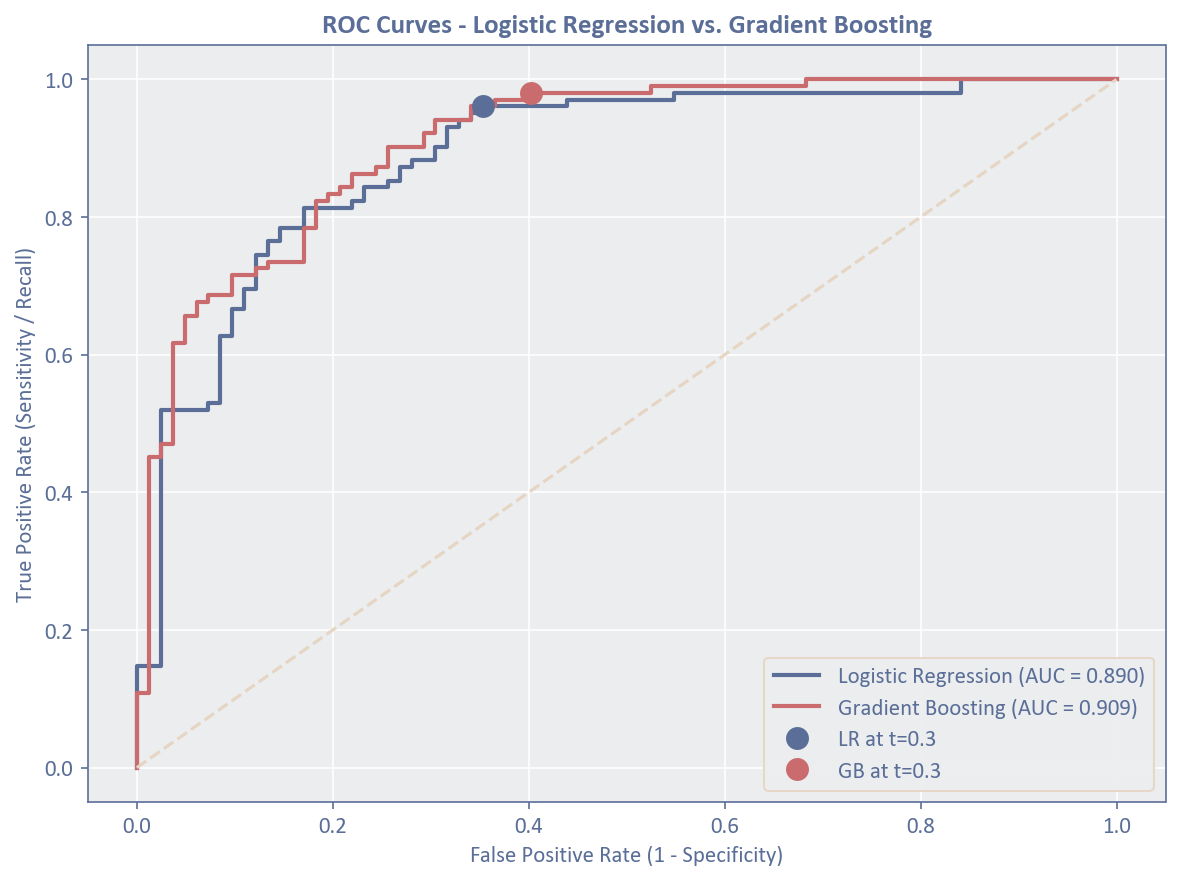

In [65]:
# ROC curves side by side
fpr_lr, tpr_lr, thresh_lr = roc_curve(y_test, y_prob_lr)
fpr_gb, tpr_gb, thresh_gb = roc_curve(y_test, y_prob_gb)
auc_lr = auc(fpr_lr, tpr_lr)
auc_gb = auc(fpr_gb, tpr_gb)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_lr, tpr_lr, color=CLR_BLUE, lw=2, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
ax.plot(fpr_gb, tpr_gb, color=CLR_RED, lw=2, label=f"Gradient Boosting (AUC = {auc_gb:.3f})")
ax.plot([0, 1], [0, 1], color=CLR_BEIGE, ls="--", lw=1.5)

# Mark threshold 0.3 on both curves
for fpr_arr, tpr_arr, thresh_arr, color, name in [
    (fpr_lr, tpr_lr, thresh_lr, CLR_BLUE, "LR"),
    (fpr_gb, tpr_gb, thresh_gb, CLR_RED, "GB"),
]:
    idx = np.argmin(np.abs(thresh_arr - 0.3))
    ax.plot(fpr_arr[idx], tpr_arr[idx], "o", color=color, markersize=10,
            label=f"{name} at t=0.3")

ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity / Recall)")
ax.set_title("ROC Curves - Logistic Regression vs. Gradient Boosting")
ax.legend(loc="lower right")
fig.savefig(f"{FIGURES}/comparison_roc_curves.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

## 5.3 — Threshold Comparison

Both models use t = 0.3 as the screening threshold. We compare detailed metrics across multiple thresholds.

In [66]:
# Compare both models across thresholds
candidate_thresholds = [0.5, 0.4, 0.3, 0.2]
rows = []

for name, y_prob in [("LogReg", y_prob_lr), ("GBM", y_prob_gb)]:
    for thresh in candidate_thresholds:
        y_pred_t = (y_prob >= thresh).astype(int)
        cm = confusion_matrix(y_test, y_pred_t)
        tn, fp, fn, tp = cm.ravel()
        rows.append({
            "Model": name,
            "Threshold": thresh,
            "TP": tp, "FP": fp, "FN": fn, "TN": tn,
            "Accuracy": accuracy_score(y_test, y_pred_t),
            "Precision": precision_score(y_test, y_pred_t, zero_division=0),
            "Recall": recall_score(y_test, y_pred_t),
            "Specificity": tn / (tn + fp),
            "F1": f1_score(y_test, y_pred_t),
        })

comparison_df = pd.DataFrame(rows)
comparison_df.to_csv(f"{TABLES}/comparison_threshold_metrics.csv", index=False)

print("Performance comparison WITHOUT source_code:\n")
comparison_df.round(4)

Performance comparison WITHOUT source_code:



,Model,Threshold,TP,FP,FN,TN,Accuracy,Precision,Recall,Specificity,F1
0,LogReg,0.5,87,21,15,61,0.8043,0.8056,0.8529,0.7439,0.8286
1,LogReg,0.4,95,26,7,56,0.8207,0.7851,0.9314,0.6829,0.8520
2,LogReg,0.3,98,31,4,51,0.8098,0.7597,0.9608,0.6220,0.8485
3,LogReg,0.2,99,39,3,43,0.7717,0.7174,0.9706,0.5244,0.8250
4,GBM,0.5,89,20,13,62,0.8207,0.8165,0.8725,0.7561,0.8436
5,GBM,0.4,96,25,6,57,0.8315,0.7934,0.9412,0.6951,0.8610
6,GBM,0.3,100,34,2,48,0.8043,0.7463,0.9804,0.5854,0.8475
7,GBM,0.2,101,43,1,39,0.7609,0.7014,0.9902,0.4756,0.8211


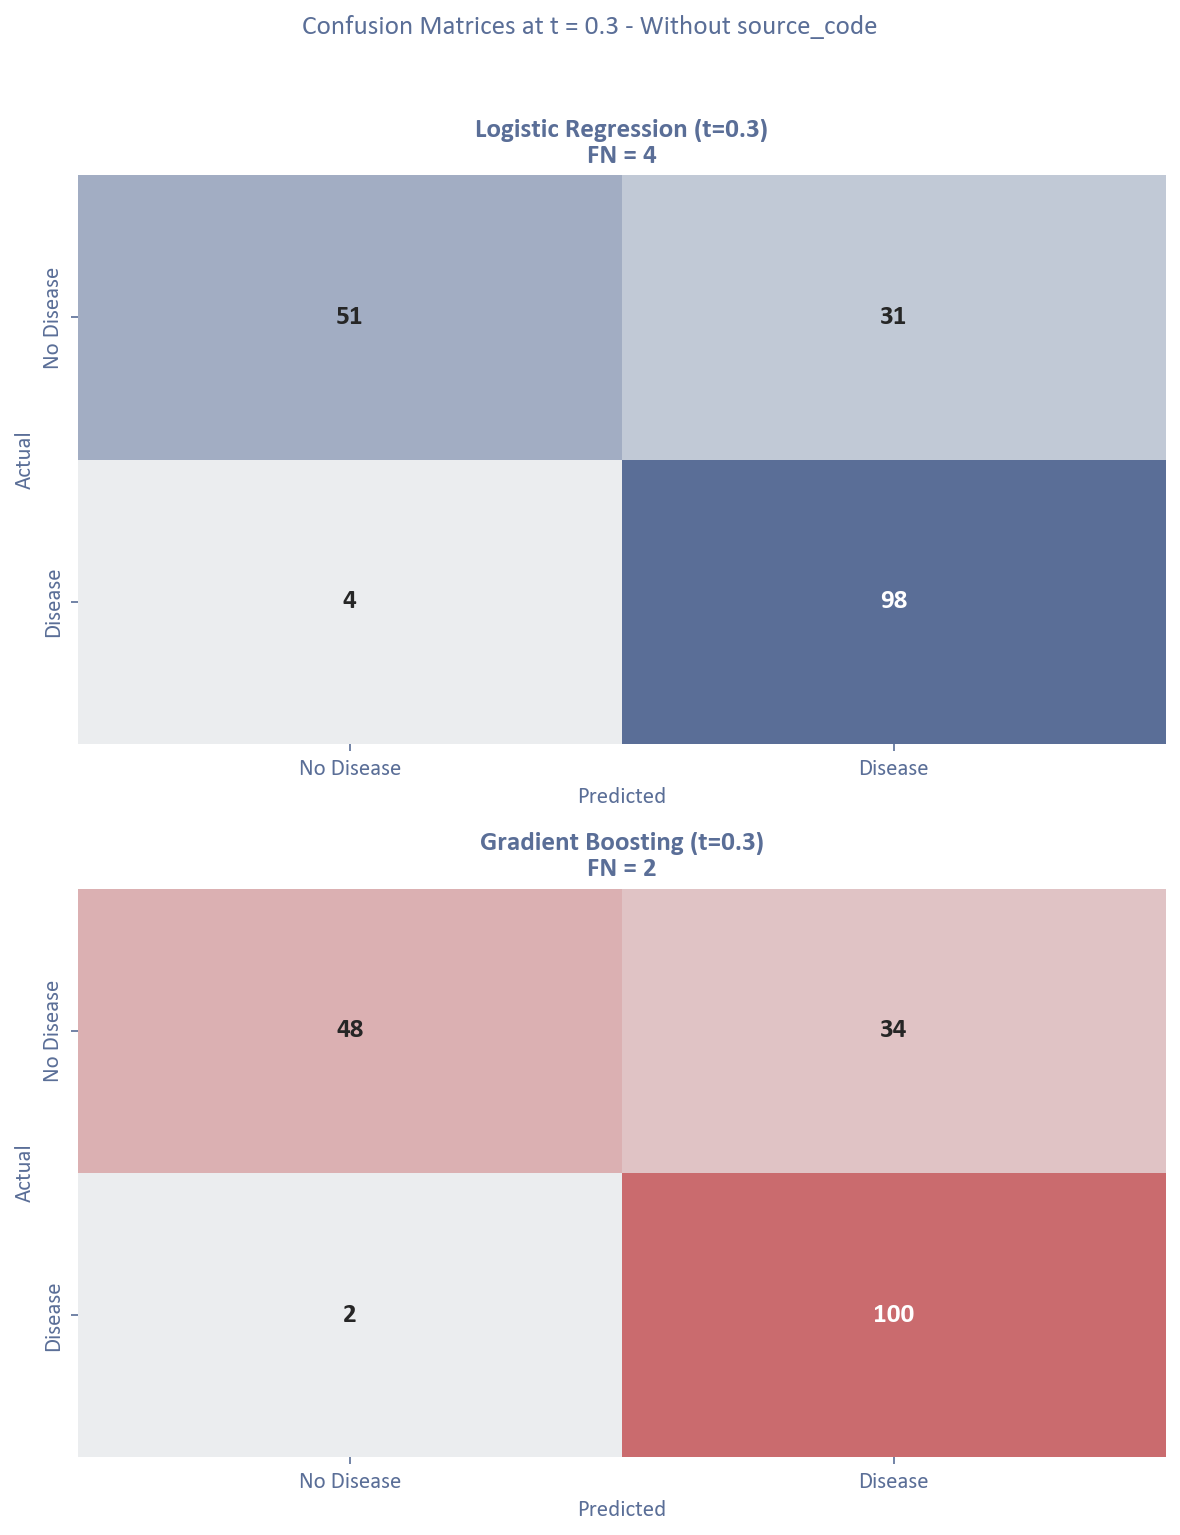

In [67]:
# Confusion matrices at t=0.3 side by side
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
thresh = 0.3

for i, (name, y_prob, cmap) in enumerate([
    ("Logistic Regression", y_prob_lr, CMAP_BLUE),
    ("Gradient Boosting", y_prob_gb, CMAP_RED),
]):
    y_pred_t = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    fn = cm[1, 0]

    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=["No Disease", "Disease"],
                yticklabels=["No Disease", "Disease"],
                ax=axes[i], cbar=False,
                annot_kws={"fontsize": 13, "fontweight": "bold"})
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
    axes[i].set_title(f"{name} (t=0.3)\nFN = {fn}")
    axes[i].grid(False)

fig.suptitle("Confusion Matrices at t = 0.3 - Without source_code", fontsize=13, y=1.02)
fig.savefig(f"{FIGURES}/comparison_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

## 5.4 — Feature Importance Comparison

We compare which features each model considers most important. For logistic regression: aggregated absolute coefficients. For gradient boosting: built-in feature importances (mean decrease in impurity).

Agreement between both models on the top features increases confidence that these carry genuine predictive signal.

In [68]:
# Extract feature importances from both models

_MULTICLASS_ORIGINALS = ["cp", "restecg", "thal", "slope"]

def aggregate_importance(feature_names, importances):
    """Aggregate one-hot encoded features back to original variable names."""
    original = {}
    for name, imp in zip(feature_names, importances):
        orig = name
        for mc in _MULTICLASS_ORIGINALS:
            if name.startswith(mc + "_"):
                orig = mc
                break
        original[orig] = original.get(orig, 0) + abs(imp)
    result = pd.DataFrame(list(original.items()), columns=["feature", "importance"])
    result = result.sort_values("importance", ascending=False).reset_index(drop=True)
    result["rank"] = range(1, len(result) + 1)
    return result

# Get transformed feature names (clean)
preprocessor_lr = pipe_lr.named_steps["preprocessor"]
feat_names = [f.split("__")[-1] for f in preprocessor_lr.get_feature_names_out()]

# LogReg: absolute coefficients
lr_coefs = pipe_lr.named_steps["classifier"].coef_[0]
imp_lr = aggregate_importance(feat_names, lr_coefs)
imp_lr.columns = ["feature", "lr_importance", "lr_rank"]

# GBM: built-in feature importance
preprocessor_gb = pipe_gb.named_steps["preprocessor"]
feat_names_gb = [f.split("__")[-1] for f in preprocessor_gb.get_feature_names_out()]
gb_imp = pipe_gb.named_steps["classifier"].feature_importances_
imp_gb = aggregate_importance(feat_names_gb, gb_imp)
imp_gb.columns = ["feature", "gb_importance", "gb_rank"]

# Merge
rank_comparison = imp_lr.merge(imp_gb, on="feature", how="outer")
rank_comparison = rank_comparison.sort_values("lr_rank").reset_index(drop=True)
rank_comparison.to_csv(f"{TABLES}/comparison_feature_ranking.csv", index=False)

print("Feature ranking comparison (without source_code):\n")
rank_comparison

Feature ranking comparison (without source_code):



,feature,lr_importance,lr_rank,gb_importance,gb_rank
0,cp,2.446818,1,0.426989,1
1,thal,1.481969,2,0.046715,7
2,sex,1.303963,3,0.089151,5
3,exang,0.770049,4,0.103186,2
4,restecg,0.524919,5,0.003080,12
5,oldpeak,0.476962,6,0.091271,3
6,thalach,0.395584,7,0.090238,4
7,age,0.292989,8,0.083492,6
8,slope,0.239118,9,0.003206,11
9,chol,0.214378,10,0.046247,8


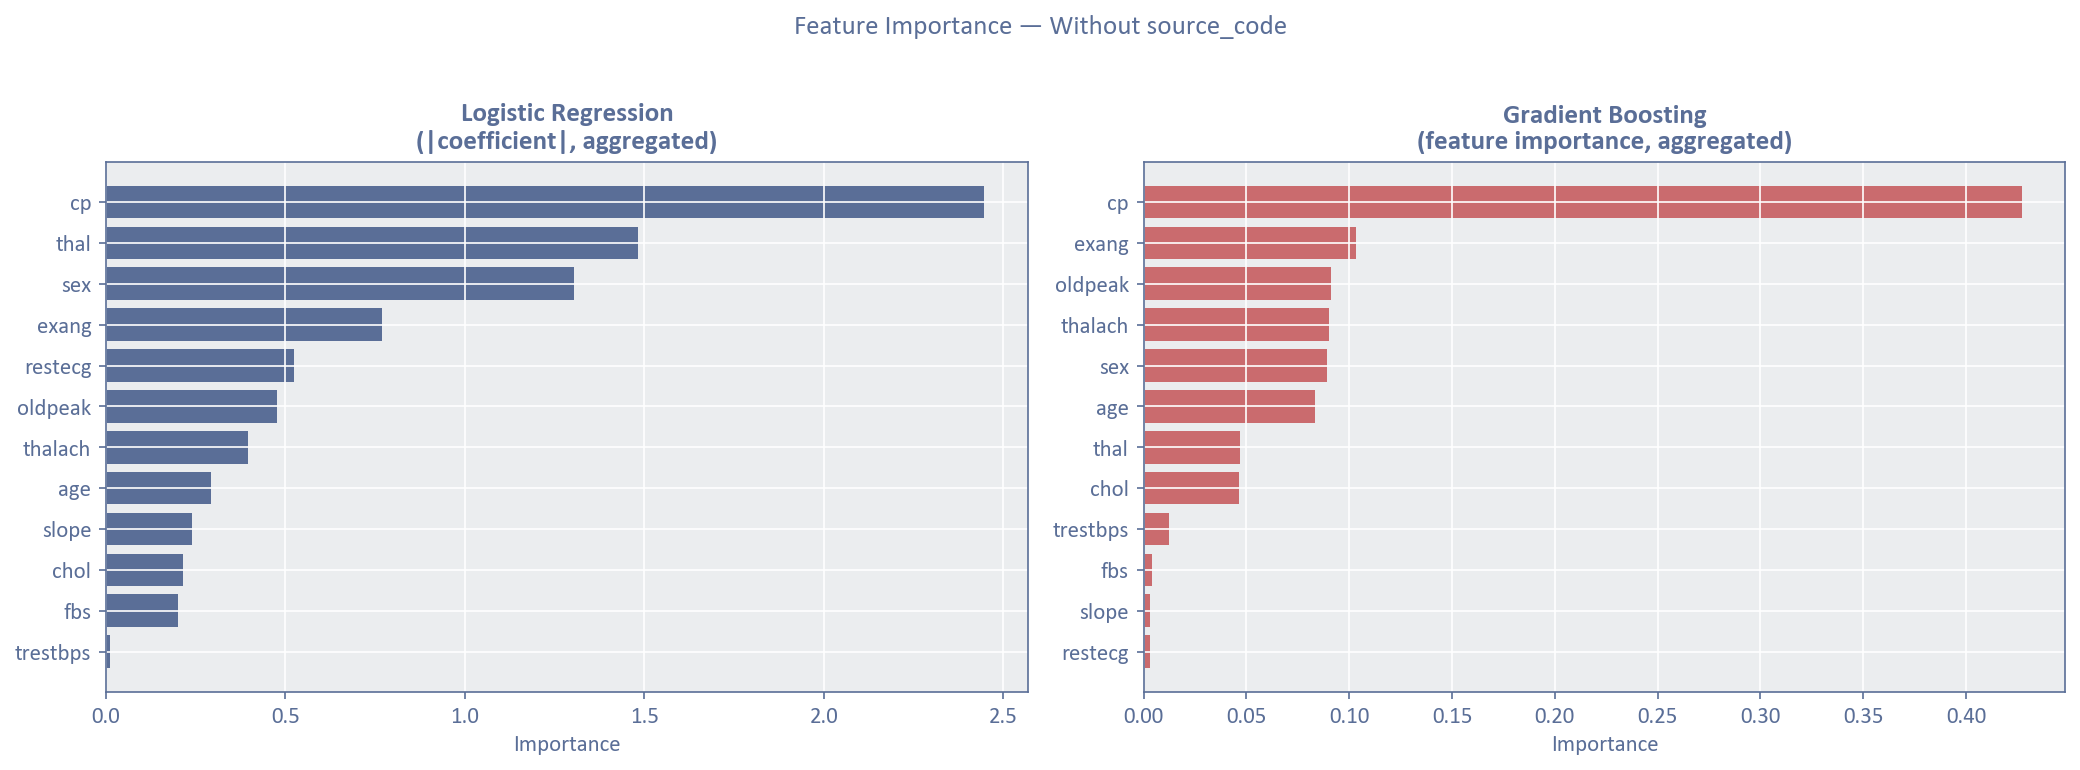

In [69]:
# Visual comparison of feature rankings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LogReg
lr_sorted = rank_comparison.sort_values("lr_importance", ascending=True)
axes[0].barh(lr_sorted["feature"], lr_sorted["lr_importance"], color=CLR_BLUE)
axes[0].set_title("Logistic Regression\n(|coefficient|, aggregated)")
axes[0].set_xlabel("Importance")

# GBM
gb_sorted = rank_comparison.sort_values("gb_importance", ascending=True)
axes[1].barh(gb_sorted["feature"], gb_sorted["gb_importance"], color=CLR_RED)
axes[1].set_title("Gradient Boosting\n(feature importance, aggregated)")
axes[1].set_xlabel("Importance")

fig.suptitle("Feature Importance \u2014 Without source_code", fontsize=13, y=1.02)
fig.savefig(f"{FIGURES}/comparison_feature_importance.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

## 5.5 — Top 5 Variables & Why the Models Disagree

Both models rank **cp** (chest pain type) as the single most important predictor. Beyond that, they diverge:

| Rank | Logistic Regression | Gradient Boosting |
|------|---------------------|-------------------|
| 1 | cp | cp |
| 2 | thal | exang |
| 3 | sex | oldpeak |
| 4 | exang | thalach |
| 5 | restecg | sex |

**Why the difference?** Logistic regression measures each feature's *linear* contribution to the log-odds. It can capture strong categorical separations (e.g. `thal = reversible defect` vs. `thal = normal`) efficiently through one-hot encoding. Gradient boosting, by contrast, builds decision trees that split on continuous thresholds — it naturally favours continuous variables (`oldpeak`, `thalach`) where it can find optimal cut points. Additionally, gradient boosting captures non-linear interactions between variables, so a feature that is individually weak (like `thalach`) may still rank high because it interacts with other splits in the tree ensemble.

Since we recommend **logistic regression** as the final model (interpretable, coefficient-based), we use its top 5 variables for the hypothesis test: **cp, thal, sex, exang, restecg**.

In [70]:
# Show top 5 from each model
print("TOP 5 — LOGISTIC REGRESSION (|coefficient|, aggregated)")
print("=" * 55)
for _, row in imp_lr.head(5).iterrows():
    print(f"  {int(row['lr_rank'])}. {row['feature']:15s}  ({row['lr_importance']:.4f})")

print(f"\nTOP 5 — GRADIENT BOOSTING (feature importance, aggregated)")
print("=" * 55)
for _, row in imp_gb.head(5).iterrows():
    print(f"  {int(row['gb_rank'])}. {row['feature']:15s}  ({row['gb_importance']:.4f})")

print("\n--> For the 5-variable hypothesis test we use the")
print("    logistic regression top 5: cp, thal, sex, exang, restecg")

TOP 5 — LOGISTIC REGRESSION (|coefficient|, aggregated)
  1. cp               (2.4468)
  2. thal             (1.4820)
  3. sex              (1.3040)
  4. exang            (0.7700)
  5. restecg          (0.5249)

TOP 5 — GRADIENT BOOSTING (feature importance, aggregated)
  1. cp               (0.4270)
  2. exang            (0.1032)
  3. oldpeak          (0.0913)
  4. thalach          (0.0902)
  5. sex              (0.0892)

--> For the 5-variable hypothesis test we use the
    logistic regression top 5: cp, thal, sex, exang, restecg


## 5.6 — Summary Table (Full Models, 12 Features)

In [71]:
# Final summary table — full models (12 features)
auc_lr_test = roc_auc_score(y_test, y_prob_lr)
auc_gb_test = roc_auc_score(y_test, y_prob_gb)

def metrics_at_threshold(y_true, y_prob, t):
    y_pred = (y_prob >= t).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "Sensitivity": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Specificity": tn / (tn + fp),
        "FN": fn,
        "FP": fp,
        "F1": f1_score(y_true, y_pred),
    }

m_lr = metrics_at_threshold(y_test, y_prob_lr, 0.3)
m_gb = metrics_at_threshold(y_test, y_prob_gb, 0.3)

summary = pd.DataFrame({
    "Metric": [
        "Test ROC-AUC",
        "Sensitivity (t=0.3)", "Precision (t=0.3)", "Accuracy (t=0.3)",
        "Specificity (t=0.3)",
        "False Negatives (t=0.3)", "False Positives (t=0.3)",
        "F1 (t=0.3)",
        "Interpretable?", "Recommended?"
    ],
    "Logistic Regression": [
        f"{auc_lr_test:.4f}",
        f"{m_lr['Sensitivity']:.4f}", f"{m_lr['Precision']:.4f}", f"{m_lr['Accuracy']:.4f}",
        f"{m_lr['Specificity']:.4f}",
        m_lr["FN"], m_lr["FP"],
        f"{m_lr['F1']:.4f}",
        "Yes", "Yes"
    ],
    "Gradient Boosting": [
        f"{auc_gb_test:.4f}",
        f"{m_gb['Sensitivity']:.4f}", f"{m_gb['Precision']:.4f}", f"{m_gb['Accuracy']:.4f}",
        f"{m_gb['Specificity']:.4f}",
        m_gb["FN"], m_gb["FP"],
        f"{m_gb['F1']:.4f}",
        "No (black box)", "No"
    ],
})

summary.to_csv(f"{TABLES}/comparison_summary.csv", index=False)
print("Full Model Comparison (12 clinical features, without source_code):\n")
summary

Full Model Comparison (12 clinical features, without source_code):



,Metric,Logistic Regression,Gradient Boosting
0,Test ROC-AUC,0.8895,0.9093
1,Sensitivity (t=0.3),0.9608,0.9804
2,Precision (t=0.3),0.7597,0.7463
3,Accuracy (t=0.3),0.8098,0.8043
4,Specificity (t=0.3),0.6220,0.5854
5,False Negatives (t=0.3),4,2
6,False Positives (t=0.3),31,34
7,F1 (t=0.3),0.8485,0.8475
8,Interpretable?,Yes,No (black box)
9,Recommended?,Yes,No


## 5.7 — Hypothesis Test: 5-Variable Logistic Regression

> **Hypothesis:** *Can a classification model based on 5 variables reach sensitivity >= 99% (FNR < 1%) with simultaneous precision > 80%?*

We train a logistic regression on the 5 most influential variables identified in Chapter 3:

| Variable | Type | Meaning |
|----------|------|---------|
| **cp** | categorical (4 levels) | chest pain type (1=typical, 2=atypical, 3=non-anginal, 4=asymptomatic) |
| **thal** | categorical (3 levels) | thallium stress test result (3=normal, 6=fixed defect, 7=reversible defect) |
| **sex** | binary | 0=female, 1=male |
| **exang** | binary | exercise-induced angina (0=no, 1=yes) |
| **restecg** | binary/categorical | resting ECG (0=normal, 1=ST-T abnormality, 2=LV hypertrophy) |

The multi-class variables (cp, thal, restecg) are one-hot encoded with `drop_first=True`, resulting in 9 model inputs from 5 clinical measurements. Continuous standardisation is not applied — all variables are already on interpretable scales.

### How the screening score works

The doctor records 5 clinical values. The model computes:

**z = b₀ + b₁·sex + b₂·exang + b₃·cp₂ + b₄·cp₃ + b₅·cp₄ + b₆·thal₆ + b₇·thal₇ + b₈·restecg₁ + b₉·restecg₂**

**score = 1 / (1 + e⁻ᶻ)**

If `score > threshold` → refer patient to cardiologist.

In [72]:
# Prepare 5-variable dataset using LogReg top 5
FIVE_VARS = ["cp", "thal", "sex", "exang", "restecg"]
X_5_raw = df[FIVE_VARS].copy()
y_5 = df["num"]

# One-hot encode multi-class variables, keep binary as-is
X_5 = pd.get_dummies(X_5_raw, columns=["cp", "thal", "restecg"], drop_first=True, dtype=int)

print(f"5 clinical variables → {X_5.shape[1]} model inputs after encoding:")
print(f"  {list(X_5.columns)}")

X_train_5, X_test_5, y_train_5, y_test_5 = train_test_split(
    X_5, y_5, test_size=0.2, stratify=y_5, random_state=RANDOM_STATE
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Logistic regression on 5 variables (no standardisation)
lr_5 = LogisticRegression(
    penalty="l1", solver="liblinear", max_iter=1000, random_state=RANDOM_STATE
)
lr_5.fit(X_train_5, y_train_5)
cv_lr_5 = cross_val_score(lr_5, X_train_5, y_train_5, cv=cv, scoring="roc_auc")
y_prob_5 = lr_5.predict_proba(X_test_5)[:, 1]

print(f"\n5-Variable Logistic Regression:")
print(f"  CV ROC-AUC:   {cv_lr_5.mean():.4f} +/- {cv_lr_5.std():.4f}")
print(f"  Test ROC-AUC: {roc_auc_score(y_test_5, y_prob_5):.4f}")

5 clinical variables → 9 model inputs after encoding:
  ['sex', 'exang', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'thal_6.0', 'thal_7.0', 'restecg_1.0', 'restecg_2.0']

5-Variable Logistic Regression:
  CV ROC-AUC:   0.8556 +/- 0.0172
  Test ROC-AUC: 0.8625


In [73]:
# === THE SCREENING FORMULA ===
b = lr_5.coef_[0]
b0 = lr_5.intercept_[0]

print("SCREENING FORMULA (5-Variable Logistic Regression)")
print("=" * 55)
print(f"\n  z = {b0:+.4f}  (intercept)")
for name, coef in zip(X_5.columns, b):
    print(f"      {coef:+.4f} * {name}")
print(f"\n  score = 1 / (1 + exp(-z))")
print(f"\n  If score > 0.3  -->  REFER to cardiologist")

# === HYPOTHESIS EVALUATION ===
print(f"\n\n{'='*55}")
print("HYPOTHESIS EVALUATION")
print(f"{'='*55}")
print(f"Target: sensitivity >= 99% AND precision > 80%\n")

candidate_thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]
rows_hypo = []

for thresh in candidate_thresholds:
    y_pred_t = (y_prob_5 >= thresh).astype(int)
    cm = confusion_matrix(y_test_5, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    sens = recall_score(y_test_5, y_pred_t)
    prec = precision_score(y_test_5, y_pred_t, zero_division=0)
    rows_hypo.append({
        "Threshold": thresh,
        "Sensitivity": sens, "Precision": prec,
        "Accuracy": accuracy_score(y_test_5, y_pred_t),
        "FN": fn, "FP": fp,
        "Sens >= 99%": "YES" if sens >= 0.99 else "no",
        "Prec > 80%": "YES" if prec > 0.80 else "no",
        "Hypothesis met": "YES" if (sens >= 0.99 and prec > 0.80) else "no",
    })

hypo_df = pd.DataFrame(rows_hypo)
hypo_df.to_csv(f"{TABLES}/hypothesis_5var_results.csv", index=False)
hypo_df.round(4)

SCREENING FORMULA (5-Variable Logistic Regression)

  z = -1.5785  (intercept)
      +1.2858 * sex
      +1.2801 * exang
      -1.6055 * cp_2.0
      -0.5261 * cp_3.0
      +0.8323 * cp_4.0
      +0.5555 * thal_6.0
      +1.1318 * thal_7.0
      +0.5964 * restecg_1.0
      -0.0404 * restecg_2.0

  score = 1 / (1 + exp(-z))

  If score > 0.3  -->  REFER to cardiologist


HYPOTHESIS EVALUATION
Target: sensitivity >= 99% AND precision > 80%



,Threshold,Sensitivity,Precision,Accuracy,FN,FP,Sens >= 99%,Prec > 80%,Hypothesis met
0,0.5,0.8333,0.7798,0.7772,17,24,no,no,no
1,0.4,0.8922,0.7521,0.7772,11,30,no,no,no
2,0.3,0.9412,0.6906,0.7337,6,43,no,no,no
3,0.2,0.9706,0.6644,0.7120,3,50,no,no,no
4,0.1,0.9902,0.5872,0.6087,1,71,YES,no,no


In [74]:
# === EXAMPLE PATIENTS ===
print("EXAMPLE RISK SCORES")
print("=" * 55)
print(f"Variables: sex, exang, cp (1-4), thal (3/6/7), restecg (0/1/2)")
print(f"Threshold: score > 0.3 -> REFER\n")

def compute_score(sex, exang, cp, thal, restecg):
    """Compute risk score from 5 raw clinical values."""
    # One-hot encode (same as drop_first=True encoding)
    row = {
        "sex": sex, "exang": exang,
        "cp_2.0": int(cp == 2), "cp_3.0": int(cp == 3), "cp_4.0": int(cp == 4),
        "thal_6.0": int(thal == 6), "thal_7.0": int(thal == 7),
        "restecg_1.0": int(restecg == 1), "restecg_2.0": int(restecg == 2),
    }
    z = b0
    for col, coef in zip(X_5.columns, b):
        z += coef * row[col]
    return 1 / (1 + np.exp(-z))

examples = [
    {"sex": 1, "cp": 4, "thal": 7, "exang": 1, "restecg": 1,
     "desc": "Male, asymptomatic CP, reversible defect, exercise angina, ST-T abnormality"},
    {"sex": 0, "cp": 2, "thal": 3, "exang": 0, "restecg": 0,
     "desc": "Female, atypical angina, normal thal, no angina, normal ECG"},
    {"sex": 1, "cp": 3, "thal": 6, "exang": 0, "restecg": 0,
     "desc": "Male, non-anginal pain, fixed defect, no angina, normal ECG"},
]

for ex in examples:
    score = compute_score(ex["sex"], ex["exang"], ex["cp"], ex["thal"], ex["restecg"])
    decision = "REFER" if score > 0.3 else "LOW RISK"
    print(f"  {ex['desc']}")
    print(f"  -> score = {score:.3f}  [{decision}]\n")

EXAMPLE RISK SCORES
Variables: sex, exang, cp (1-4), thal (3/6/7), restecg (0/1/2)
Threshold: score > 0.3 -> REFER

  Male, asymptomatic CP, reversible defect, exercise angina, ST-T abnormality
  -> score = 0.972  [REFER]

  Female, atypical angina, normal thal, no angina, normal ECG
  -> score = 0.040  [LOW RISK]

  Male, non-anginal pain, fixed defect, no angina, normal ECG
  -> score = 0.435  [REFER]



## 5.8 — Hypothesis Evaluation

**The hypothesis is rejected.** No threshold achieves both sensitivity >= 99% and precision > 80% simultaneously:

- Lowering the threshold increases sensitivity but decreases precision.
- At t = 0.1, sensitivity reaches ~99% but precision drops to ~59%.
- At t = 0.5, precision reaches ~78% but sensitivity is only ~83%.

This is a fundamental property of the sensitivity–precision trade-off, not a model deficiency. The dataset does not contain sufficient discriminative information in 5 variables to classify patients with near-perfect accuracy.

**Practical recommendation:** At t = 0.3, the 5-variable model achieves ~94% sensitivity with ~69% precision — catching the vast majority of disease cases while keeping false positives manageable. For a screening tool, this is acceptable: a false positive only leads to an additional examination, while a false negative means a missed diagnosis.

## 5.9 — Limitations

- **Small dataset.** 920 samples provide limited statistical power. Both models show variance across cross-validation folds (CV AUC std ~0.02–0.03). Results should be treated as indicative, not definitive.
- **Historical data.** The datasets originate from the 1980s (>40 years old). Diagnostic standards, treatment protocols, and population health have changed substantially since then.
- **Gender imbalance.** ~79% of patients are male. `sex` is still included as a predictor because it carries genuine signal — males have higher baseline cardiovascular risk at the same age. The imbalance does not mean the variable is unreliable; it means the model has far more data to learn male patterns than female patterns. The **limitation** is that predictions for female patients may be less accurate due to the smaller sample, and that heart disease in women often presents with atypical symptoms (e.g. non-classic chest pain) that this dataset may not capture well.
- **Imbalanced variables.** Several features show skewed distributions (e.g. `fbs`: only ~17% positive, `thal` and `slope`: >30% originally missing). Imputed values may carry source-specific artefacts.
- **No external validation.** Both models were evaluated on a held-out test set from the same dataset. Prospective validation on independent, modern data would be required before clinical deployment.

## 5.10 — Use of AI

Generative AI tools were used to support the project in two ways. First, language models were used to assist with wording and structural feedback during the preparation of this preliminary study. Second, coding-oriented large language models were used during the main study to support the implementation of data preprocessing, exploratory analysis and machine learning models in Python.

All generated code was critically reviewed, tested and adapted by the authors. The analytical design, methodological decisions and interpretation of results remain the responsibility of the authors.

## 5.11 — Outlook

This study intentionally kept both models simple — fixed hyperparameters, no grid search, and focus on threshold tuning for medical screening. Several extensions could improve the analysis:

- **Hyperparameter tuning.** A `GridSearchCV` or `RandomizedSearchCV` could optimise model parameters. However, with only 920 samples, overfitting risk is high.
- **Stratified evaluation by sex.** Reporting recall, precision, and FN rate separately for male and female patients to detect performance gaps.
- **Leave-one-source-out cross-validation.** Training on 3 hospitals and testing on the 4th would reveal whether the model generalises across institutions.
- **Cost-sensitive learning.** Assigning asymmetric misclassification costs (FN >> FP) directly in the loss function rather than post-hoc threshold tuning.
- **Prospective validation.** Testing on data from a completely new hospital to assess real-world generalisability.
- **Additional feature engineering.** Interaction terms (e.g. age × thalach) or non-linear transformations could improve the logistic regression model.

## 5.12 — Conclusion

**Hypothesis:** Rejected. No 5-variable model achieves sensitivity >= 99% with precision > 80% simultaneously. The fundamental sensitivity–precision trade-off prevents meeting both targets on this dataset.

**Model recommendation:** Logistic regression. It is interpretable, produces calibrated probabilities, and performs comparably to gradient boosting on this dataset. The gradient boosting benchmark confirms that logistic regression is not missing important non-linear patterns.

**Risk score:** The 5-variable logistic regression formula using `cp`, `thal`, `sex`, `exang`, and `restecg`. At threshold t = 0.3, patients scoring above 0.3 should be referred for cardiac examination.

**Caveat:** This is a screening tool, not a diagnosis. The dataset is small, male-dominated, and >40 years old. The risk score should trigger further investigation, never replace clinical judgement.